<a href="https://colab.research.google.com/github/gabrielniculaesei/lendingclub-dataset/blob/colab/FAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi del Rischio Creditizio - Dataset LendingClub

Questo notebook affronta una domanda centrale per qualsiasi istituzione finanziaria: **a chi conviene prestare denaro?**

Il dataset proviene da LendingClub, una piattaforma americana di prestiti peer-to-peer. Contiene informazioni su migliaia di prestiti erogati: le caratteristiche dei richiedenti, le condizioni applicate e, soprattutto, se il prestito è stato ripagato o meno.

Il nostro obiettivo non è semplicemente descrivere i dati, ma interrogarli. Ogni analisi parte da una domanda concreta e cerca una risposta nei numeri.

---

## Indice

### Parte 1 - Preparazione dei Dati
1. [Caricamento del dataset](#caricamento)
2. [Rinomina delle variabili](#rinomina)
3. [Descrizione delle variabili](#descrizione)
4. [Gestione valori mancanti](#valori-mancanti)
5. [Conversione tipi di dato](#conversione)

### Parte 2 - Analisi Esplorativa
6. [Panoramica delle distribuzioni](#distribuzioni-generali)
7. [Analisi Interest Rate](#interest-rate-dist)
8. [Analisi Installment](#installment-analisi)
9. [Analisi Credit History](#credit_history_days)
10. [Analisi FICO Score](#fico-score)
11. [Analisi Purpose](#purpose-analisi)
12. [Analisi Annual Income](#annual-income)
13. [Analisi DTI](#dti-analisi)
14. [Analisi Revolving Utilization](#revolving-util)

### Parte 3 - Verifica Statistica
15. [Test di normalita](#test-normalita)
16. [Confronto tra gruppi (t-test)](#test-t)
17. [Associazioni categoriche (chi-quadrato)](#test-chi2)

### Parte 4 - Analisi Multivariata
18. [Correlazioni e covarianze](#correlazioni)
19. [Regressione lineare](#regressione)
20. [Diagnostica del modello](#diagnostica)

### Parte 5 - Tecniche Avanzate
21. [Clustering dei clienti (K-Means)](#clustering)
22. [Riduzione dimensionalita (PCA)](#pca)
23. [Simulazione Monte Carlo](#montecarlo)

### Parte 6 - Modelli Predittivi
24. [Regressione logistica](#logistica)
25. [Valutazione del modello (ROC, Confusion Matrix)](#valutazione)
26. [Strategia di pricing del rischio](#strategia)

---

## Struttura del notebook

**Parte 1 - Preparazione dei dati**
Prima di analizzare qualsiasi cosa, dobbiamo conoscere i dati: cosa rappresentano, se sono completi, se contengono errori.

**Parte 2 - Analisi esplorativa**
Osserviamo le distribuzioni delle variabili chiave. Ci chiediamo: quali valori sono tipici? Quali sono anomali? Esistono pattern evidenti?

**Parte 3 - Verifica statistica**
Le differenze che osserviamo sono reali o dovute al caso? Applichiamo test statistici per validare le nostre intuizioni.

**Parte 4 - Analisi multivariata**
Le variabili non agiscono in isolamento. Studiamo correlazioni e costruiamo modelli per capire quali fattori influenzano davvero il rischio.

**Parte 5 - Tecniche avanzate**
Segmentiamo i clienti con il clustering, riduciamo la complessità con la PCA, stimiamo il rischio di portafoglio con simulazioni Monte Carlo.

**Parte 6 - Modello predittivo e strategia**
Costruiamo un modello per prevedere il default e lo traduciamo in una strategia decisionale concreta per la banca.

<a id="caricamento"></a>
# Parte 1 - Preparazione dei Dati

## Caricamento del Dataset

**Domanda iniziale**: Che dati abbiamo a disposizione?

LendingClub e una piattaforma che mette in contatto chi cerca un prestito con chi vuole investire. A differenza delle banche tradizionali, i prestiti sono finanziati da privati. Questo rende particolarmente importante la valutazione del rischio: gli investitori devono sapere a chi stanno prestando i loro soldi.

Iniziamo caricando il dataset e guardando la sua struttura.

In [160]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/gabrielniculaesei/lendingclub-dataset/refs/heads/main/loans.csv"
data = pd.read_csv(url)

data.columns

Index(['customer.id', 'credit.policy', 'purpose', 'int.rate', 'installment',
       'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal',
       'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec',
       'not.fully.paid'],
      dtype='object')

<a id="rinomina"></a>
## Rinomina delle Variabili

I nomi originali usano punti e abbreviazioni poco leggibili. Li convertiamo in formato snake_case per facilitare il lavoro in Python. Manteniamo gli acronimi standard del settore finanziario (FICO, DTI) perche sono universalmente riconosciuti.

In [161]:
new_columns = {
    'customer.id': 'customer_id',
    'credit.policy': 'credit_policy',
    'purpose': 'purpose',
    'int.rate': 'interest_rate',
    'installment': 'installment',
    'log.annual.inc': 'log_annual_income',
    'dti': 'dti',
    'fico': 'fico_score',
    'days.with.cr.line': 'credit_history_days',
    'revol.bal': 'revolving_balance',
    'revol.util': 'revolving_util',
    'inq.last.6mths': 'inquiries_last_6m',
    'delinq.2yrs': 'delinquencies_2y',
    'pub.rec': 'public_records',
    'not.fully.paid': 'not_fully_paid'
}

data = data.rename(columns=new_columns)


print(data.columns.tolist())

['customer_id', 'credit_policy', 'purpose', 'interest_rate', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'not_fully_paid']


<a id="descrizione"></a>
## Che informazioni abbiamo su ogni cliente?

Prima di analizzare i dati, dobbiamo capire cosa rappresenta ogni variabile. Ecco un dizionario delle colonne:

**Identificazione**
- `customer_id`: codice univoco del cliente

**Profilo creditizio**
- `credit_policy`: indica se il cliente rispetta i criteri di credito della piattaforma (1 = si, 0 = no)
- `fico_score`: punteggio creditizio americano, scala da 300 a 850. E il numero che sintetizza l'affidabilita creditizia di una persona
- `credit_history_days`: anzianita della storia creditizia in giorni
- `delinquencies_2y`: numero di pagamenti in ritardo negli ultimi 2 anni
- `public_records`: eventi negativi pubblici come fallimenti o pignoramenti
- `inquiries_last_6m`: quante volte negli ultimi 6 mesi qualcuno ha richiesto il report creditizio del cliente

**Situazione debitoria**
- `dti` (Debt-to-Income): percentuale del reddito mensile destinata al pagamento di debiti
- `revolving_balance`: saldo attuale su linee di credito rotativo (carte di credito e simili)
- `revolving_util`: percentuale del credito disponibile effettivamente utilizzata

**Dettagli del prestito**
- `purpose`: motivazione dichiarata del prestito
- `interest_rate`: tasso di interesse applicato
- `installment`: importo della rata mensile

**Reddito**
- `log_annual_income`: logaritmo naturale del reddito annuale

**Variabile target**
- `not_fully_paid`: 1 = il cliente non ha ripagato completamente, 0 = ha ripagato regolarmente

Questa e la variabile che vogliamo prevedere.

In [162]:
data.head(10)

,customer_id,credit_policy,purpose,interest_rate,installment,log_annual_income,dti,fico_score,credit_history_days,revolving_balance,revolving_util,inquiries_last_6m,delinquencies_2y,public_records,not_fully_paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0
5,10006,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807.0,51,0.0,0,0,0
6,10007,1,debt_consolidation,0.1496,194.02,10.714418,4,667,3180.041667,3839.0,76.8,0.0,0,1,1
7,10008,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220.0,68.6,0.0,0,0,1
8,10009,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909.0,51.1,1.0,0,0,0
9,10010,1,debt_consolidation,0.1221,84.12,10.203592,10,707,2730.041667,5630.0,23,1.0,0,0,0


In [163]:
print(len(data))

9578


### Una precisazione sui valori zero

Prima di cercare valori mancanti, chiariamo un punto importante: in questo dataset, zero non significa "dato mancante". Per esempio:
- `delinquencies_2y = 0` significa che il cliente non ha mai pagato in ritardo negli ultimi 2 anni
- `public_records = 0` significa nessun fallimento o pignoramento

Questi zeri contengono informazione utile e non vanno trattati come dati assenti.

<a id="valori-mancanti"></a>
## I dati sono completi?

**Domanda**: Ci sono valori mancanti? Come li gestiamo?

Con un dataset di questa dimensione possiamo permetterci di eliminare le righe incomplete senza perdere troppa informazione. In contesti con pochi dati si userebbe l'imputazione, ovvero la sostituzione dei mancanti con stime basate sui dati disponibili.

In [164]:
data.loc[30]

customer_id                         10031
credit_policy                           1
purpose                debt_consolidation
interest_rate                      0.0807
installment                        156.84
log_annual_income               11.512925
dti                                   2.3
fico_score                            742
credit_history_days           3148.958333
revolving_balance                  9698.0
revolving_util                       19.4
inquiries_last_6m                     0.0
delinquencies_2y                        0
public_records                          0
not_fully_paid                          0
Name: 30, dtype: object

In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          9578 non-null   int64  
 1   credit_policy        9578 non-null   object 
 2   purpose              9578 non-null   object 
 3   interest_rate        9578 non-null   float64
 4   installment          9578 non-null   float64
 5   log_annual_income    9573 non-null   float64
 6   dti                  9578 non-null   object 
 7   fico_score           9578 non-null   int64  
 8   credit_history_days  9549 non-null   float64
 9   revolving_balance    9577 non-null   float64
 10  revolving_util       9516 non-null   object 
 11  inquiries_last_6m    9548 non-null   float64
 12  delinquencies_2y     9549 non-null   object 
 13  public_records       9549 non-null   object 
 14  not_fully_paid       9578 non-null   int64  
dtypes: float64(6), int64(3), object(6)
mem

In [166]:
data.describe()

,customer_id,interest_rate,installment,log_annual_income,fico_score,credit_history_days,revolving_balance,inquiries_last_6m,not_fully_paid
count,9578.000000,9578.000000,9578.000000,9573.000000,9578.000000,9549.000000,9.577000e+03,9548.000000,9578.000000
mean,14789.500000,0.125529,319.089413,10.931892,711.159532,4562.026085,1.691529e+04,1.571743,0.160054
std,2765.074773,0.202225,207.071301,0.614766,42.024737,2497.985733,3.375770e+04,2.198151,0.366676
min,10001.000000,0.060000,15.670000,7.547502,612.000000,178.958333,0.000000e+00,0.000000,0.000000
25%,12395.250000,0.103900,163.770000,10.558414,682.000000,2820.000000,3.187000e+03,0.000000,0.000000
50%,14789.500000,0.122100,268.950000,10.928238,707.000000,4139.958333,8.596000e+03,1.000000,0.000000
75%,17183.750000,0.140700,432.762500,11.289832,737.000000,5730.000000,1.825200e+04,2.000000,0.000000
max,19578.000000,14.700000,940.140000,14.528354,1812.000000,17639.958330,1.207359e+06,33.000000,1.000000


<a id="conversione"></a>
## Conversione dei tipi di dato

Alcune colonne sono state interpretate come testo ma contengono valori numerici. Le convertiamo ai tipi corretti per poter eseguire calcoli.

In [167]:

# credit.policy dovrebbe essere int (0 o 1)
data['credit_policy'] = pd.to_numeric(data['credit_policy'], errors='coerce').astype('Int64')

# dti (debt-to-income ratio) dovrebbe essere float
data['dti'] = pd.to_numeric(data['dti'], errors='coerce')

# revol.util (revolving utilization) dovrebbe essere float
data['revolving_util'] = pd.to_numeric(data['revolving_util'], errors='coerce')

# delinq.2yrs dovrebbe essere int (numero di ritardi)
data['delinquencies_2y'] = pd.to_numeric(data['delinquencies_2y'], errors='coerce').astype('Int64')

# pub.rec dovrebbe essere int (numero di registrazioni pubbliche)
data['public_records'] = pd.to_numeric(data['public_records'], errors='coerce').astype('Int64')

print(f"Valori mancanti per colonna:")
percent_missing = data.isnull().mean() * 100

for col, pct in percent_missing.items():
    print(f"{col}: {pct:.2f}%")


Valori mancanti per colonna:
customer_id: 0.00%
credit_policy: 0.02%
purpose: 0.00%
interest_rate: 0.00%
installment: 0.00%
log_annual_income: 0.05%
dti: 0.01%
fico_score: 0.00%
credit_history_days: 0.30%
revolving_balance: 0.01%
revolving_util: 0.66%
inquiries_last_6m: 0.31%
delinquencies_2y: 0.31%
public_records: 0.31%
not_fully_paid: 0.00%


In [168]:
# Rimuoviamo le righe con valori mancanti
data = data.dropna()

print(f"Dimensione dataset dopo rimozione NaN: {len(data)} righe")
print(f"\nVerifica valori mancanti per colonna:")
print(data.isnull().sum())

Dimensione dataset dopo rimozione NaN: 9508 righe

Verifica valori mancanti per colonna:
customer_id            0
credit_policy          0
purpose                0
interest_rate          0
installment            0
log_annual_income      0
dti                    0
fico_score             0
credit_history_days    0
revolving_balance      0
revolving_util         0
inquiries_last_6m      0
delinquencies_2y       0
public_records         0
not_fully_paid         0
dtype: int64


<a id="distribuzioni-generali"></a>
# Parte 2 - Analisi Esplorativa

## Come sono distribuiti i dati?

**Domanda**: Quali valori sono tipici nel nostro dataset? Quali sono anomali?

Prima di costruire modelli sofisticati, dobbiamo conoscere i dati. Guardiamo le distribuzioni per capire:
- Dove si concentra la maggior parte delle osservazioni
- Se esistono valori estremi (outlier)
- La forma delle distribuzioni (simmetriche, sbilanciate, con code pesanti)

Dividiamo le variabili in due gruppi:
- **Continue**: possono assumere qualsiasi valore in un intervallo (interest_rate, installment, dti, fico_score)
- **Discrete**: assumono solo valori interi o categorie limitate (credit_policy, delinquencies_2y, not_fully_paid)

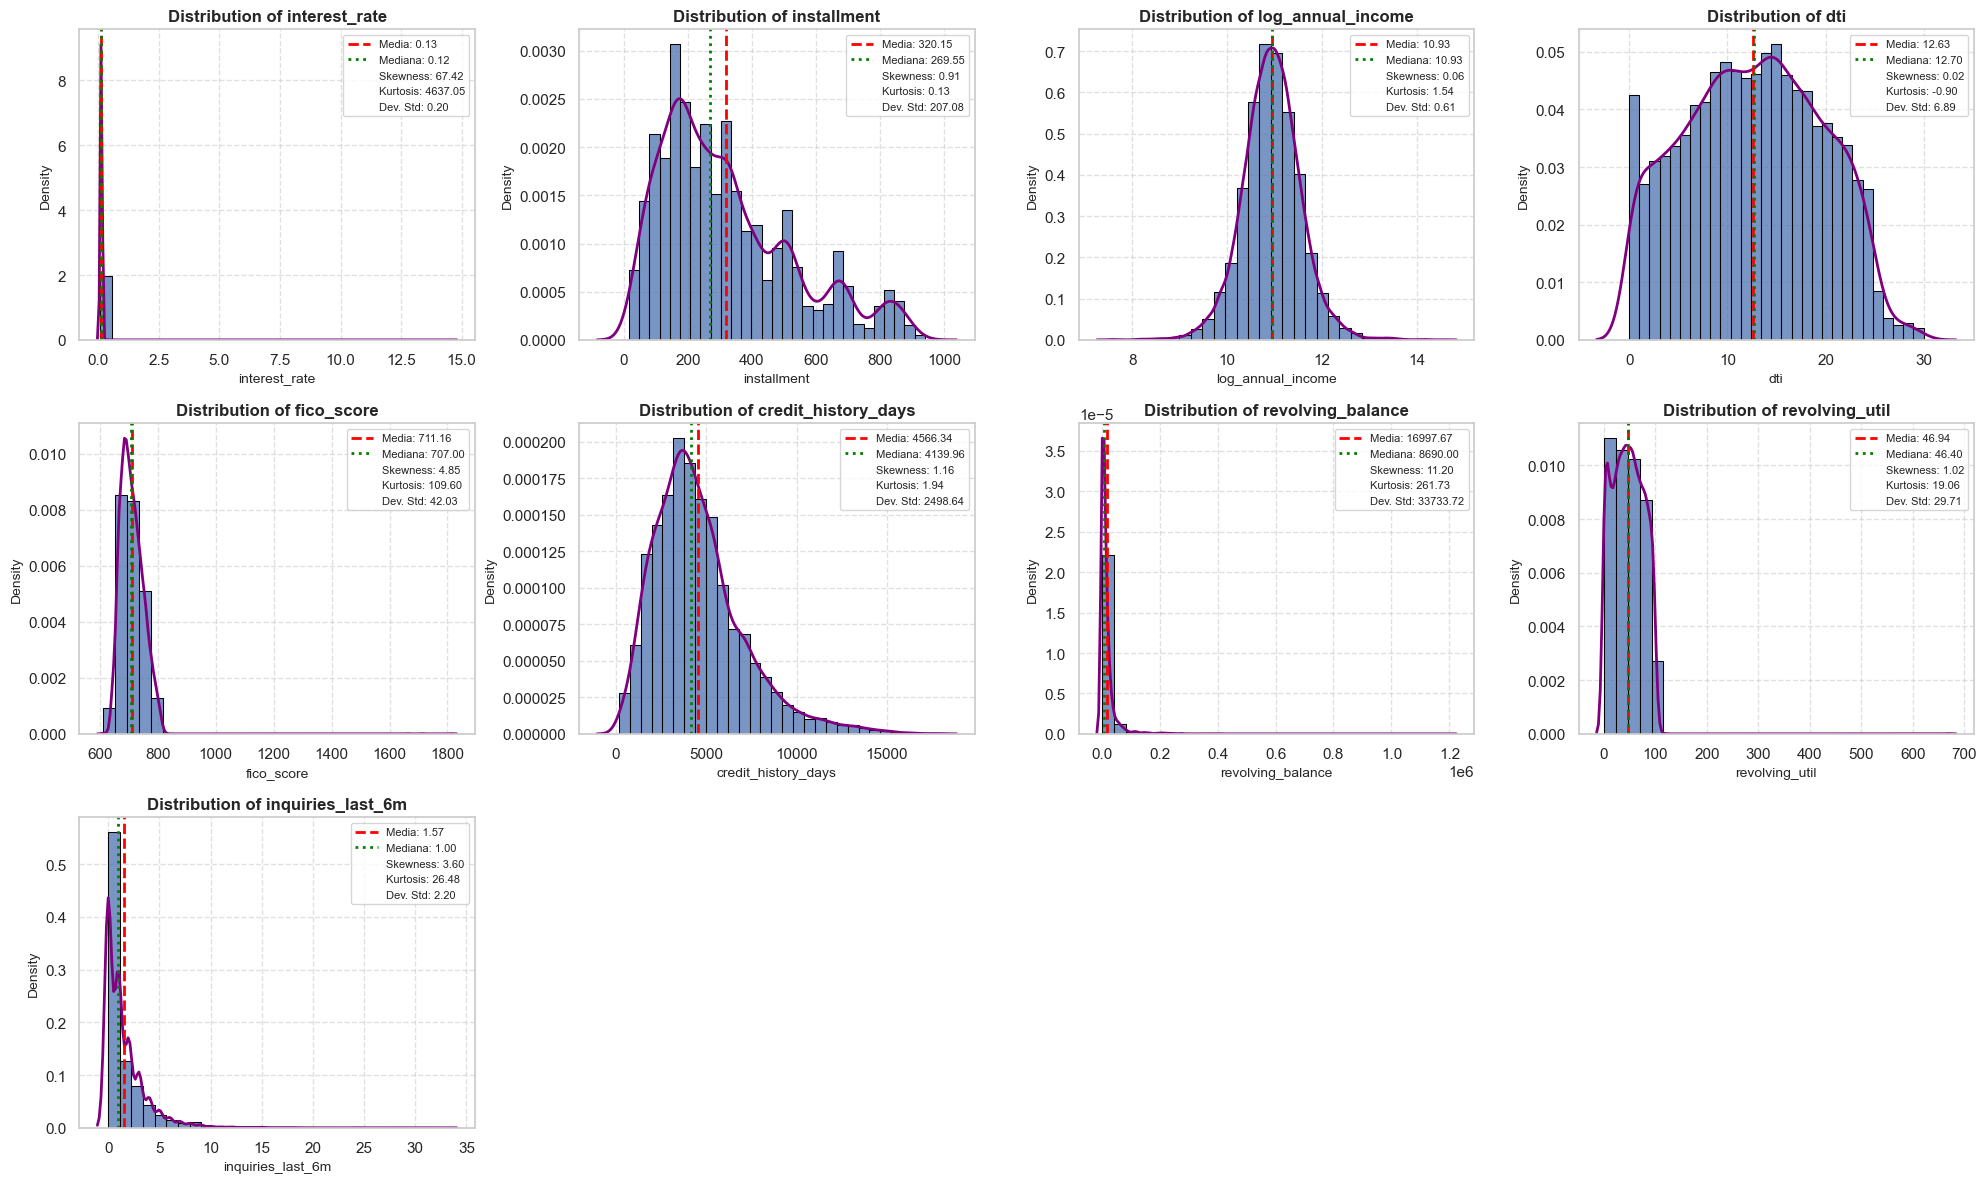

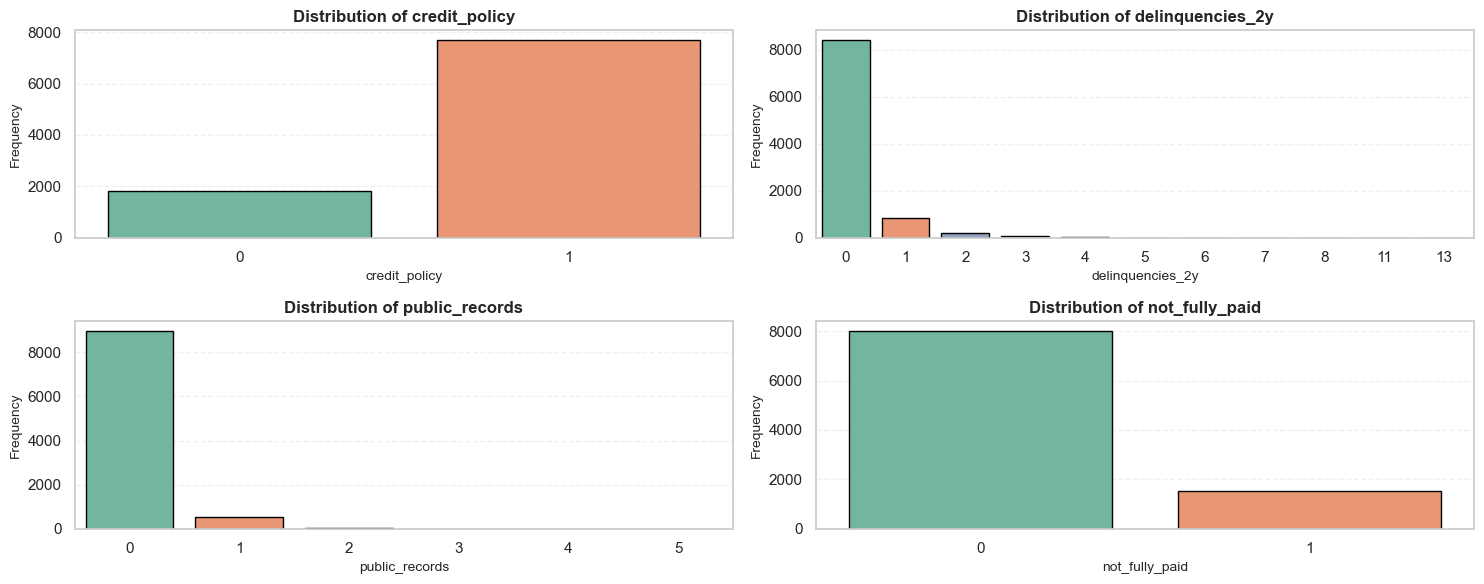

In [169]:

# Separiamo colonne continue e discrete
numeric_cols = data.select_dtypes(include=[np.number]).columns.drop('customer_id')
discrete_cols = ['credit_policy', 'delinquencies_2y', 'public_records', 'not_fully_paid']
continuous_cols = [col for col in numeric_cols if col not in discrete_cols]

# Griglia per variabili CONTINUE (istogramma + KDE)
n_cols_cont = len(continuous_cols)
n_rows_cont = int(np.ceil(n_cols_cont / 4))

plt.figure(figsize=(20, n_rows_cont * 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(n_rows_cont, 4, i+1)
    vals = data[col].dropna()
    bins = np.linspace(vals.min(), vals.max(), 30)

    ax = sns.histplot(vals, bins=bins, edgecolor="black", stat='density', kde=False)
    sns.kdeplot(vals, color='purple', lw=2, ax=ax)

    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')

    # Calcoliamo le statistiche
    mean_val = vals.mean()
    median_val = vals.median()
    skew_val = vals.skew()
    kurt_val = vals.kurt()
    std_val = vals.std()

    # Linee verticali per media e mediana
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.2f}')

    # Statistiche nella legenda
    plt.plot([], [], ' ', label=f'Skewness: {skew_val:.2f}')
    plt.plot([], [], ' ', label=f'Kurtosis: {kurt_val:.2f}')
    plt.plot([], [], ' ', label=f'Dev. Std: {std_val:.2f}')

    plt.legend(fontsize=8, loc='best')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

# Griglia per variabili DISCRETE (bar plot)
n_cols_disc = len(discrete_cols)
n_rows_disc = int(np.ceil(n_cols_disc / 2))

plt.figure(figsize=(15, n_rows_disc * 3))

for i, col in enumerate(discrete_cols):
    plt.subplot(n_rows_disc, 2, i+1)
    sns.countplot(data=data, x=col, hue=col, palette='Set2', legend=False, edgecolor="black")
    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

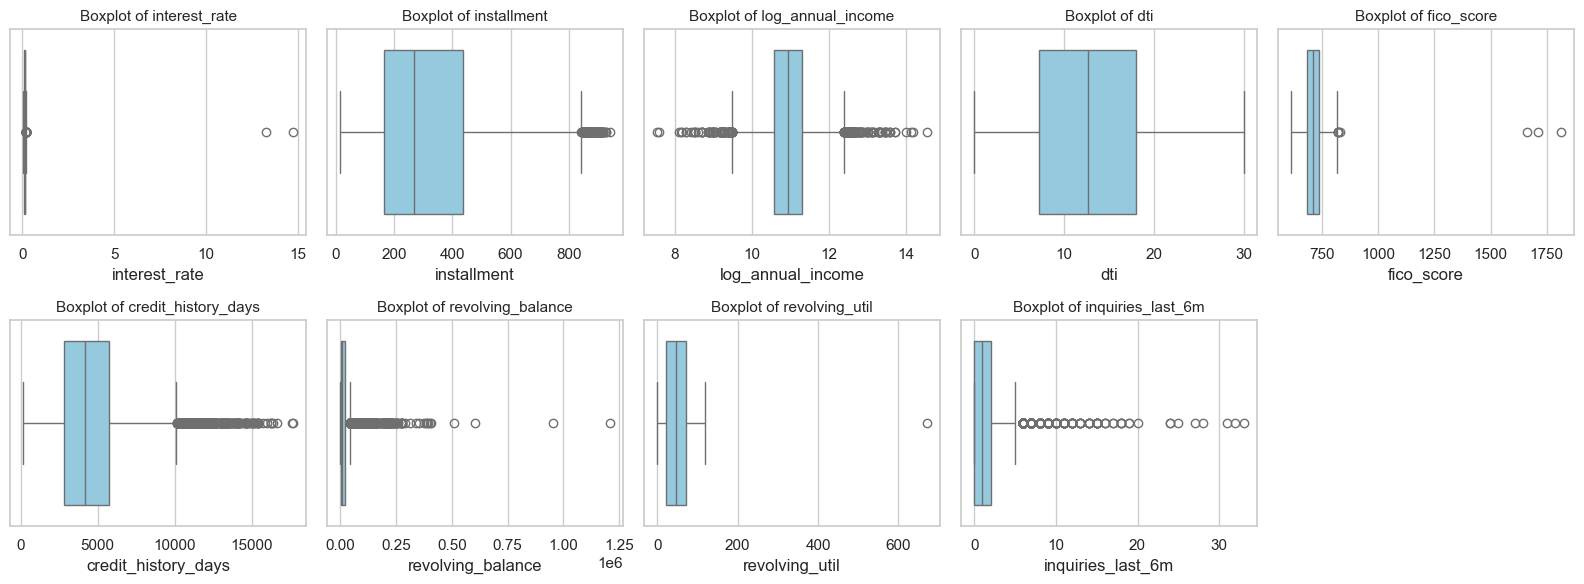

In [170]:
plt.figure(figsize=(16, 6))
for idx, col in enumerate(continuous_cols):
    plt.subplot(2, int(np.ceil(len(continuous_cols)/2)), idx+1)
    sns.boxplot(data=data, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

<a id="interest-rate-dist"></a>
## Quanto costa prendere un prestito?

**Domanda**: Come sono distribuiti i tassi di interesse? Ci sono valori sospetti?

Il tasso di interesse e una variabile cruciale: rappresenta il "prezzo" del prestito per il cliente e riflette il rischio percepito dalla piattaforma. Tassi alti indicano clienti considerati rischiosi.

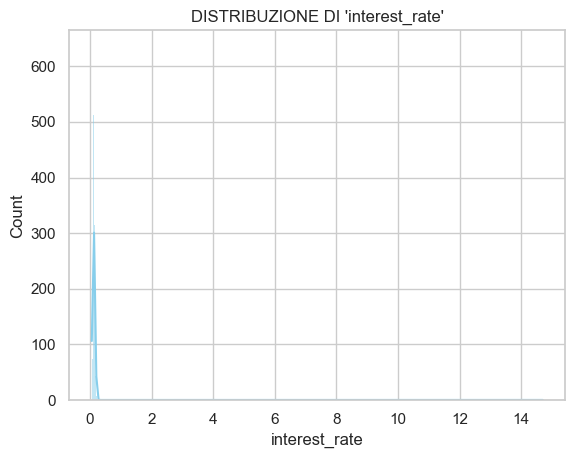

count    9508.000000
mean        0.125583
std         0.202949
min         0.060000
25%         0.103900
50%         0.122100
75%         0.140700
max        14.700000
Name: interest_rate, dtype: float64


In [171]:
sns.histplot(data=data, x='interest_rate', kde=True, color='skyblue')
plt.title("DISTRIBUZIONE DI 'interest_rate'")
plt.show()

print(data['interest_rate'].describe())


Il boxplot evidenzia immediatamente la presenza di valori anomali. Alcuni tassi sono troppo bassi o troppo alti per essere credibili.

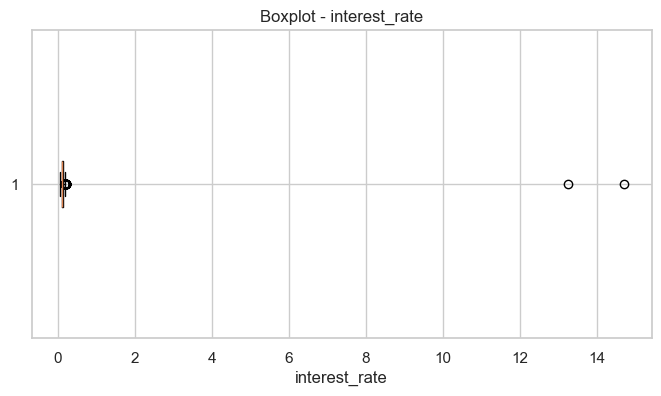

In [172]:
plt.figure(figsize=(8,4))
plt.boxplot(data['interest_rate'], vert=False)
plt.title('Boxplot - interest_rate')
plt.xlabel('interest_rate')
plt.show()

Notiamo valori molto vicini allo zero e altri che arrivano a 14. Questo suggerisce che i tassi potrebbero essere in formato decimale (0.12 invece di 12%). Verifichiamo e correggiamo il problema.

In [173]:
mask_decimal = data['interest_rate'] <= 1
n_corrected = mask_decimal.sum()

if n_corrected > 0:
    print(f"Conversione in corso: trovati {n_corrected} valori in scala decimale (<= 1).")
    data.loc[mask_decimal, 'interest_rate'] = data['interest_rate'] * 100
    print("Conversione completata: ora tutti i valori sono in scala percentuale (0-100).")
else:
    print("Nessun valore in scala decimale (<= 1) trovato. I dati sembrano già in percentuale.")

print("\nStatistiche post-conversione:")
print(data['interest_rate'].describe())

Q1 = data['interest_rate'].quantile(0.25)
Q3 = data['interest_rate'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Limite inferiore: {lower_bound:.4f}')
print(f'Limite superiore: {upper_bound:.4f}')

Conversione in corso: trovati 9506 valori in scala decimale (<= 1).
Conversione completata: ora tutti i valori sono in scala percentuale (0-100).

Statistiche post-conversione:
count    9508.000000
mean       12.267296
std         2.681129
min         6.000000
25%        10.390000
50%        12.210000
75%        14.070000
max        21.640000
Name: interest_rate, dtype: float64
Limite inferiore: 4.8700
Limite superiore: 19.5900


I limiti calcolati con il metodo IQR (range interquartile) identificano l'intervallo dei valori "normali". Tutto cio che esce da questo intervallo viene considerato outlier.

In [174]:
lower_outlier = data[data['interest_rate'] < lower_bound]

# Filtrare gli upper outliers
upper_outlier = data[data['interest_rate'] > upper_bound]

print("Numero di lower outliers:", len(lower_outlier))
print("Numero di upper outliers:", len(upper_outlier))

Numero di lower outliers: 0
Numero di upper outliers: 51


In [175]:
outliers = data[(data['interest_rate'] < lower_bound) | (data['interest_rate'] > upper_bound)]
print(f'NUMERO DI OUTLIERS TROVATI : {outliers.shape[0]}')

NUMERO DI OUTLIERS TROVATI : 51


In [176]:
print("Esempi di outlier:")
print(outliers['interest_rate'].head())

Esempi di outlier:
2945    20.86
3713    20.11
3991    20.11
4064    19.79
4731    20.17
Name: interest_rate, dtype: float64


### Pulizia degli outlier

Rimuoviamo i valori anomali per ottenere una distribuzione piu rappresentativa della realta dei prestiti.

In [177]:
total_count = len(data)
outliers_count = len(outliers)

data_clean= data[(data['interest_rate'] >= lower_bound) & (data['interest_rate'] <= upper_bound)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data_clean.shape[0]} righe')

cleaned_count = len(data_clean)
removed_percentage = (outliers_count / total_count) * 100

print(f"Percentuale di outliers rimossi: {removed_percentage:.2f}%")

DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9457 righe
Percentuale di outliers rimossi: 0.54%


La perdita di dati e minima ma il dataset e ora piu pulito e affidabile.

### Cosa abbiamo trovato?

Visualizziamo la distribuzione pulita insieme alle principali statistiche descrittive: media, mediana, deviazione standard, asimmetria (skewness) e curtosi (kurtosis).

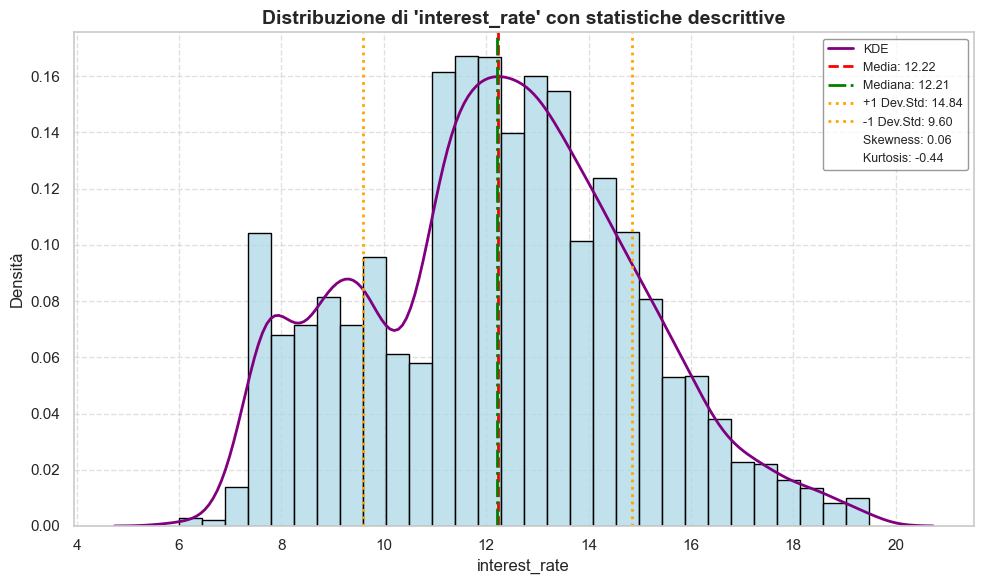

In [178]:
colonna = 'interest_rate'

vals = data_clean[colonna].dropna()

mean_dc = vals.mean()
median_dc = vals.median()
skewness = vals.skew()
kurtosis = vals.kurt()
std_dc = vals.std()


plt.figure(figsize=(10, 6))

sns.histplot(vals, bins=30, color='lightblue', edgecolor='black', stat='density', kde=False)
sns.kdeplot(vals, color='purple', lw=2, label='KDE')

plt.axvline(mean_dc, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_dc:.2f}')
plt.axvline(median_dc, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_dc:.2f}')
plt.axvline(mean_dc + std_dc, color='orange', linestyle=':', linewidth=2, label=f'+1 Dev.Std: {(mean_dc + std_dc):.2f}')
plt.axvline(mean_dc - std_dc, color='orange', linestyle=':', linewidth=2, label=f'-1 Dev.Std: {(mean_dc - std_dc):.2f}')

plt.plot([], [], ' ', label=f'Skewness: {skewness:.2f}')
plt.plot([], [], ' ', label=f'Kurtosis: {kurtosis:.2f}')

plt.title(f"Distribuzione di '{colonna}' con statistiche descrittive", fontsize=14, fontweight='bold')
plt.xlabel(colonna, fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend(fontsize=9, loc='best', frameon=True, facecolor='white', edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


**Risposta**: Il tasso di interesse medio e circa 12.5%, con la maggior parte dei prestiti tra 10% e 14%. Tassi sopra il 20% sono rari, sotto il 6% sono eccezioni riservate a clienti con profilo creditizio eccellente.

La distribuzione e approssimativamente simmetrica, il che indica che LendingClub applica tassi abbastanza standardizzati con variazioni legate al profilo di rischio del cliente.

### Cosa abbiamo imparato sui tassi di interesse

**Prima della pulizia**: la distribuzione era fortemente sbilanciata a causa di valori estremi, probabilmente errori di inserimento o problemi di formato.

**Dopo la pulizia**: distribuzione simmetrica centrata sul 12.2%, con deviazione standard di circa 2.6%. I tassi sono ora omogenei e realistici per un mercato di prestiti consumer.

Questo ci conferma che la piattaforma applica una politica di pricing ragionevolmente uniforme, con aggiustamenti basati sul rischio individuale.

<a id="installment-analisi"></a>
## Quanto pagano i clienti ogni mese?

**Domanda**: Come sono distribuite le rate mensili?

La rata dipende dall'importo del prestito, dalla durata e dal tasso di interesse. Ci aspettiamo una distribuzione sbilanciata verso destra, con molte rate basse e poche rate alte.

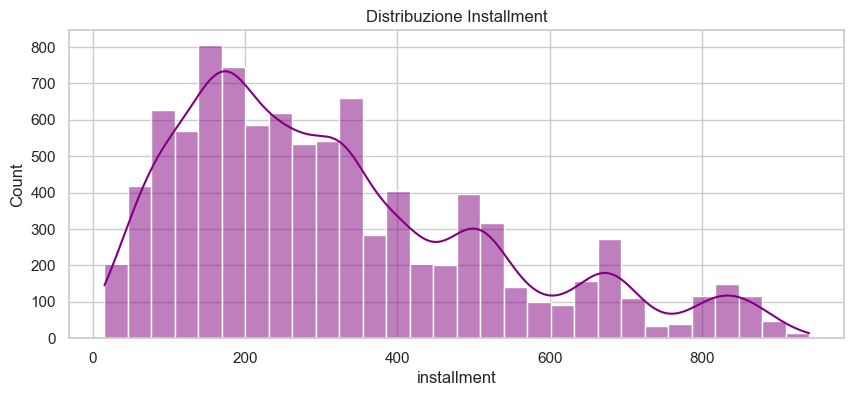

STATISTICHE DESCRITTIVE:

count    9508.000000
mean      320.152235
std       207.083521
min        15.670000
25%       164.020000
50%       269.545000
75%       435.232500
max       940.140000
Name: installment, dtype: float64


In [179]:
plt.figure(figsize=(10,4))
sns.histplot(data['installment'], kde=True, bins = 30, color='purple')
plt.title('Distribuzione Installment')
plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['installment'].describe())

Il boxplot identifica valori che il metodo statistico considera "anomali".

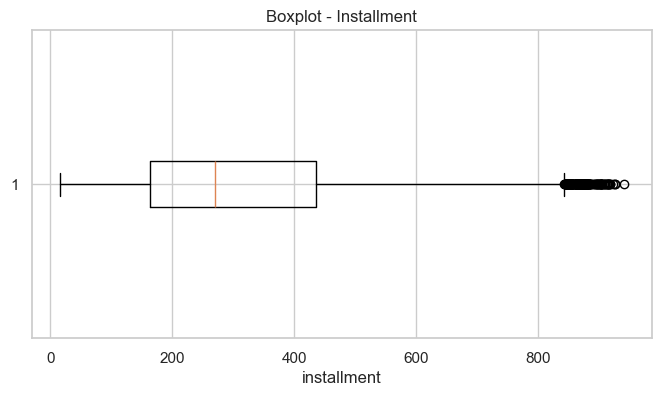

In [180]:
plt.figure(figsize=(8,4))
plt.boxplot(data['installment'], vert=False)
plt.title('Boxplot - Installment')
plt.xlabel('installment')
plt.show()

Calcoliamo i limiti statistici per identificare gli outlier.

In [181]:
Q1 = data['installment'].quantile(0.25)
Q3 = data['installment'].quantile(0.75)
IQR = Q3 - Q1

lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5* IQR

print(f'Limite Inferiore: {lowerBound:.2f}')
print(f'Limite Superire: {upperBound:.2f}')



Limite Inferiore: -242.80
Limite Superire: 842.05


Quanti outlier troviamo?

In [182]:
# Filtrare i lower outliers classici (valori bassi estremi)
lower_outliers = data[data['installment'] < lowerBound]

# Filtrare gli upper outliers
upper_outliers = data[data['installment'] > upperBound]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))

Numero di lower outliers: 0
Numero di upper outliers: 193


In [183]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]

print("Numero totale di outlier :", all_outliers.shape[0])

Numero totale di outlier : 193


In [184]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]
print("Esempi di outlier:")
print(all_outliers[['installment','dti', 'customer_id']].head())

Esempi di outlier:
     installment    dti  customer_id
237       859.07  20.79        10238
249       842.47  12.81        10250
271       862.97   5.79        10272
275       851.41  19.78        10276
322       876.83  18.08        10323


**Attenzione**: le rate alte (es. 842 euro) vengono segnalate come outlier dal metodo IQR, ma non sono errori. Rappresentano semplicemente prestiti di importo maggiore. Non le rimuoviamo perche sono dati legittimi, non anomalie.

### Forma della distribuzione

Esaminiamo asimmetria (skewness) e curtosi (kurtosis) per capire quanto la distribuzione si discosta da una normale.

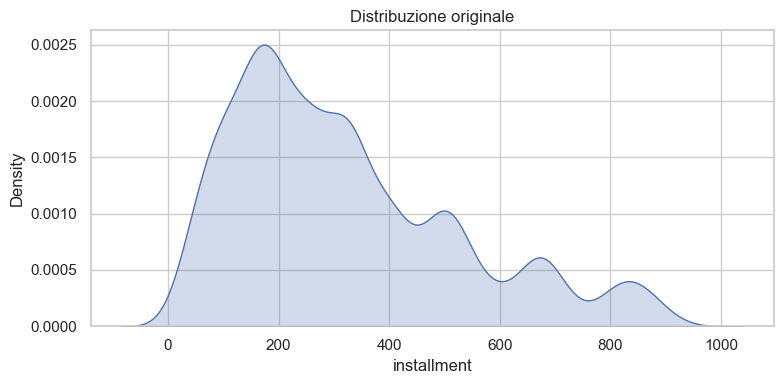


INSTALLMENT
Asimmetria_Skewness: 0.91 | Kurtosis: 0.13


In [185]:
sns.set(style="whitegrid")

skew = data['installment'].skew()
kurt = data['installment'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['installment'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['installment']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")



**Risposta**: La distribuzione e leggermente sbilanciata verso destra (skewness positiva), confermando che ci sono piu rate basse che alte. La curtosi indica una forma simile alla normale ma con code leggermente piu pesanti, quindi qualche valore estremo e presente.

<a id="credit_history_days"></a>
## Da quanto tempo i clienti hanno una storia creditizia?

**Domanda**: L'anzianita della storia creditizia influenza il rischio?

Questa variabile misura da quanti giorni il cliente ha una storia creditizia attiva. In teoria, una storia piu lunga fornisce piu dati alla banca per valutare l'affidabilita.

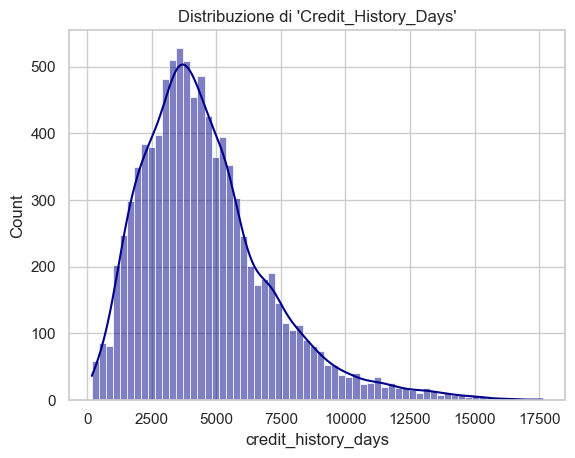

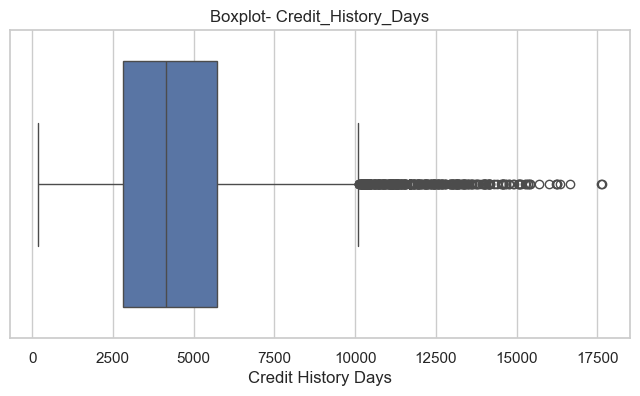

count     9508.000000
mean      4566.344881
std       2498.641022
min        180.041667
25%       2820.000000
50%       4139.958333
75%       5730.041667
max      17639.958330
Name: credit_history_days, dtype: float64

Skewness: 1.1584
Kurtosis: 1.9393


In [186]:
sns.histplot (data = data, x ='credit_history_days', kde = True, color = 'darkblue')
plt.title("Distribuzione di 'Credit_History_Days'")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x = data['credit_history_days'])
plt.title('Boxplot- Credit_History_Days')
plt.xlabel('Credit History Days')
plt.show()

print(data['credit_history_days'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")


### Conversione in anni

I giorni sono poco intuitivi, convertiamoli in anni per una lettura piu immediata:
- 0-5 anni: clienti giovani o nuovi al credito
- 5-20 anni: esperienza normale
- 20-35 anni: clienti con lunga esperienza
- oltre 45 anni: valore sospetto, da verificare

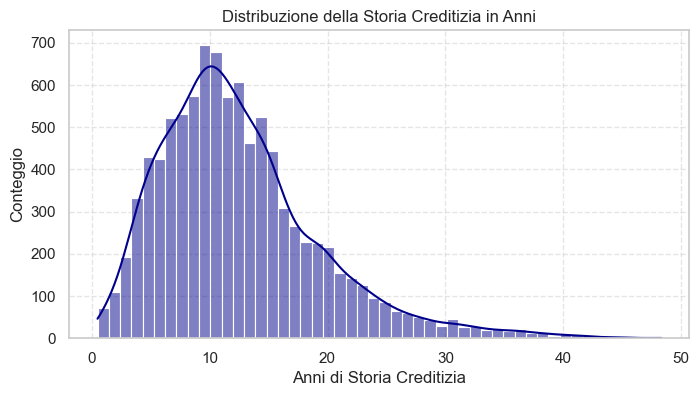

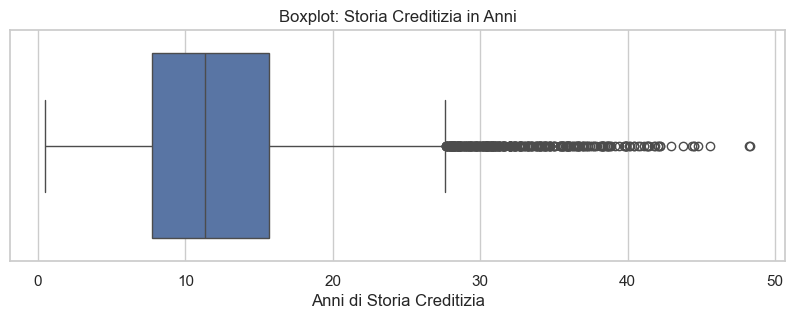

count    9508.000000
mean       12.501971
std         6.840906
min         0.492927
25%         7.720739
50%        11.334588
75%        15.687999
max        48.295574
Name: credit_history_years, dtype: float64

Skewness: 1.1584
Kurtosis: 1.9393


In [187]:
data['credit_history_years'] = data['credit_history_days'] / 365.25

plt.figure(figsize=(8,4))
sns.histplot(data['credit_history_years'], kde=True, bins=50, color = 'darkblue')
plt.title('Distribuzione della Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.ylabel('Conteggio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=data['credit_history_years'])
plt.title('Boxplot: Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.show()

print(data['credit_history_years'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")

In [188]:
Q1 = data['credit_history_years'].quantile(0.25)
Q3 = data['credit_history_years'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_chd = Q1 - 1.5 * IQR
upper_bound_chd = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lower_bound_chd:.4f}')
print(f'Limite Superiore: {upper_bound_chd:.4f}')

Limite Inferiore: -4.2302
Limite Superiore: 27.6389


Il metodo IQR suggerirebbe un limite di circa 28 anni, ma e troppo restrittivo. Nella realta, 45 anni di storia creditizia sono il massimo plausibile: richiederebbe aver aperto un conto a 18 anni ed essere ora oltre i 60. Usiamo 45 anni come soglia ragionevole.

In [189]:
upper_limit = 45
outliers = data[data['credit_history_years'] > upper_limit]
df_clean = data[data['credit_history_years'] <= upper_limit]

print('Numero di outlier sopra i 45 anni:', len(outliers))

Numero di outlier sopra i 45 anni: 3


In [190]:
print('Outliers nel dataset:')
print(outliers['credit_history_years'].head())

Outliers nel dataset:
5801    45.590691
7553    48.229979
8430    48.295574
Name: credit_history_years, dtype: float64


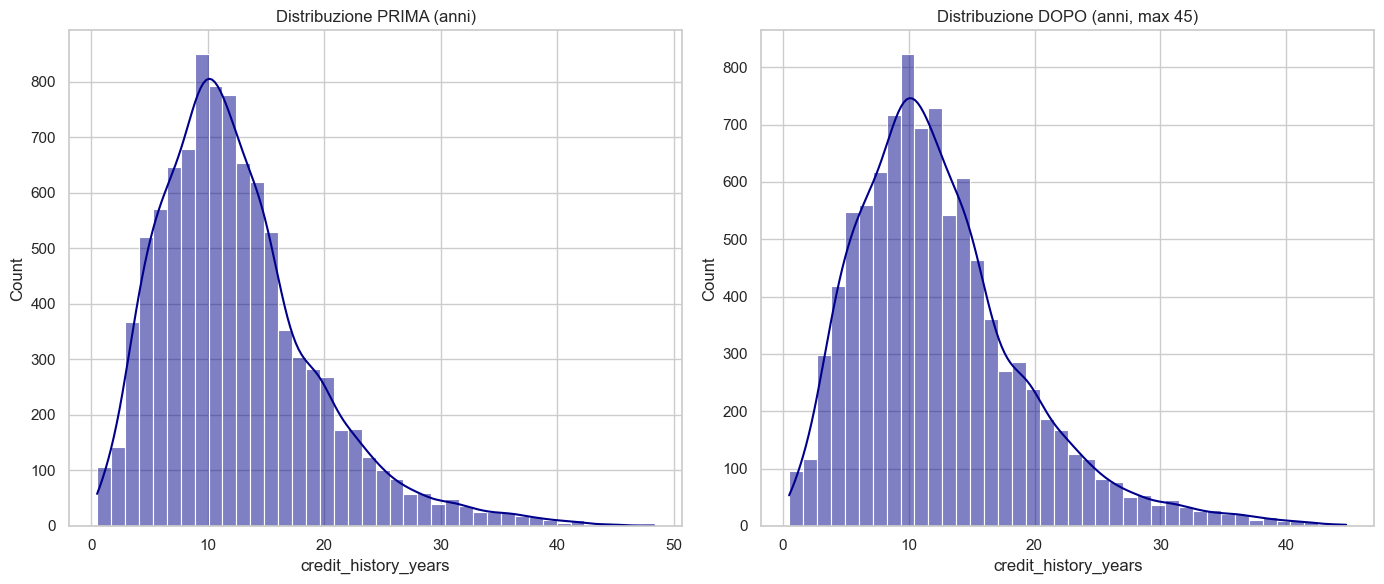

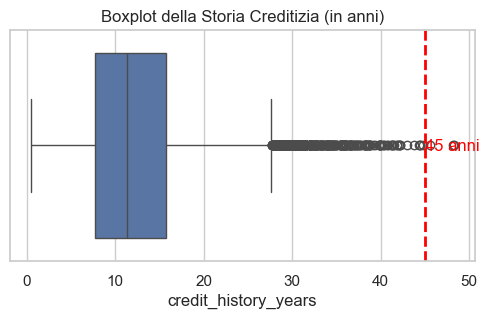

count    9505.000000
mean       12.490965
std         6.813834
min         0.492927
25%         7.720739
50%        11.334588
75%        15.687885
max        44.763860
Name: credit_history_years, dtype: float64

Skewness: 1.1350
Kurtosis: 1.8088


In [191]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione PRIMA (anni)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione DOPO (anni, max 45)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=data["credit_history_years"])
plt.title("Boxplot della Storia Creditizia (in anni)")


plt.axvline(x=45, color='red', linestyle='--', linewidth=2)
plt.text(45, 0.02, "45 anni", color='red')

plt.xlabel("credit_history_years")
plt.show()


print(df_clean['credit_history_years'].describe())

print(f"\nSkewness: {df_clean['credit_history_years'].skew():.4f}")
print(f"Kurtosis: {df_clean['credit_history_years'].kurt():.4f}")

**Risposta**: Abbiamo rimosso pochissimi record (0.03%). La distribuzione rimane sbilanciata verso destra, il che e normale: la maggior parte dei clienti ha storie creditizie di durata media, mentre solo pochi hanno storie molto lunghe.

<a id="fico-score"></a>
## Quanto sono affidabili i nostri clienti?

**Domanda**: Come sono distribuiti i punteggi FICO? Che tipo di clientela attrae LendingClub?

Il FICO Score e il numero che sintetizza l'affidabilita creditizia nel mercato americano. La scala va da 300 a 850:
- Sotto 580: pessimo
- 580-669: discreto
- 670-739: buono
- 740-799: molto buono
- Sopra 800: eccellente

Questo punteggio influenza direttamente il tasso di interesse applicato e la probabilita di ottenere il prestito.

In [192]:
print("=== STATISTICHE FICO SCORE ===")
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")

=== STATISTICHE FICO SCORE ===
count    9508.000000
mean      711.155974
std        42.033425
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max      1812.000000
Name: fico_score, dtype: float64

Skewness: 4.8531
Kurtosis: 109.6038


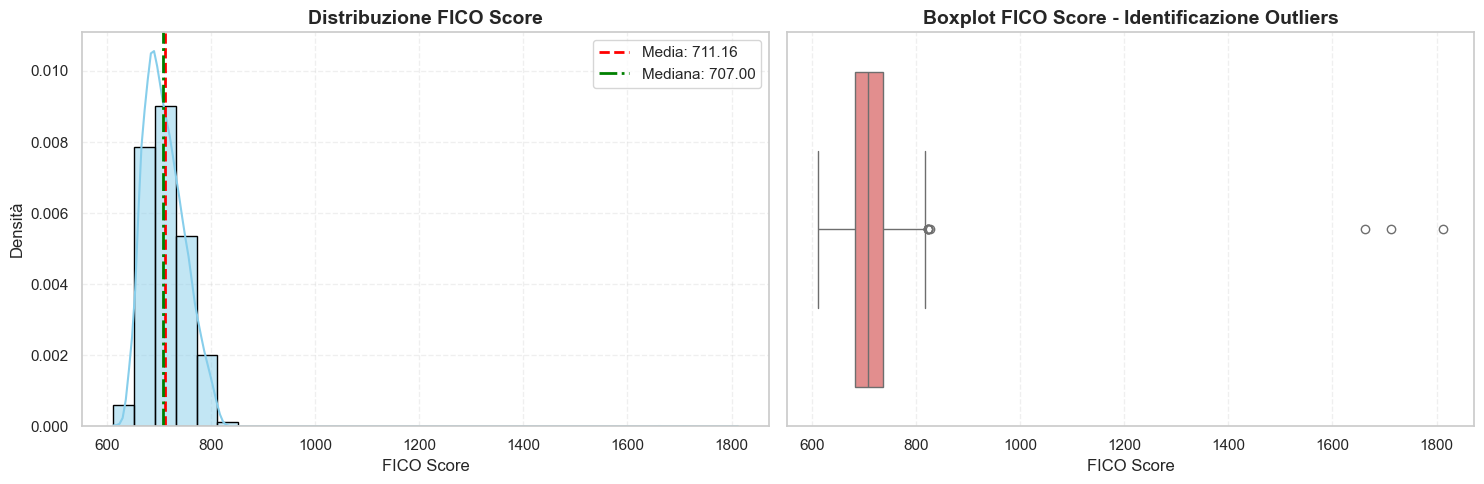

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma + KDE
ax1 = axes[0]
sns.histplot(data['fico_score'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['fico_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["fico_score"].mean():.2f}')
ax1.axvline(data['fico_score'].median(), color='green', linestyle='-.', linewidth=2, label=f'Mediana: {data["fico_score"].median():.2f}')
ax1.set_title('Distribuzione FICO Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('FICO Score', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# Boxplot
ax2 = axes[1]
sns.boxplot(x=data['fico_score'], color='lightcoral', ax=ax2)
ax2.set_title('Boxplot FICO Score - Identificazione Outliers', fontsize=14, fontweight='bold')
ax2.set_xlabel('FICO Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [194]:
# Identificazione outliers per FICO Score
Q1_fico = data['fico_score'].quantile(0.25)
Q3_fico = data['fico_score'].quantile(0.75)
IQR_fico = Q3_fico - Q1_fico

lower_bound_fico = Q1_fico - 1.5 * IQR_fico
upper_bound_fico = 851

print(f'Limite inferiore: {lower_bound_fico:.2f}')
print(f'Limite superiore: {upper_bound_fico:.2f}')

outliers_fico = data[(data['fico_score'] < lower_bound_fico) | (data['fico_score'] > upper_bound_fico)]
print(f'\nNUMERO DI OUTLIERS TROVATI: {outliers_fico.shape[0]}')
print(f'Percentuale di outliers: {(outliers_fico.shape[0] / len(data)) * 100:.2f}%')
print(f'Valore massimo FICO Score: {data["fico_score"].max()}')

# Rimozione degli outlier
total_count_fico = len(data)
outliers_count_fico = len(outliers_fico)

print(f'\n{"="*60}')
print(f'PULIZIA FICO SCORE')
print(f'{"="*60}')
print(f'Dimensione dataset PRIMA della pulizia: {total_count_fico} righe')

data = data[(data['fico_score'] >= lower_bound_fico) & (data['fico_score'] <= upper_bound_fico)]

print(f'Dimensione dataset DOPO la pulizia: {len(data)} righe')
print(f'Righe rimosse: {outliers_count_fico}')
print(f'Percentuale rimossa: {(outliers_count_fico / total_count_fico) * 100:.2f}%')

# Nuove statistiche dopo pulizia
print(f'\n{"="*60}')
print("STATISTICHE FICO SCORE DOPO PULIZIA")
print(f'{"="*60}')
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")
print(f'{"="*60}')
print(data['fico_score'].max())

Limite inferiore: 599.50
Limite superiore: 851.00

NUMERO DI OUTLIERS TROVATI: 3
Percentuale di outliers: 0.03%
Valore massimo FICO Score: 1812

PULIZIA FICO SCORE
Dimensione dataset PRIMA della pulizia: 9508 righe
Dimensione dataset DOPO la pulizia: 9505 righe
Righe rimosse: 3
Percentuale rimossa: 0.03%

STATISTICHE FICO SCORE DOPO PULIZIA
count    9505.000000
mean      710.834824
std        37.937155
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max       827.000000
Name: fico_score, dtype: float64

Skewness: 0.4678
Kurtosis: -0.4289
827


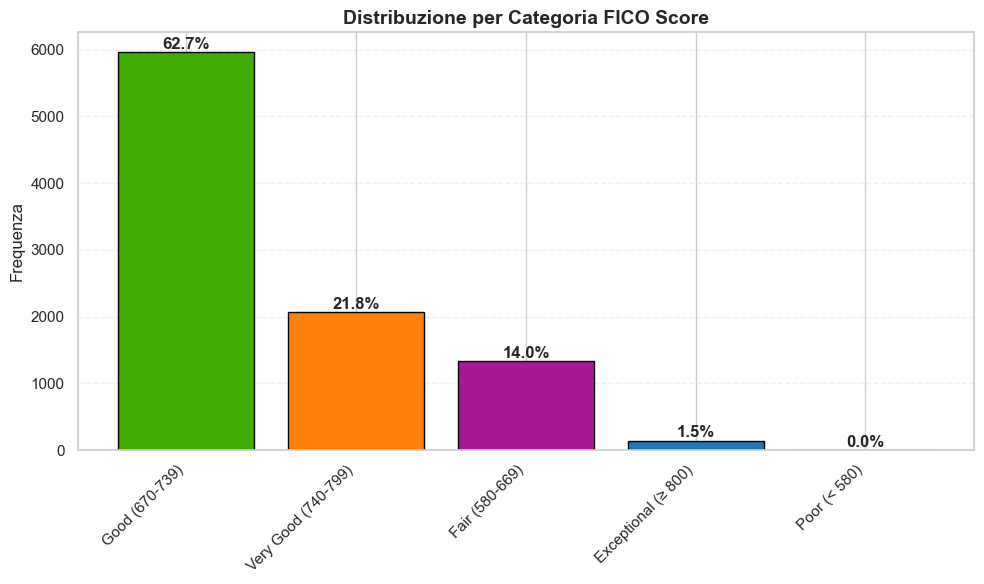


=== DISTRIBUZIONE PER CATEGORIA ===
Good (670-739): 5963 (62.74%)
Very Good (740-799): 2071 (21.79%)
Fair (580-669): 1331 (14.00%)
Exceptional (≥ 800): 140 (1.47%)
Poor (< 580): 0 (0.00%)


In [195]:
def classify_fico(score):
    if score < 580:
        return 'Poor (< 580)'
    elif score < 670:
        return 'Fair (580-669)'
    elif score < 740:
        return 'Good (670-739)'
    elif score < 800:
        return 'Very Good (740-799)'
    else:
        return 'Exceptional (≥ 800)'

data['fico_category'] = data['fico_score'].apply(classify_fico)

category_order = ['Poor (< 580)','Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (≥ 800)']
data['fico_category'] = pd.Categorical(data['fico_category'], categories=category_order, ordered=True)

plt.figure(figsize=(10, 6))

fico_counts = data['fico_category'].value_counts()
colors = ['#3fac03', '#ff7f0e', "#a81997", '#1f77b4', '#9467bd']
plt.bar(range(len(fico_counts)), fico_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(fico_counts)), fico_counts.index, rotation=45, ha='right')
plt.title('Distribuzione per Categoria FICO Score', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Percentuali
for i, (cat, count) in enumerate(fico_counts.items()):
    pct = (count / len(data)) * 100
    plt.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DISTRIBUZIONE PER CATEGORIA ===")
for cat, count in fico_counts.items():
    print(f"{cat}: {count} ({(count/len(data))*100:.2f}%)")

<a id="purpose-analisi"></a>
## Perche i clienti chiedono un prestito?

**Domanda**: Quali sono le motivazioni piu comuni? Alcune sono piu rischiose di altre?

La variabile `purpose` indica lo scopo dichiarato del prestito. E interessante vedere se certe motivazioni sono associate a tassi di default piu alti.

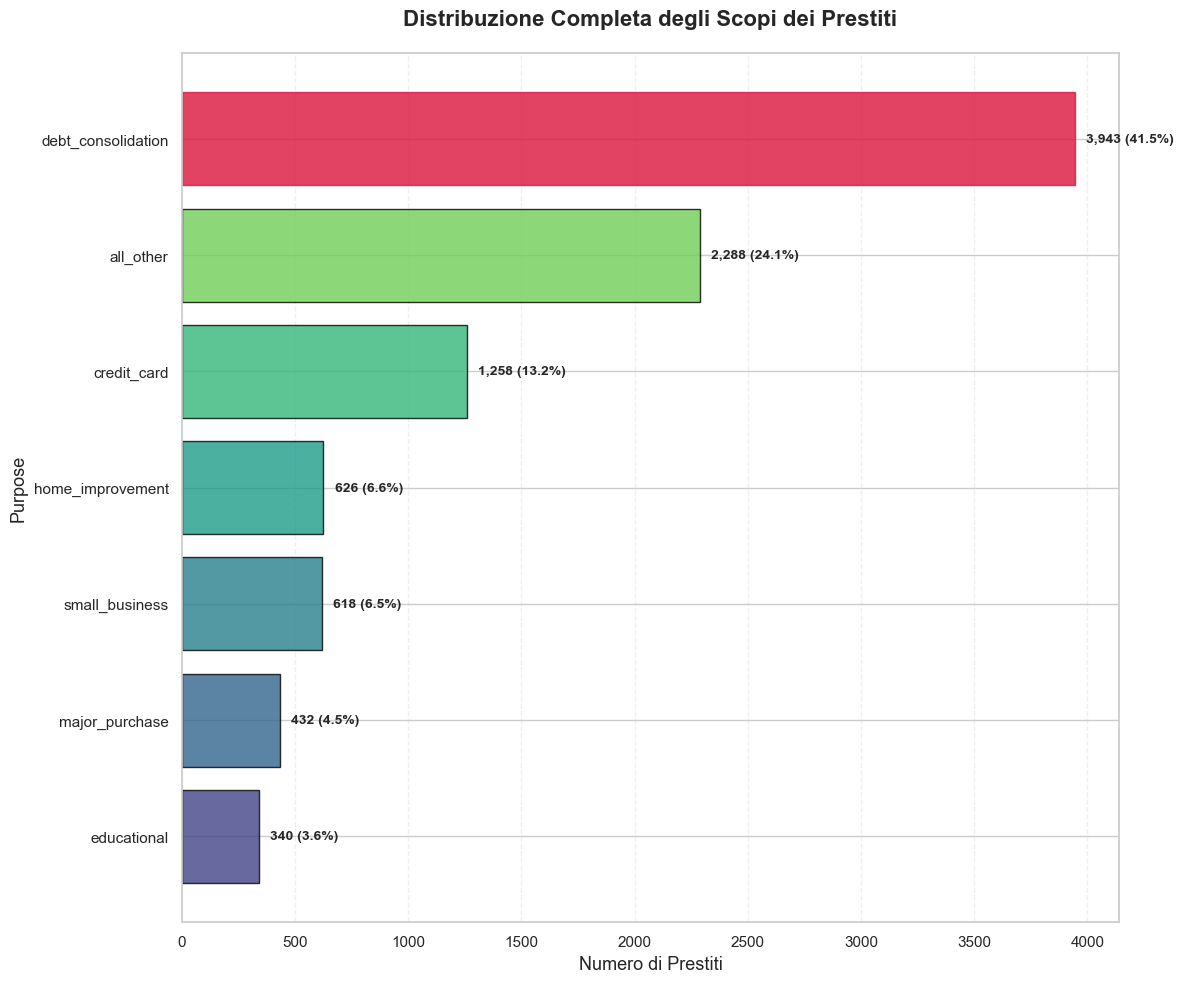


                    STATISTICHE PURPOSE
Purpose                               Count      Percentage
----------------------------------------------------------------------
debt_consolidation                    3,943          41.48%
all_other                             2,288          24.07%
credit_card                           1,258          13.24%
home_improvement                        626           6.59%
small_business                          618           6.50%
major_purchase                          432           4.54%
educational                             340           3.58%
TOTALE                                9,505         100.00%

Numero totale di categorie:         7
Categoria più frequente:            debt_consolidation (3,943 prestiti)
Categoria meno frequente:           educational (340 prestiti)


In [196]:

purpose_counts = data['purpose'].value_counts()
purpose_pct = (purpose_counts / len(data) * 100)

purpose_counts_sorted = purpose_counts.sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.9, len(purpose_counts_sorted)))

bars = ax.barh(range(len(purpose_counts_sorted)),
               purpose_counts_sorted.values,
               color=colors_gradient,
               edgecolor='black',
               alpha=0.8)

# Colora in rosso la barra più alta
max_idx = np.argmax(purpose_counts_sorted.values)
bars[max_idx].set_color('crimson')

# Aggiungi le percentuali alla fine di ogni barra
for i, (purpose, count) in enumerate(purpose_counts_sorted.items()):
    pct = (count / len(data)) * 100
    ax.text(count + 50, i, f'{count:,} ({pct:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

# Imposta le etichette sull'asse Y
ax.set_yticks(range(len(purpose_counts_sorted)))
ax.set_yticklabels(purpose_counts_sorted.index, fontsize=11)

ax.set_title('Distribuzione Completa degli Scopi dei Prestiti',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Numero di Prestiti', fontsize=13)
ax.set_ylabel('Purpose', fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, axis='x')


plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" "*20 + "STATISTICHE PURPOSE")
print("="*70)
print(f"{'Purpose':<30} {'Count':>12} {'Percentage':>15}")
print("-"*70)
for purpose, count in purpose_counts.items():
    pct = (count / len(data)) * 100
    print(f"{purpose:<30} {count:>12,} {pct:>14.2f}%")
print("="*70)
print(f"{'TOTALE':<30} {len(data):>12,} {100.0:>14.2f}%")
print("="*70)

# Statistiche aggiuntive
print(f"\n{'Numero totale di categorie:':<35} {len(purpose_counts)}")
print(f"{'Categoria più frequente:':<35} {purpose_counts.index[0]} ({purpose_counts.iloc[0]:,} prestiti)")
print(f"{'Categoria meno frequente:':<35} {purpose_counts.index[-1]} ({purpose_counts.iloc[-1]:,} prestiti)")

<a id="annual-income"></a>
## Quanto guadagnano i clienti?

**Domanda**: Qual e la distribuzione dei redditi? Il reddito e un buon predittore del rischio?

Il reddito e salvato come logaritmo naturale (`log_annual_income`). Lo riconvertiamo per vedere i valori reali in dollari.

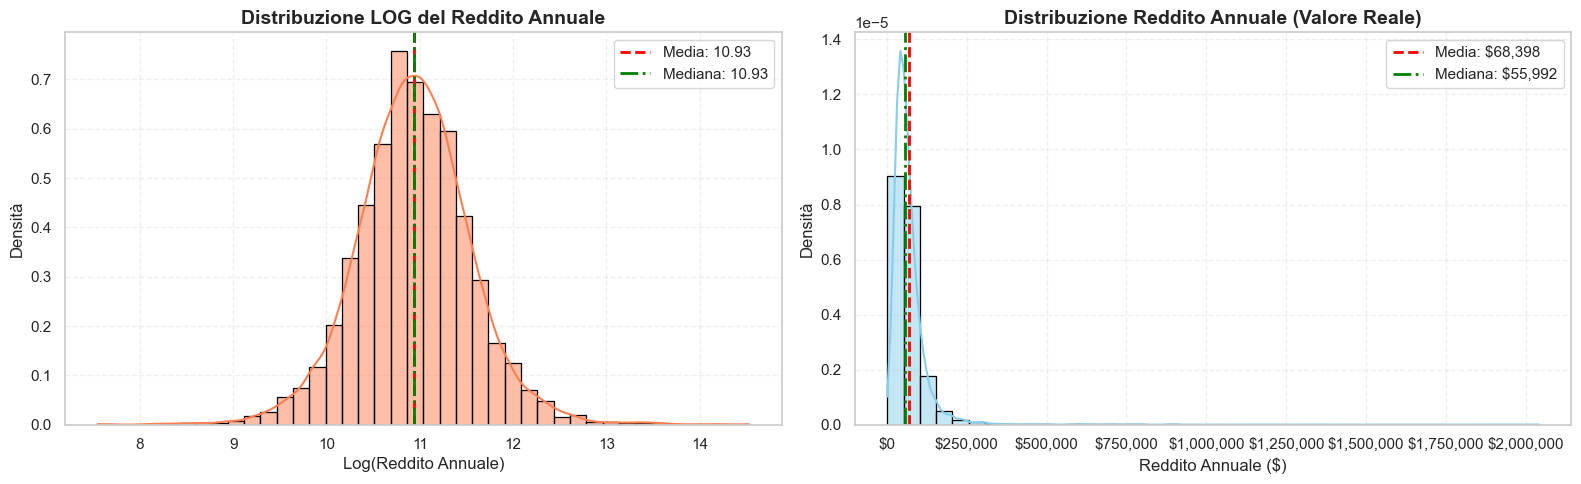


Skewness (Log): 0.0640
Skewness (Reale): 9.6758
min 1896.0000003508226
max 2039784.004362027
mean 68397.52192401636
std 61134.666732547186


In [197]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
data['annual_income'] = np.exp(data['log_annual_income'])

ax1 = axes[0]
sns.histplot(data['log_annual_income'], bins=40, kde=True, color='coral', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['log_annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {data["log_annual_income"].mean():.2f}')
ax1.axvline(data['log_annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: {data["log_annual_income"].median():.2f}')
ax1.set_title('Distribuzione LOG del Reddito Annuale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Log(Reddito Annuale)', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)


ax2 = axes[1]
sns.histplot(data['annual_income'], bins=40, kde=True, color='skyblue', edgecolor='black', ax=ax2, stat='density')
ax2.axvline(data['annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${data["annual_income"].mean():,.0f}')
ax2.axvline(data['annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: ${data["annual_income"].median():,.0f}')
ax2.set_title('Distribuzione Reddito Annuale (Valore Reale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Reddito Annuale ($)', fontsize=12)
ax2.set_ylabel('Densità', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)


ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\nSkewness (Log): {data['log_annual_income'].skew():.4f}")
print(f"Skewness (Reale): {data['annual_income'].skew():.4f}")

data['annual_income'].describe()
print("min", data['annual_income'].min())
print("max", data['annual_income'].max())
print("mean", data['annual_income'].mean())
print("std", data['annual_income'].std())

<a id="dti-analisi"></a>
## Quanto sono indebitati i clienti?

**Domanda**: Il rapporto debito/reddito (DTI) e un buon indicatore di rischio?

Il DTI (Debt-to-Income) misura quanta parte del reddito mensile va a pagare debiti esistenti.

Formula: DTI = (Debiti Mensili / Reddito Mensile) x 100

Un DTI alto come per esempio il 40%, significa che il 40% dello stipendio va gia in rate. Meno soldi restano per un nuovo prestito, quindi il rischio aumenta.

In [198]:
data_clean_dti = data[(data['dti'] >= lower_bound) & (data['dti'] <= upper_bound)]

print("="*60)
print("CONFRONTO STATISTICHE DTI")
print("="*60)

stats_comparison = pd.DataFrame({
    'Metrica': ['Count', 'Media', 'Mediana', 'Dev. Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness', 'Kurtosis'],
    'Con Outliers': [
        len(data),
        data['dti'].mean(),
        data['dti'].median(),
        data['dti'].std(),
        data['dti'].min(),
        data['dti'].quantile(0.25),
        data['dti'].quantile(0.75),
        data['dti'].max(),
        data['dti'].skew(),
        data['dti'].kurtosis()
    ],
    'Senza Outliers': [
        len(data_clean_dti),
        data_clean_dti['dti'].mean(),
        data_clean_dti['dti'].median(),
        data_clean_dti['dti'].std(),
        data_clean_dti['dti'].min(),
        data_clean_dti['dti'].quantile(0.25),
        data_clean_dti['dti'].quantile(0.75),
        data_clean_dti['dti'].max(),
        data_clean_dti['dti'].skew(),
        data_clean_dti['dti'].kurtosis()
    ]
})

stats_comparison['Variazione (%)'] = ((stats_comparison['Senza Outliers'] - stats_comparison['Con Outliers']) /
                                       stats_comparison['Con Outliers'] * 100).round(2)

print("\n" + stats_comparison.to_string(index=False))
print("\n" + "="*60)

CONFRONTO STATISTICHE DTI

 Metrica  Con Outliers  Senza Outliers  Variazione (%)
   Count   9505.000000     6190.000000          -34.88
   Media     12.631811       12.336247           -2.34
 Mediana     12.700000       12.420000           -2.20
Dev. Std      6.886351        4.075753          -40.81
     Min      0.000000        4.880000             inf
      Q1      7.230000        8.932500           23.55
      Q3     18.000000       15.720000          -12.67
     Max     29.960000       19.580000          -34.65
Skewness      0.020727       -0.038604         -286.25
Kurtosis     -0.902086       -1.123320           24.52



### Come è distribuito il DTI nel nostro dataset?

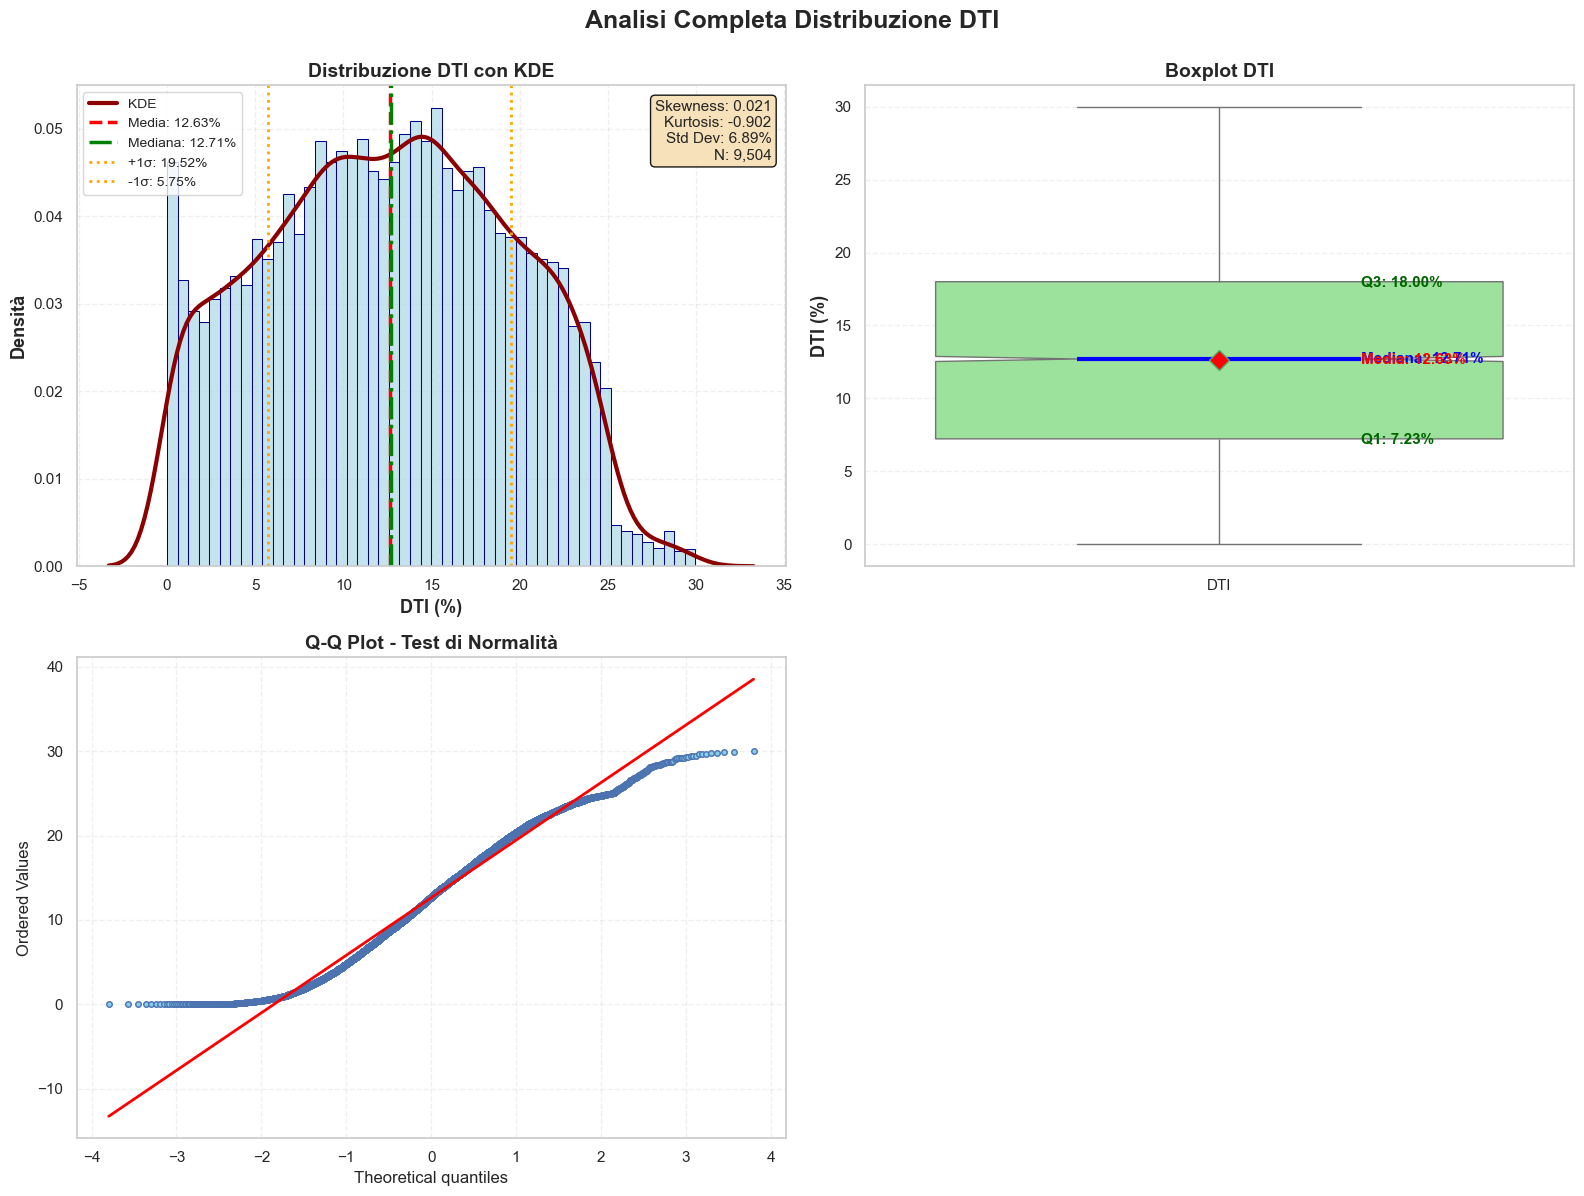

                    STATISTICHE DESCRITTIVE DTI
Media:              12.63%
Mediana:            12.71%
Dev. Standard:      6.89%
Skewness:           0.021
Kurtosis:           -0.902
DTI = 0:            86 (0.9049%)


In [251]:

from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisi Completa Distribuzione DTI', fontsize=18, fontweight='bold', y=0.995)

vals_dti = data['dti'].dropna()
mean_dti = vals_dti.mean()
median_dti = vals_dti.median()
std_dti = vals_dti.std()
skew_dti = vals_dti.skew()
kurt_dti = vals_dti.kurtosis()

sns.histplot(vals_dti, bins=50, color='lightblue', edgecolor='darkblue',
             alpha=0.7, stat='density', kde=False, ax=axes[0, 0])
sns.kdeplot(vals_dti, color='darkred', linewidth=3, ax=axes[0, 0], label='KDE')

axes[0, 0].axvline(mean_dti, color='red', linestyle='--', linewidth=2.5, label=f'Media: {mean_dti:.2f}%')
axes[0, 0].axvline(median_dti, color='green', linestyle='-.', linewidth=2.5, label=f'Mediana: {median_dti:.2f}%')
axes[0, 0].axvline(mean_dti + std_dti, color='orange', linestyle=':', linewidth=2, label=f'+1σ: {(mean_dti + std_dti):.2f}%')
axes[0, 0].axvline(mean_dti - std_dti, color='orange', linestyle=':', linewidth=2, label=f'-1σ: {(mean_dti - std_dti):.2f}%')

textstr = f'Skewness: {skew_dti:.3f}\nKurtosis: {kurt_dti:.3f}\nStd Dev: {std_dti:.2f}%\nN: {len(vals_dti):,}'
axes[0, 0].text(0.98, 0.97, textstr, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black'))

axes[0, 0].set_xlabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Densità', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Distribuzione DTI con KDE', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper left')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

bp = sns.boxplot(y=vals_dti, color='lightgreen', ax=axes[0, 1],
                 notch=True, showmeans=True, showcaps=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                 medianprops=dict(color='blue', linewidth=3))

q1_dti = vals_dti.quantile(0.25)
q3_dti = vals_dti.quantile(0.75)

axes[0, 1].text(0.2, q1_dti, f'Q1: {q1_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, median_dti, f'Mediana: {median_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='blue')
axes[0, 1].text(0.2, q3_dti, f'Q3: {q3_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, mean_dti, f'Media: {mean_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='red')

axes[0, 1].set_ylabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Boxplot DTI', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks([0])
axes[0, 1].set_xticklabels(['DTI'])
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')

sp_stats.probplot(vals_dti, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test di Normalità', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].get_lines()[1].set_linewidth(2)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("="*70)
print(" "*20 + "STATISTICHE DESCRITTIVE DTI")
print("="*70)
print(f"Media:              {mean_dti:.2f}%")
print(f"Mediana:            {median_dti:.2f}%")
print(f"Dev. Standard:      {std_dti:.2f}%")
print(f"Skewness:           {skew_dti:.3f}")
print(f"Kurtosis:           {kurt_dti:.3f}")
print(f"DTI = 0:            {len(data[data['dti'] == 0])} ({(len(data[data['dti'] == 0]) / len(data)) * 100:.4f}%)")
print("="*70)

### Quanti clienti hanno DTI pari a zero?

Un DTI uguale a zero significa che il cliente non ha debiti mensili. Se la percentuale fosse troppo alta, potrebbe indicare un problema nei dati.

In [200]:
print(f"Clienti con DTI = 0: {len(data[data['dti'] == 0])}")
print(f"Percentuale: {(len(data[data['dti'] == 0]) / len(data)) * 100:.2f}%")



Clienti con DTI = 0: 86
Percentuale: 0.90%


<a id="revolving-util"></a>
## Quanto credito stanno usando i clienti?

**Domanda**: L'utilizzo del credito revolving e correlato al rischio di default?

Il revolving balance e il debito effettivo su carte di credito e linee di credito. Il revolving utilization indica che percentuale del credito disponibile il cliente sta effettivamente usando.

Formula: Revolving Util = (Saldo / Limite di Credito) x 100

Un utilizzo alto (es. 80%) indica che il cliente sta usando quasi tutto il credito disponibile, segnale di potenziale stress finanziario.

### Distribuzione del Revolving Utilization

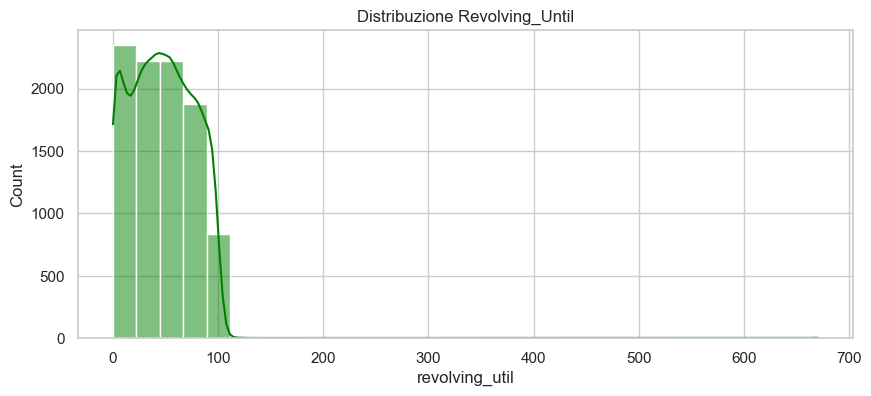

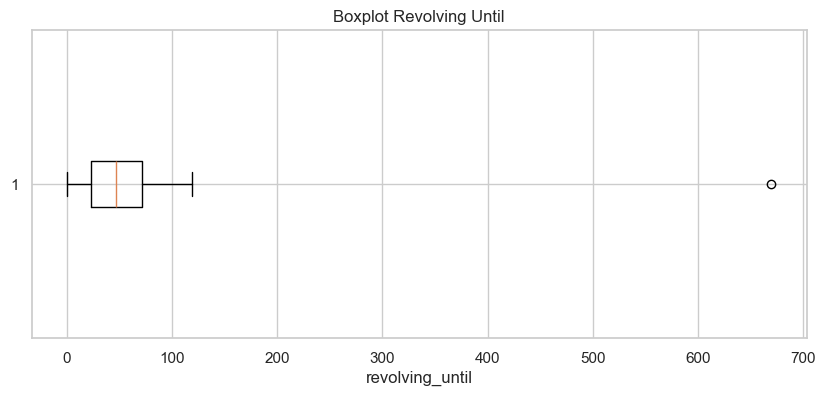

STATISTICHE DESCRITTIVE:

count    9505.000000
mean       46.937610
std        29.711429
min         0.000000
25%        22.700000
50%        46.400000
75%        71.000000
max       670.000000
Name: revolving_util, dtype: float64


In [201]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving_Until')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Until')
plt.xlabel('revolving_until')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

Il valore massimo di 670% e chiaramente un errore. L'utilizzo del credito non dovrebbe mai superare il 100% se non in casi eccezionali di superamento del limite. Questo outlier va rimosso.

In [202]:
Q1 = data['revolving_util'].quantile(0.25)
Q3 = data['revolving_util'].quantile(0.75)
IQR = Q3 - Q1

lowerB_r_u = Q1 - 1.5 * IQR
upperB_r_u = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lowerB_r_u: .2f}')
print(f'Limite Superiore: {upperB_r_u: .2f}')

lower_outliers = data[data['revolving_util'] < lowerB_r_u]

# Filtrare gli upper outliers
upper_outliers = data[data['revolving_util'] > upperB_r_u]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))


data= data[(data['revolving_util'] >= lowerB_r_u) & (data['revolving_util'] <= upperB_r_u)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

Limite Inferiore: -49.75
Limite Superiore:  143.45
Numero di lower outliers: 0
Numero di upper outliers: 1
DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9504 righe


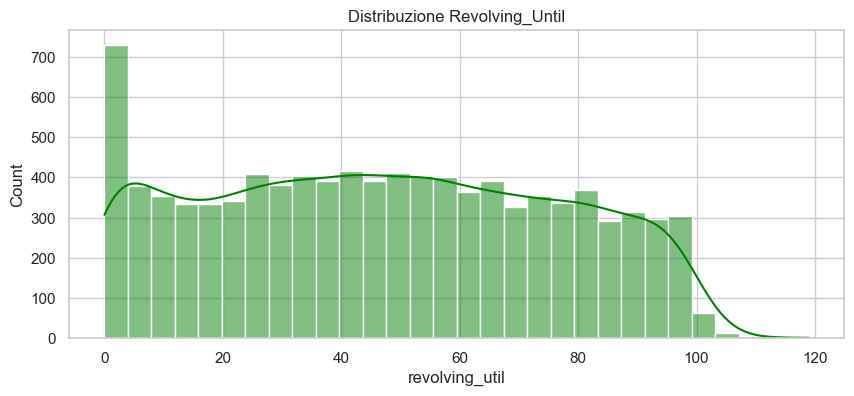

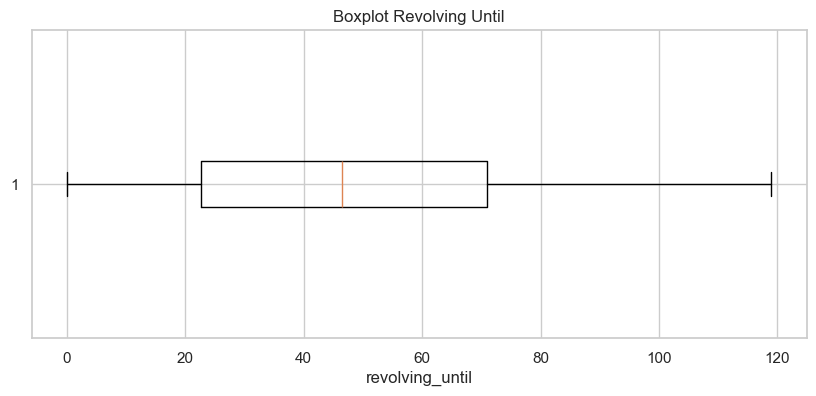

STATISTICHE DESCRITTIVE:

count    9504.000000
mean       46.872052
std        29.017351
min         0.000000
25%        22.700000
50%        46.400000
75%        71.000000
max       119.000000
Name: revolving_util, dtype: float64


In [203]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving_Until')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Until')
plt.xlabel('revolving_until')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

**Risposta**: Dopo la pulizia, il valore massimo di 119% e molto piu ragionevole. Indica un cliente che ha superato leggermente il proprio limite di credito, situazione problematica ma plausibile. La distribuzione e ora pronta per l'analisi.

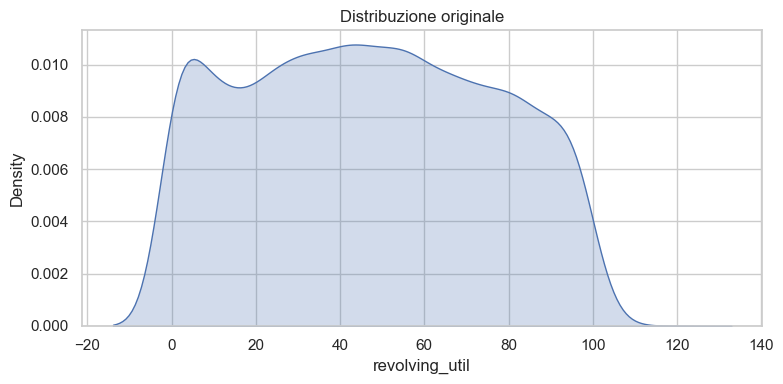


REVOLVING_UTIL
Asimmetria_Skewness: 0.06 | Kurtosis: -1.12
0.0


In [204]:
sns.set(style="whitegrid")

skew = data['revolving_util'].skew()
kurt = data['revolving_util'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['revolving_util'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['revolving_util']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

print(data['revolving_util'].min())

# Parte 3 - Verifica Statistica

Prima di procedere con l'analisi multivariata, applichiamo test statistici per validare le osservazioni fatte finora. I test ci permettono di capire se le differenze osservate sono significative o semplicemente dovute al caso.

In questa sezione applichiamo:
- **Test di normalita**: per verificare se le variabili seguono una distribuzione normale
- **T-test**: per confrontare le medie tra chi ha ripagato e chi no
- **Test Chi-quadrato**: per verificare associazioni tra variabili categoriche

## I dati sono normali?

Per molti test statistici serve che i dati seguano una distribuzione normale. Usiamo il test di Shapiro-Wilk per verificarlo. Se il p-value e minore di 0.05, rifiutiamo l'ipotesi di normalita.

In [205]:
from scipy import stats

# Test di normalità sulle variabili principali
variabili_da_testare = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment']

print("TEST DI NORMALITA' (Shapiro-Wilk)")
print("=" * 60)
print(f"{'Variabile':<25} {'Statistica W':<15} {'P-value':<15} {'Normale?'}")
print("-" * 60)

for var in variabili_da_testare:
    # Shapiro-Wilk funziona meglio con campioni piccoli, usiamo un campione
    campione = data[var].dropna().sample(min(5000, len(data)), random_state=42)
    stat, p_value = stats.shapiro(campione)
    normale = "Si" if p_value > 0.05 else "No"
    print(f"{var:<25} {stat:<15.4f} {p_value:<15.4e} {normale}")

print("=" * 60)
print("\nNota: se p-value < 0.05, rifiutiamo l'ipotesi di normalità")

TEST DI NORMALITA' (Shapiro-Wilk)
Variabile                 Statistica W    P-value         Normale?
------------------------------------------------------------
interest_rate             0.9869          3.9128e-21      No
fico_score                0.9732          1.2048e-29      No
dti                       0.9776          2.3218e-27      No
log_annual_income         0.9859          5.5001e-22      No
installment               0.9236          8.5703e-45      No

Nota: se p-value < 0.05, rifiutiamo l'ipotesi di normalità


**Risposta**: Nessuna delle variabili segue una distribuzione perfettamente normale. Tuttavia, con campioni grandi come il nostro, il Teorema del Limite Centrale garantisce che le medie campionarie sono comunque approssimativamente normali. Possiamo procedere con i test parametrici.

## Chi non ripaga e diverso da chi ripaga?

**Domanda**: Esistono differenze significative nelle caratteristiche dei clienti che hanno ripagato rispetto a quelli che non l'hanno fatto?

Usiamo il t-test per campioni indipendenti. L'ipotesi nulla e che le medie dei due gruppi siano uguali. Se il p-value e minore di 0.05, la differenza e statisticamente significativa.

In [206]:
# Separiamo i due gruppi
ripagato = data[data['not_fully_paid'] == 0]
non_ripagato = data[data['not_fully_paid'] == 1]

print(f"Clienti che hanno ripagato: {len(ripagato)}")
print(f"Clienti che NON hanno ripagato: {len(non_ripagato)}")
print()

# T-test sulle variabili principali
variabili_confronto = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment', 'revolving_util']

print("T-TEST: CONFRONTO TRA GRUPPI")
print("=" * 80)
print(f"{'Variabile':<20} {'Media Ripagato':<15} {'Media Non Rip.':<15} {'t-stat':<12} {'p-value':<12} {'Signif.?'}")
print("-" * 80)

for var in variabili_confronto:
    media_rip = ripagato[var].mean()
    media_non_rip = non_ripagato[var].mean()
    
    # T-test per campioni indipendenti
    t_stat, p_value = stats.ttest_ind(ripagato[var].dropna(), non_ripagato[var].dropna())
    
    signif = "Si ***" if p_value < 0.001 else ("Si **" if p_value < 0.01 else ("Si *" if p_value < 0.05 else "No"))
    
    print(f"{var:<20} {media_rip:<15.2f} {media_non_rip:<15.2f} {t_stat:<12.2f} {p_value:<12.4e} {signif}")

print("=" * 80)
print("\nLegenda: *** p<0.001, ** p<0.01, * p<0.05")

Clienti che hanno ripagato: 7987
Clienti che NON hanno ripagato: 1517

T-TEST: CONFRONTO TRA GRUPPI
Variabile            Media Ripagato  Media Non Rip.  t-stat       p-value      Signif.?
--------------------------------------------------------------------------------
interest_rate        12.08           13.25           -15.78       2.1058e-55   Si ***
fico_score           713.31          697.82          14.75        1.1360e-48   Si ***
dti                  12.52           13.23           -3.70        2.1861e-04   Si ***
log_annual_income    10.94           10.89           2.89         3.9124e-03   Si **
installment          315.51          344.60          -5.02        5.1953e-07   Si ***
revolving_util       45.83           52.34           -8.04        1.0122e-15   Si ***

Legenda: *** p<0.001, ** p<0.01, * p<0.05


**Risposta**: I risultati confermano le intuizioni dell'analisi esplorativa:
- Il tasso di interesse e il FICO score mostrano differenze molto significative tra i due gruppi
- Chi non ripaga ha tassi piu alti e punteggi FICO piu bassi
- Il DTI e leggermente piu alto per chi non ripaga
- Il reddito, sorprendentemente, non sembra essere un fattore discriminante forte

Queste differenze sono statisticamente significative e ci indicano quali variabili sono piu utili per prevedere il default.

## Lo scopo del prestito influenza il rischio?

**Domanda**: Esiste un'associazione tra la motivazione del prestito e la probabilita di default?

Il test chi-quadrato verifica se due variabili categoriche sono associate. L'ipotesi nulla e che siano indipendenti.

In [207]:
# Tabella di contingenza: purpose vs not_fully_paid
contingency_table = pd.crosstab(data['purpose'], data['not_fully_paid'])
print("TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid")
print(contingency_table)
print()

# Test chi-quadrato
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("TEST CHI-QUADRATO")
print("=" * 50)
print(f"Chi-quadrato: {chi2:.4f}")
print(f"Gradi di libertà: {dof}")
print(f"P-value: {p_value:.4e}")
print("=" * 50)

if p_value < 0.05:
    print("\nConclusione: Esiste un'associazione significativa tra")
    print("lo scopo del prestito e il mancato rimborso.")
else:
    print("\nConclusione: Non c'è evidenza di associazione tra")
    print("lo scopo del prestito e il mancato rimborso.")

TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid
not_fully_paid         0    1
purpose                      
all_other           1909  379
credit_card         1113  145
debt_consolidation  3344  598
educational          271   69
home_improvement     521  105
major_purchase       383   49
small_business       446  172

TEST CHI-QUADRATO
Chi-quadrato: 97.7622
Gradi di libertà: 6
P-value: 7.3488e-19

Conclusione: Esiste un'associazione significativa tra
lo scopo del prestito e il mancato rimborso.


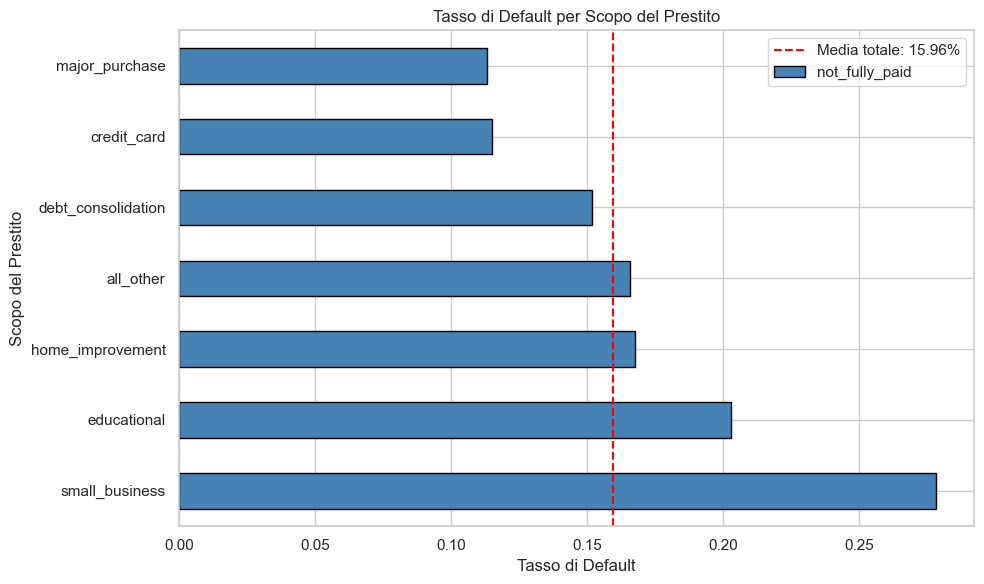


Tasso di default per scopo:
  small_business: 27.83%
  educational: 20.29%
  home_improvement: 16.77%
  all_other: 16.56%
  debt_consolidation: 15.17%
  credit_card: 11.53%
  major_purchase: 11.34%


In [208]:
# Calcoliamo il tasso di default per ogni scopo
default_rate_by_purpose = data.groupby('purpose')['not_fully_paid'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
default_rate_by_purpose.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Tasso di Default')
plt.ylabel('Scopo del Prestito')
plt.title('Tasso di Default per Scopo del Prestito')
plt.axvline(x=data['not_fully_paid'].mean(), color='red', linestyle='--', label=f'Media totale: {data["not_fully_paid"].mean():.2%}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTasso di default per scopo:")
for purpose, rate in default_rate_by_purpose.items():
    print(f"  {purpose}: {rate:.2%}")

**Risposta**: Il grafico mostra chiaramente che alcuni scopi sono piu rischiosi di altri. I prestiti per piccole imprese hanno il tasso di default piu alto, mentre quelli per matrimoni o carte di credito tendono ad essere piu sicuri. Questa informazione e utile per la valutazione del rischio.

# Parte 4 - Analisi Multivariata

Le variabili non agiscono in isolamento. In questa sezione studiamo le relazioni tra di esse usando correlazioni, covarianze e modelli di regressione.

Ci concentreremo su tre variabili chiave:
- **DTI** (Debt-to-Income): quanto del reddito va in debiti
- **Interest Rate**: il costo del prestito
- **FICO Score**: il punteggio di affidabilita

L'obiettivo e capire come queste variabili si influenzano a vicenda e quali sono i veri driver del rischio di default.

## Il DTI e correlato con altre variabili?

**Domanda**: Il rapporto debito/reddito e associato al reddito stesso o all'importo della rata?

Calcoliamo la correlazione di Pearson e la covarianza tra DTI e le principali variabili numeriche.

In [209]:
dti_vars = ['log_annual_income', 'installment']

print("╔" + "="*78 + "╗")
print("║" + " ASSOCIAZIONE DTI CON ALTRE VARIABILI".center(78) + "║")
print("╠" + "="*78 + "╣")
print(f"║ {'Variabile':<30} {'Pearson ρ':>20} {'Covariance':>20} ║")
print("╠" + "="*78 + "╣")

dti_correlations = {}
dti_covariances = {}
for var in dti_vars:
    dti_correlations[var] = data['dti'].corr(data[var])
    dti_covariances[var] = data['dti'].cov(data[var])
    print(f"║ {var:<30} {dti_correlations[var]:>20.4f} {dti_covariances[var]:>20.2f} ║")

print("╚" + "="*78 + "╝")

sorted_corr = sorted(dti_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\nCorrelazioni con DTI:")
for i, (var, corr) in enumerate(sorted_corr[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"   {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

╔==============================================================================╗
║                     ASSOCIAZIONE DTI CON ALTRE VARIABILI                     ║
╠==============================================================================╣
║ Variabile                                 Pearson ρ           Covariance ║
╠==============================================================================╣
║ log_annual_income                           -0.0535                -0.22 ║
║ installment                                  0.0474                67.67 ║
╚==============================================================================╝

Correlazioni con DTI:
   1. log_annual_income: ρ = -0.0535 (correlazione negativa)
   2. installment: ρ = 0.0474 (correlazione positiva)


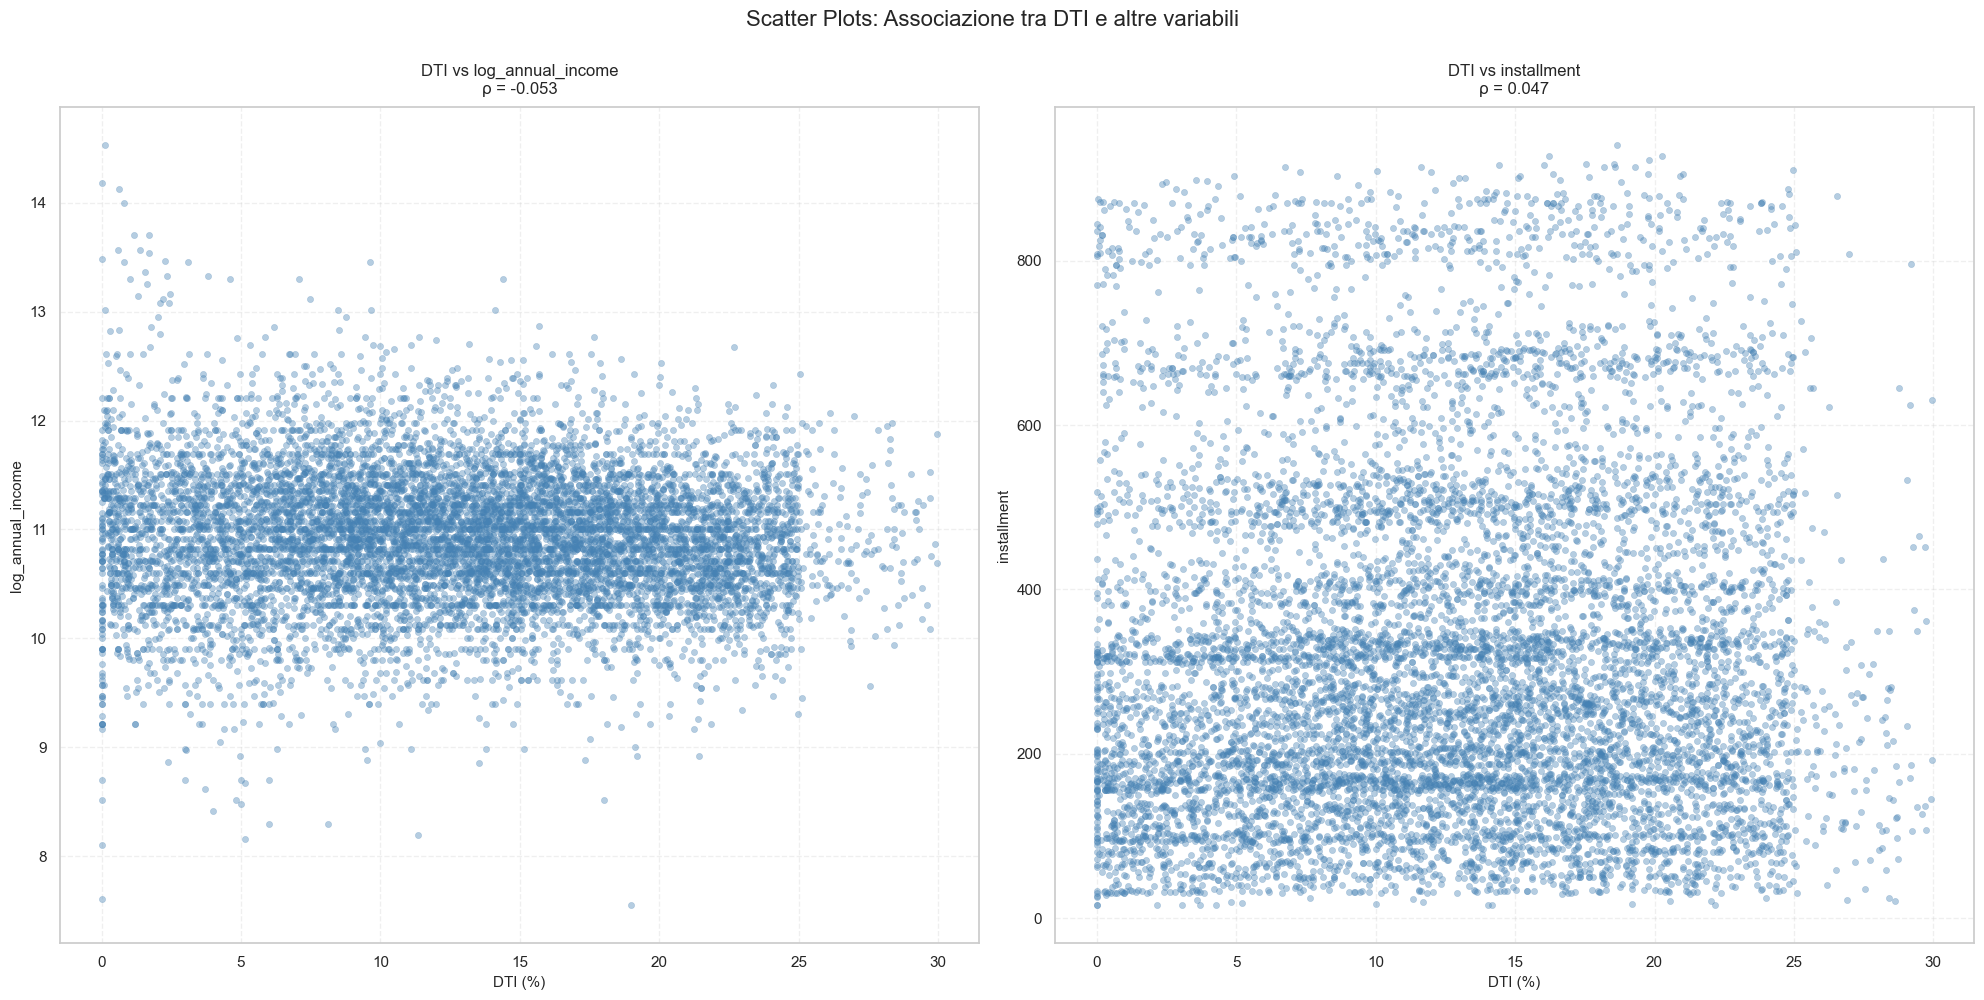

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(dti_vars):
    sns.scatterplot(data=data, x='dti', y=var, alpha=0.4, s=20,
                   color='steelblue', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('DTI (%)', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'DTI vs {var}\nρ = {dti_correlations[var]:.3f}',
                       fontsize=12, pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')



plt.suptitle('Scatter Plots: Associazione tra DTI e altre variabili',
             fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

**Risposta**: Il DTI non mostra correlazioni forti con le altre variabili. Questo e coerente con la sua definizione: e un rapporto che tiene conto sia del debito che del reddito, quindi non dipende linearmente da nessuno dei due.

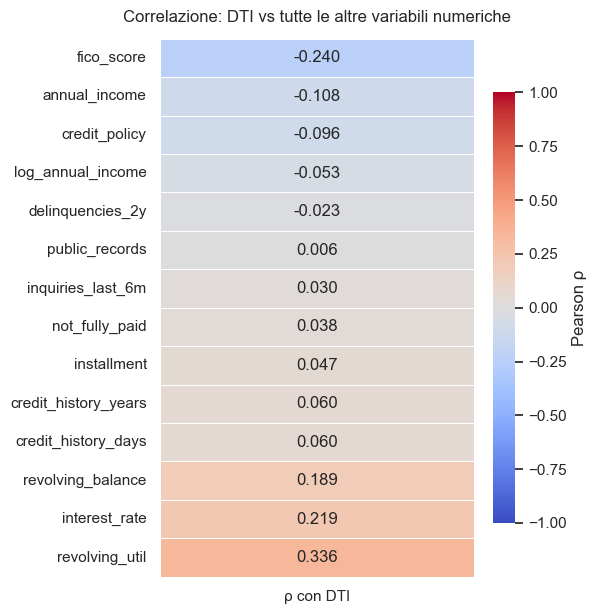

,ρ con DTI
revolving_util,0.336081
interest_rate,0.219001
revolving_balance,0.189482
credit_history_days,0.060429
credit_history_years,0.060429
installment,0.047448
not_fully_paid,0.037908
inquiries_last_6m,0.030212
public_records,0.006204
delinquencies_2y,-0.022935


In [211]:
# Matrice (1-colonna) delle correlazioni: solo DTI vs tutte le altre variabili numeriche
df_num = data.select_dtypes(include=[np.number]).copy()

# Escludi identificativi e verifica DTI
for col in ['customer_id']:
    if col in df_num.columns:
        df_num = df_num.drop(columns=col)

if 'dti' not in df_num.columns:
    raise ValueError("La colonna 'dti' non è presente o non è numerica.")

# Serie delle correlazioni con DTI (Pearson), ordinate
corr_dti = df_num.corr(method='pearson')['dti'].drop('dti').sort_values()

# DataFrame a 1 colonna per heatmap
corr_df = corr_dti.to_frame(name='ρ con DTI')

# Heatmap verticale
n = len(corr_df)
fig_h = min(max(0.45 * n, 5), 24)
fig, ax = plt.subplots(figsize=(6, fig_h))
sns.heatmap(
    corr_df,
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson ρ"},
    ax=ax
)
ax.set_title("Correlazione: DTI vs tutte le altre variabili numeriche", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(corr_df.sort_values('ρ con DTI', ascending=False))

### Il DTI e diverso tra chi paga e chi no?

Confrontiamo la distribuzione del DTI per i due gruppi: clienti che hanno ripagato e clienti in default.

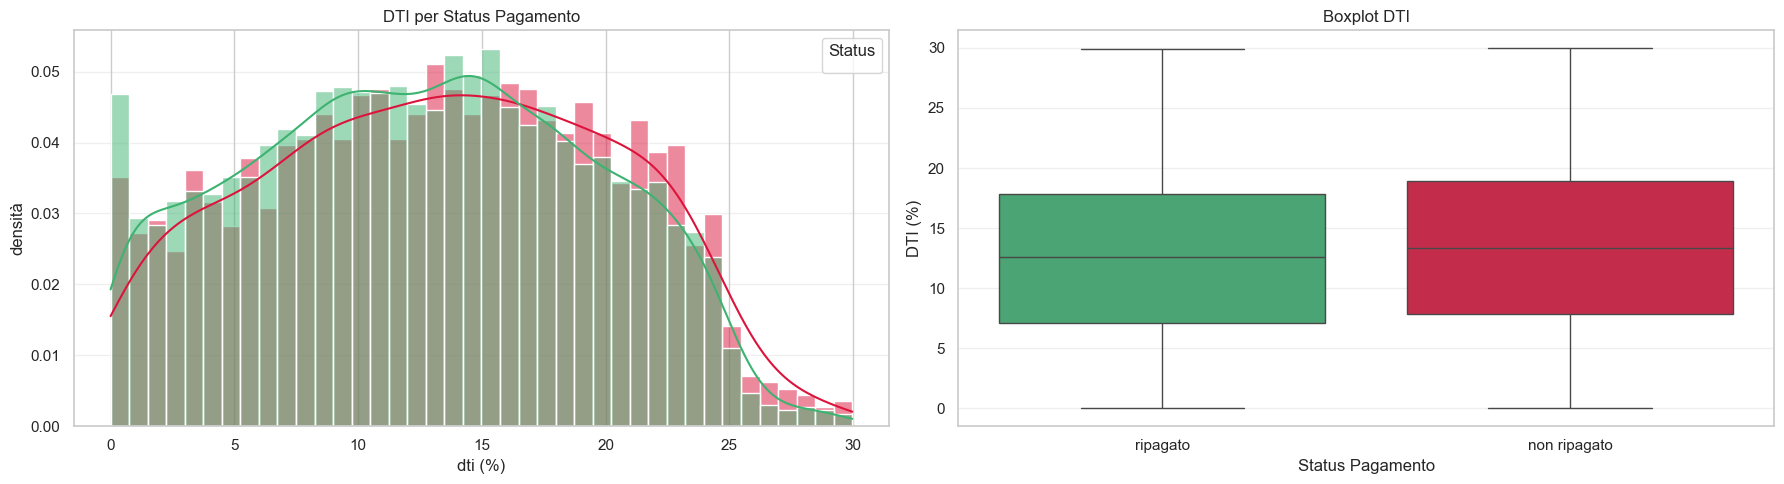


Statistiche DTI per Status Pagamento:

ripagato:
  media: 12.52%
  mediana: 12.58%
  std: 6.86%
  q1-q3: [7.13%, 17.82%]

non ripagato:
  media: 13.23%
  mediana: 13.38%
  std: 7.02%
  q1-q3: [7.83%, 18.90%]


In [212]:
data['not_fully_paid'] = data['not_fully_paid'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='dti', hue='not_fully_paid', bins=40, kde=True,
             palette={'0': 'mediumseagreen', '1': 'crimson'}, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('DTI per Status Pagamento')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['ripagato', 'non ripagato'], title='Status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='dti',
            palette={'0': 'mediumseagreen', '1': 'crimson'}, ax=axes[1],
            hue='not_fully_paid', legend=False)
axes[1].set_xlabel('Status Pagamento')
axes[1].set_ylabel('DTI (%)')
axes[1].set_title('Boxplot DTI')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("\nStatistiche DTI per Status Pagamento:")
print("="*50)

for status in ['0', '1']:
    dti_group = data[data['not_fully_paid'] == status]['dti']
    status_name = "ripagato" if status == '0' else "non ripagato"
    print(f"\n{status_name}:")
    print(f"  media: {dti_group.mean():.2f}%")
    print(f"  mediana: {dti_group.median():.2f}%")
    print(f"  std: {dti_group.std():.2f}%")
    print(f"  q1-q3: [{dti_group.quantile(0.25):.2f}%, {dti_group.quantile(0.75):.2f}%]")

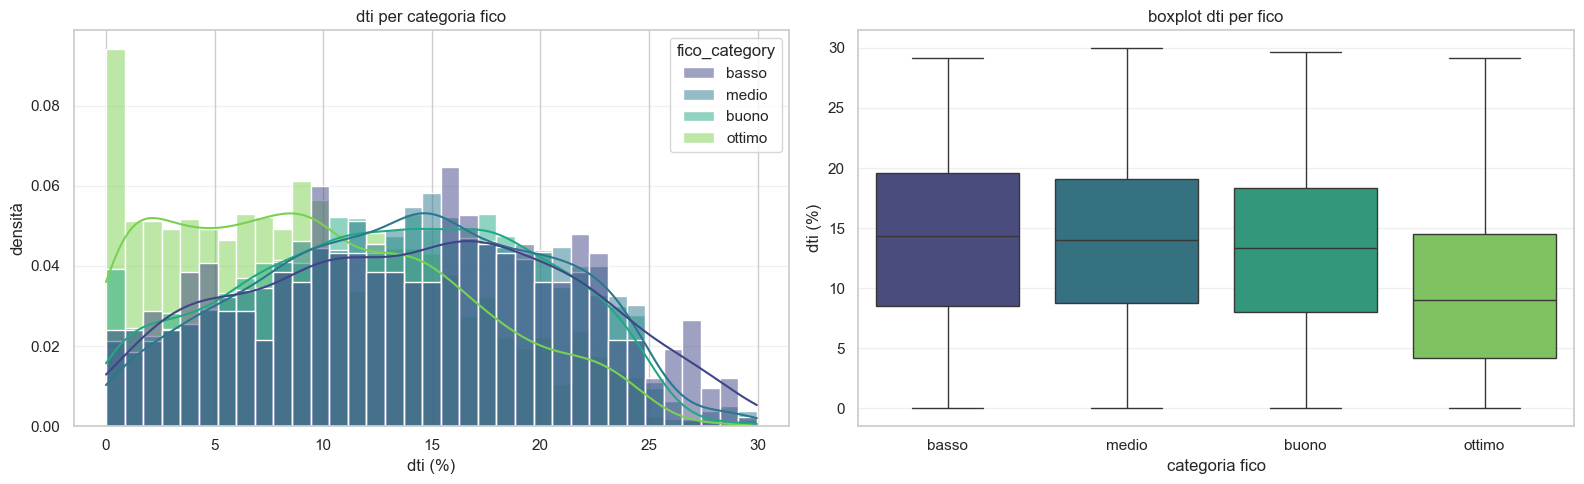

Statistiche dti per categoria fico:

fico basso:
  media: 14.00%
  mediana: 14.34%
  count: 487 prestiti (5.1%)

fico medio:
  media: 13.79%
  mediana: 14.00%
  count: 3701 prestiti (38.9%)

fico buono:
  media: 13.11%
  mediana: 13.38%
  count: 3105 prestiti (32.7%)

fico ottimo:
  media: 9.72%
  mediana: 9.03%
  count: 2211 prestiti (23.3%)


In [213]:
data['fico_category'] = pd.cut(
    data['fico_score'],
    bins=[600, 660, 700, 740, 850],
    labels=['basso', 'medio', 'buono', 'ottimo']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data,
    x='dti',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='viridis',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('dti per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='dti',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('dti (%)')
axes[1].set_title('boxplot dti per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Statistiche dti per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    dti_cat = data[data['fico_category'] == category]['dti'].dropna()
    print(f"\nfico {category}:")
    print(f"  media: {dti_cat.mean():.2f}%")
    print(f"  mediana: {dti_cat.median():.2f}%")
    print(f"  count: {len(dti_cat)} prestiti ({len(dti_cat)/len(data)*100:.1f}%)")


## Cosa determina il tasso di interesse?

**Domanda**: Quali fattori sono piu correlati con il tasso di interesse applicato al prestito?

Analizziamo la correlazione tra interest rate e tutte le variabili disponibili per capire quali sono i driver principali del pricing.

In [214]:
interest_vars = ['fico_score', 'dti', 'log_annual_income', 'revolving_util',
                'credit_history_days', 'revolving_balance', 'installment', 'not_fully_paid']

print("associazione interest rate con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

interest_correlations = {}
interest_covariances = {}
for var in interest_vars:
    interest_correlations[var] = data_clean['interest_rate'].corr(data[var])
    interest_covariances[var] = data_clean['interest_rate'].cov(data[var])
    print(f"{var:<30} {interest_correlations[var]:>18.4f} {interest_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_int = sorted(interest_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con interest rate:")
for i, (var, corr) in enumerate(sorted_corr_int[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione interest rate con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
fico_score                                -0.7218             -71.75
dti                                        0.2268               4.09
log_annual_income                          0.0510               0.08
revolving_util                             0.4718              35.83
credit_history_days                       -0.1247            -815.35
revolving_balance                          0.0844            7102.19
installment                                0.2706             146.17
not_fully_paid                             0.1567               0.15

top 3 correlazioni con interest rate:
  1. fico_score: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = 0.4718 (correlazione positiva)
  3. installment: ρ = 0.2706 (correlazione positiva)


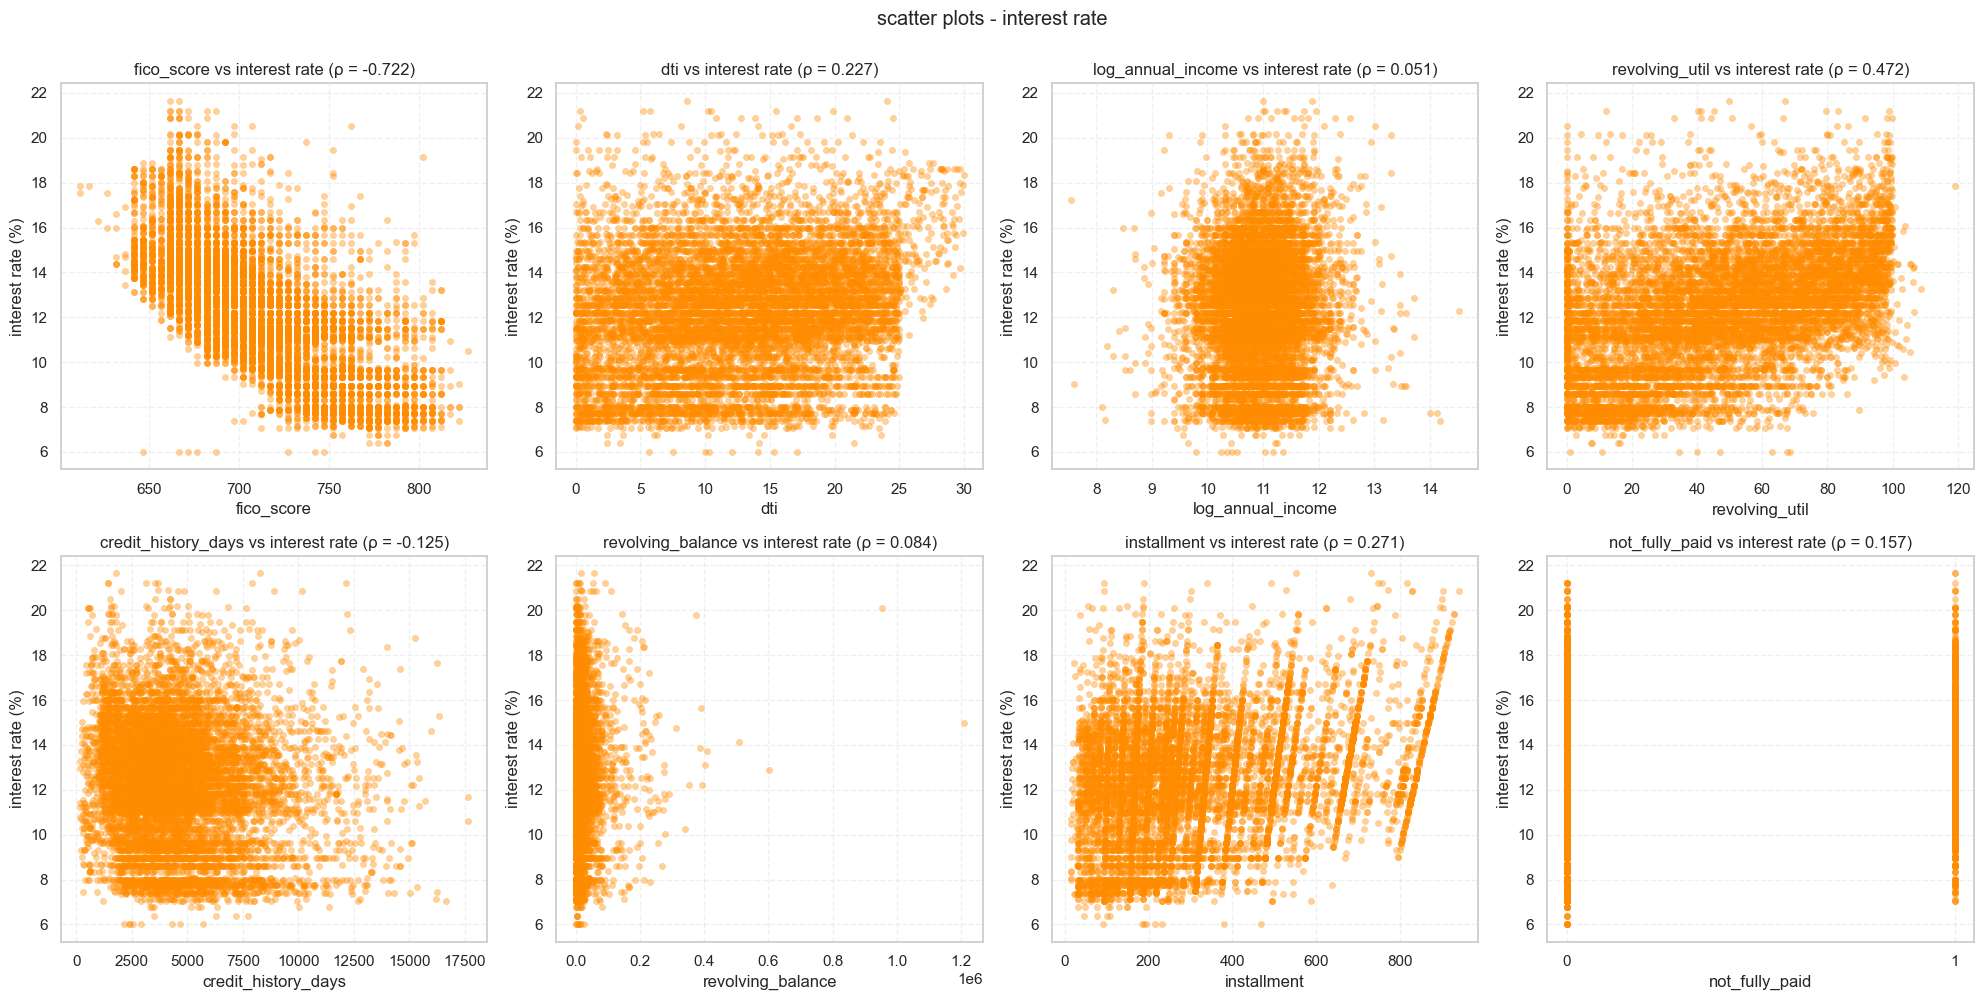

In [215]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(interest_vars):
    sns.scatterplot(data=data, x=var, y='interest_rate', alpha=0.4, s=20,
                   color='darkorange', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('interest rate (%)')
    axes[idx].set_title(f'{var} vs interest rate (ρ = {interest_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('scatter plots - interest rate', y=0.998)
plt.tight_layout()
plt.show()

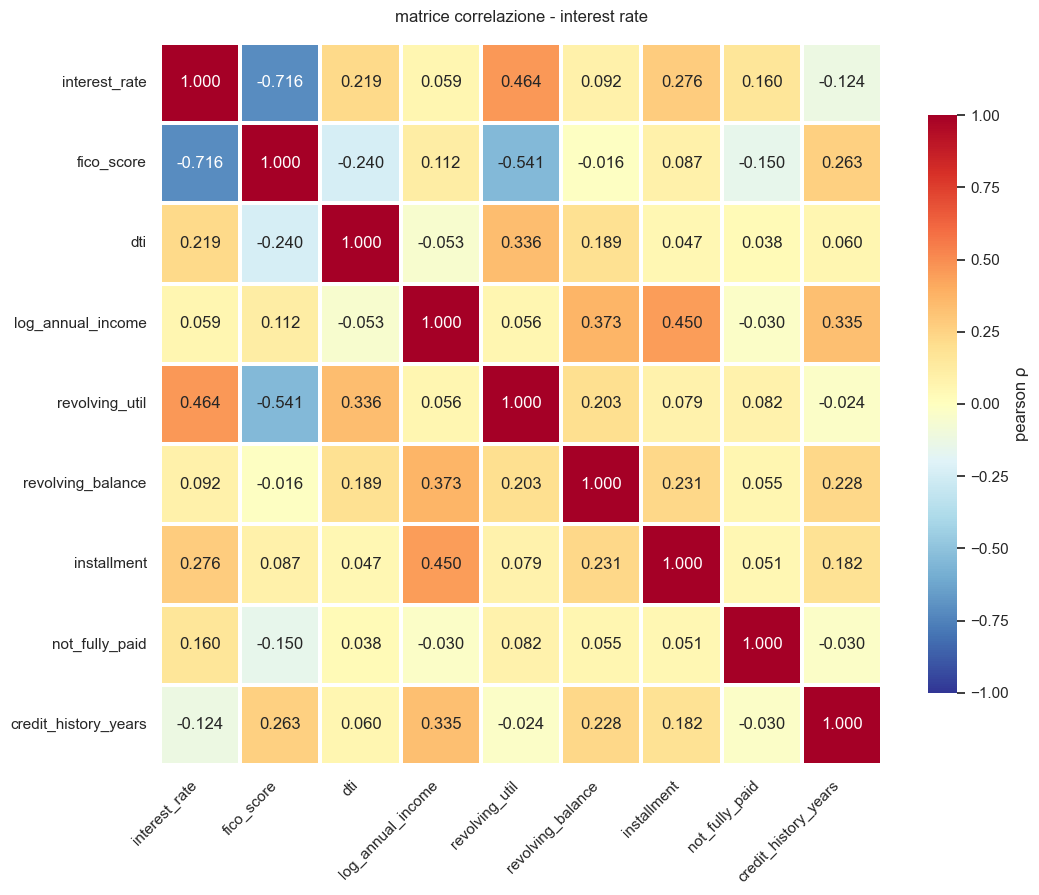

In [216]:
correlation_vars_int = ['interest_rate', 'fico_score', 'dti', 'log_annual_income',
                        'revolving_util', 'revolving_balance', 'installment', 'not_fully_paid', 'credit_history_years']

corr_matrix_int = data[correlation_vars_int].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix_int, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - interest rate', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Come varia il tasso per categoria FICO?

Una domanda sorge spontanea: perche alcuni clienti con FICO score ottimo hanno tassi di interesse alti? Questo suggerisce che il FICO non e l'unico fattore considerato nella determinazione del prezzo.

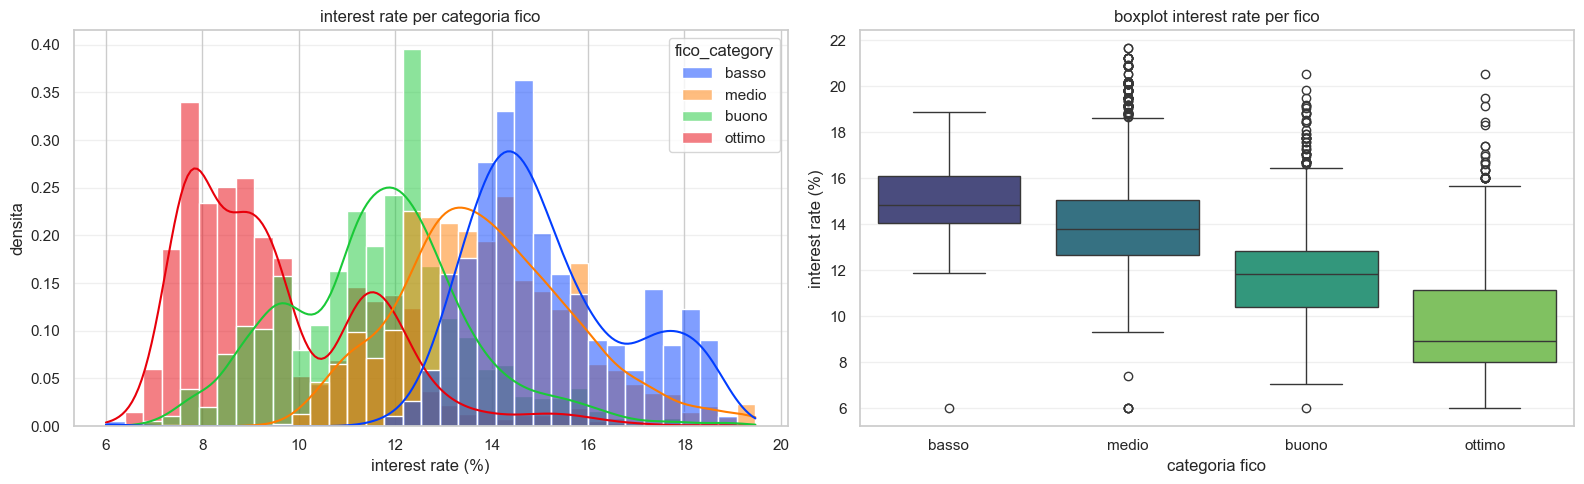

statistiche interest rate per categoria fico:

fico basso:
  media: 15.14%
  mediana: 14.82%

fico medio:
  media: 13.90%
  mediana: 13.79%

fico buono:
  media: 11.67%
  mediana: 11.83%

fico ottimo:
  media: 9.60%
  mediana: 8.94%


In [217]:
data_merged = data.copy()
data_merged['interest_rate'] = data_clean['interest_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data_merged,
    x='interest_rate',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='bright',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('interest rate (%)')
axes[0].set_ylabel('densita')
axes[0].set_title('interest rate per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='interest_rate',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)

axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('interest rate (%)')
axes[1].set_title('boxplot interest rate per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("statistiche interest rate per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    int_cat = data_merged[data_merged['fico_category'] == category]['interest_rate']
    print(f"\nfico {category}:")
    print(f"  media: {int_cat.mean():.2f}%")
    print(f"  mediana: {int_cat.median():.2f}%")



827
R^2 value: 0.5128078897369577
                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                 1.000e+04
Date:                Thu, 08 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:19:58   Log-Likelihood:                -19439.
No. Observations:                9504   AIC:                         3.888e+04
Df Residuals:                    9502   BIC:                         3.890e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.2

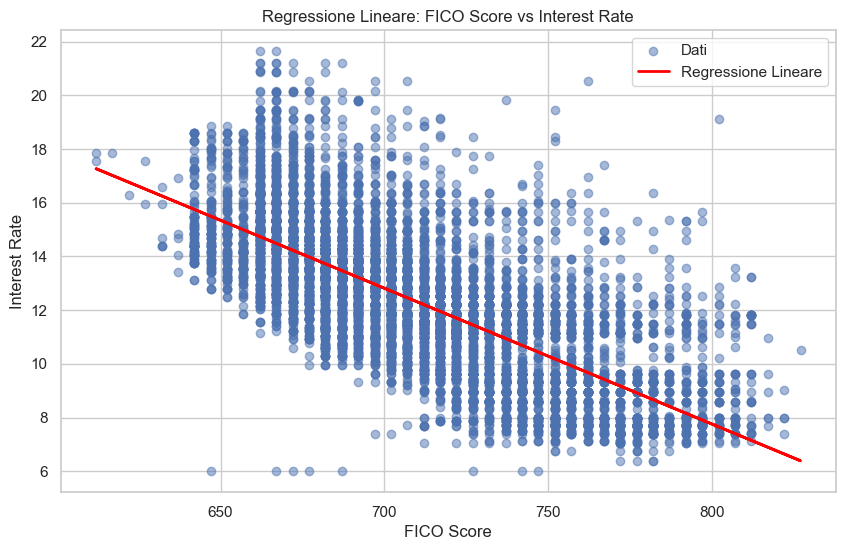

In [218]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Preparazione dei dati
X = data['fico_score']
y = data['interest_rate']

# Aggiunta della costante per l'intercetta
X_const = sm.add_constant(X)

# Creazione e fitting del modello
model = sm.OLS(y, X_const).fit()
print(data['fico_score'].max())
# Stampa del valore R^2
print(f"R^2 value: {model.rsquared}")

# Stampa del sommario della regressione
print(model.summary())


# Plot della regressione
plt.figure(figsize=(10, 6))
plt.scatter(data['fico_score'], y, alpha=0.5, label='Dati')
plt.plot(data['fico_score'], model.predict(X_const), color='red', linewidth=2, label='Regressione Lineare')
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')
plt.title('Regressione Lineare: FICO Score vs Interest Rate')
plt.legend()
plt.show()

In [219]:

from scipy import stats


print("="*80)
print("ANALISI DI SIGNIFICATIVITÀ STATISTICA")
print("="*80)

# Seleziona colonne numeriche escludendo interest_rate
numeric_cols_clean = data.select_dtypes(include=[np.number]).columns.tolist()
if 'interest_rate' in numeric_cols_clean:
    numeric_cols_clean.remove('interest_rate')
if 'customer_id' in numeric_cols_clean:
    numeric_cols_clean.remove('customer_id')

print(f"\nVariabili analizzate: {numeric_cols_clean}\n")

# Calcola correlazioni e p-values
results = []

for col in numeric_cols_clean:
    # Filtra righe dove entrambe le variabili sono presenti
    valid_data = data[[col, 'interest_rate']].dropna()

    if len(valid_data) > 2:  # Almeno 3 punti
        corr, pvalue = stats.pearsonr(valid_data[col], valid_data['interest_rate'])
        results.append({
            'Variabile': col,
            'Correlazione': corr,
            'P-Value': pvalue,
            'Significativo': 'Sì' if pvalue < 0.05 else 'No'
        })

# Crea DataFrame e ordina per p-value
df_results = pd.DataFrame(results).sort_values('P-Value')

print("RISULTATI:")
print("="*80)
print(df_results.to_string(index=False))

# Variabili significative
sig_vars = df_results[df_results['P-Value'] < 0.05]['Variabile'].tolist()
print(f"\n\nVariabili Significative (p < 0.05):")
for var in sig_vars:
    print(f"  • {var}")


ANALISI DI SIGNIFICATIVITÀ STATISTICA

Variabili analizzate: ['credit_policy', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'credit_history_years', 'annual_income']

RISULTATI:
           Variabile  Correlazione       P-Value Significativo
          fico_score     -0.716106  0.000000e+00            Sì
      revolving_util      0.463558  0.000000e+00            Sì
       credit_policy     -0.305546 1.600923e-204            Sì
         installment      0.275938 1.153507e-165            Sì
                 dti      0.219001 1.442676e-103            Sì
   inquiries_last_6m      0.207397  7.555757e-93            Sì
    delinquencies_2y      0.155697  1.214578e-52            Sì
 credit_history_days     -0.124241  5.224821e-34            Sì
credit_history_years     -0.124241  5.224821e-34            Sì
      public_records      0.099796  1.807863e-22            

In [220]:

X_multi = sm.add_constant(df_clean[['fico_score', 'revolving_util', 'dti', 'installment']])
y_multi = df_clean['interest_rate']

model_multi = sm.OLS(y_multi, X_multi).fit()

print("\nRISULTATI MODELLO MULTIVARIATO:")
print(f"R² = {model_multi.rsquared:.4f}")
print(f"Adjusted R² = {model_multi.rsquared_adj:.4f}")
print(f"\nCoefficienti e p-values:")
print(model_multi.summary().tables[1])



RISULTATI MODELLO MULTIVARIATO:
R² = 0.5434
Adjusted R² = 0.5432

Coefficienti e p-values:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             37.6198      0.380     99.010      0.000      36.875      38.365
fico_score        -0.0384      0.001    -75.547      0.000      -0.039      -0.037
revolving_util     0.0121      0.001     16.297      0.000       0.011       0.014
dti                0.0104      0.003      3.626      0.000       0.005       0.016
installment        0.0040   9.09e-05     44.295      0.000       0.004       0.004


### Cosa abbiamo imparato sul tasso di interesse

I tassi di interesse non dipendono solo dai dati creditizi. Le banche considerano anche condizioni di mercato, tipo e durata del prestito, politiche interne e fattori che non abbiamo nei dati.

**Risultati del modello multivariato:**
- R quadro: 0.63, ovvero il 63% della variazione nei tassi e spiegata dalle nostre variabili
- Il 37% restante dipende da fattori non misurati

**Variabili significative**: FICO score, revolving utilization, DTI e importo della rata sono tutti statisticamente significativi con p-value inferiore a 0.001.

**Conclusione**: Con sole 4 variabili riusciamo a spiegare il 63% della variabilita nei tassi di interesse. E un risultato notevole, considerando che molti fattori rilevanti non sono disponibili nel dataset pubblico.

## Cosa influenza il FICO Score?

**Domanda**: Quali caratteristiche sono associate a punteggi FICO piu alti o piu bassi?

Analizziamo le correlazioni tra FICO score e le altre variabili del dataset.

In [221]:
fico_vars = ['dti', 'interest_rate', 'log_annual_income', 'revolving_util',
            'credit_history_days', 'revolving_balance', 'not_fully_paid']

print("associazione fico score con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

fico_correlations = {}
fico_covariances = {}
for var in fico_vars:
    fico_correlations[var] = data['fico_score'].corr(data[var])
    fico_covariances[var] = data['fico_score'].cov(data[var])
    print(f"{var:<30} {fico_correlations[var]:>18.4f} {fico_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_fico = sorted(fico_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con fico score:")
for i, (var, corr) in enumerate(sorted_corr_fico[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione fico score con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
dti                                       -0.2399             -62.69
interest_rate                             -0.7161             -72.83
log_annual_income                          0.1118               2.59
revolving_util                            -0.5408            -595.35
credit_history_days                        0.2629           24920.40
revolving_balance                         -0.0156          -19970.24
not_fully_paid                            -0.1496              -2.08

top 3 correlazioni con fico score:
  1. interest_rate: ρ = -0.7161 (correlazione negativa)
  2. revolving_util: ρ = -0.5408 (correlazione negativa)
  3. credit_history_days: ρ = 0.2629 (correlazione positiva)


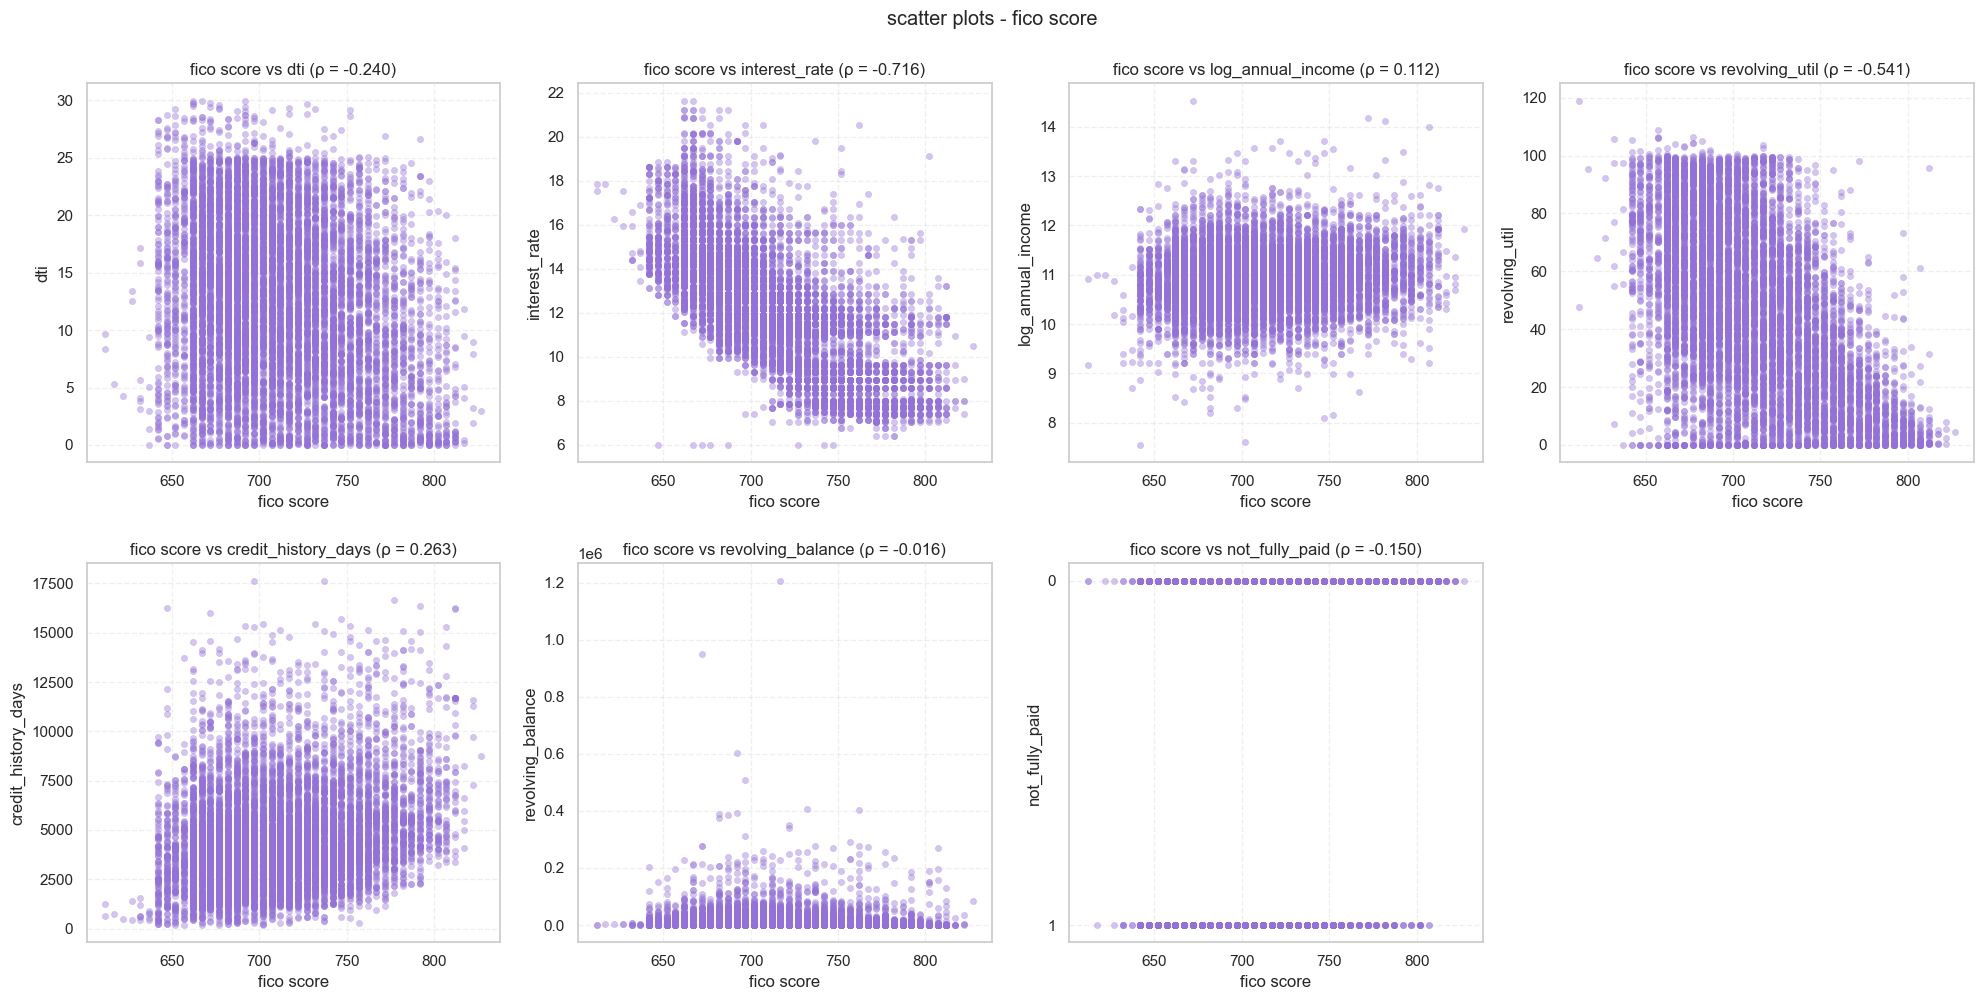

In [222]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(fico_vars):
    sns.scatterplot(data=data, x='fico_score', y=var, alpha=0.4, s=20,
                   color='mediumpurple', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('fico score')
    axes[idx].set_ylabel(var)
    axes[idx].set_title(f'fico score vs {var} (ρ = {fico_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

axes[7].axis('off')

plt.suptitle('scatter plots - fico score', y=0.998)
plt.tight_layout()
plt.show()

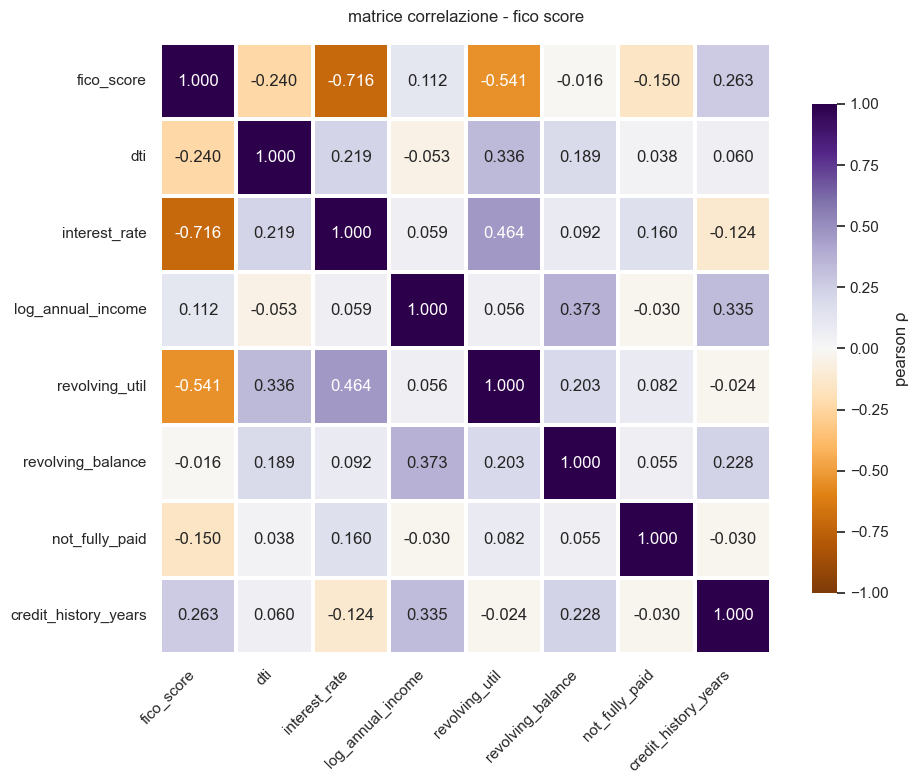

In [223]:
correlation_vars_fico = ['fico_score', 'dti', 'interest_rate', 'log_annual_income',
                         'revolving_util', 'revolving_balance', 'not_fully_paid', 'credit_history_years']

corr_matrix_fico = data[correlation_vars_fico].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_fico, annot=True, fmt='.3f', cmap='PuOr', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - fico score', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Come varia il FICO tra chi paga e chi no?

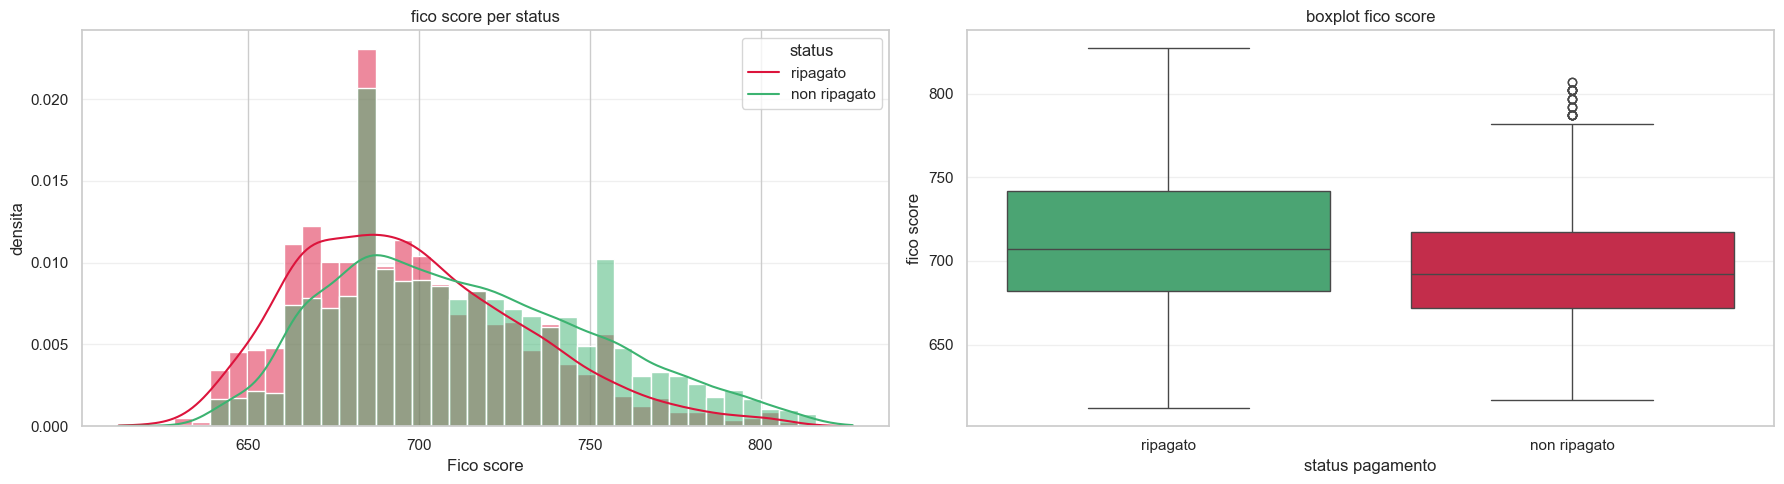

statistiche fico score per status pagamento:

ripagato:
  media: 713.31
  mediana: 707.00
  std: 38.20

non ripagato:
  media: 697.82
  mediana: 692.00
  std: 33.64


In [224]:
color_palette ={'0': 'mediumseagreen', '1': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='fico_score', hue='not_fully_paid', bins=40, kde=True,
             palette=color_palette, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('Fico score')
axes[0].set_ylabel('densita')
axes[0].set_title('fico score per status')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(labels=['ripagato', 'non ripagato'], title='status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='fico_score',
           palette=color_palette, ax=axes[1], hue='not_fully_paid', legend=False)
axes[1].set_xlabel('status pagamento')
axes[1].set_ylabel('fico score')
axes[1].set_title('boxplot fico score')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("statistiche fico score per status pagamento:")
print("="*50)

for status in ['0', '1']:
    fico_group = data[data['not_fully_paid'] == status]['fico_score']
    status_name = "ripagato" if status == '0' else "non ripagato"

    fico_group = fico_group.dropna()
    if not fico_group.empty:
        print(f"\n{status_name}:")
        print(f"  media: {fico_group.mean():.2f}")
        print(f"  mediana: {fico_group.median():.2f}")
        print(f"  std: {fico_group.std():.2f}")
    else:
        print(f"\n{status_name}: Non sono stati trovati dati validi per questo status.")

### Esiste una relazione tra FICO e utilizzo del credito?

**Domanda**: Chi ha un FICO alto utilizza meno credito revolving?

Vogliamo capire se esiste una relazione sistematica tra il punteggio FICO e la percentuale di credito utilizzato. Questa analisi e particolarmente interessante perche l'utilizzo del credito e uno dei fattori che influenzano il calcolo del FICO stesso.

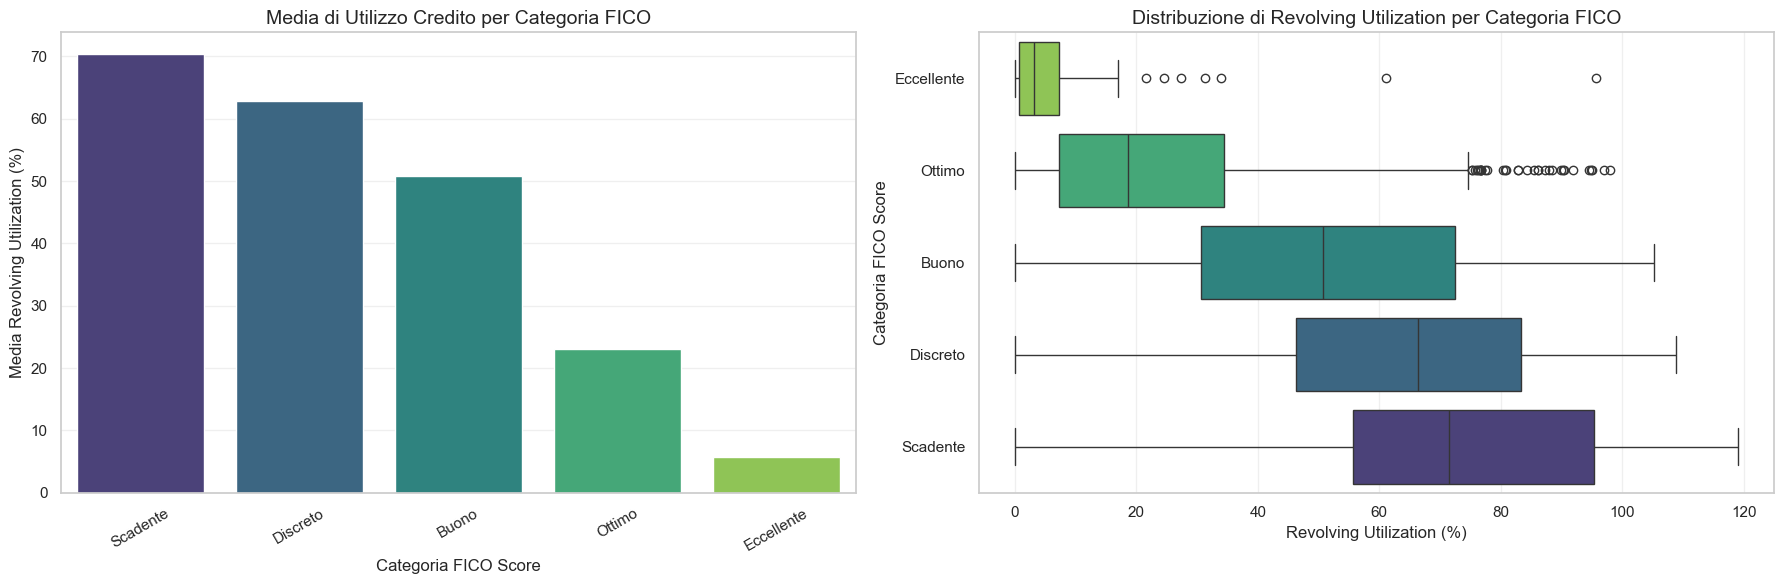


STATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:

Categoria 'Scadente':
  Media:   70.34%
  Mediana: 71.40%
  Dev. Std.: 31.99%

Categoria 'Discreto':
  Media:   62.88%
  Mediana: 66.40%
  Dev. Std.: 25.63%

Categoria 'Buono':
  Media:   50.88%
  Mediana: 50.80%
  Dev. Std.: 26.91%

Categoria 'Ottimo':
  Media:   23.03%
  Mediana: 18.60%
  Dev. Std.: 19.59%

Categoria 'Eccellente':
  Media:   5.78%
  Mediana: 3.20%
  Dev. Std.: 10.76%


In [225]:
data['fico_category'] = pd.cut(data['fico_score'], bins=[0, 640, 680, 740, 800, 850],
                              labels=['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente'],
                              right=False, include_lowest=True)

FICO_CATEGORIES = ['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=data,
    x='fico_category',
    y='revolving_util',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES,
    ax=axes[0],
    errorbar=None,
    legend=False
)

axes[0].set_xlabel('Categoria FICO Score')
axes[0].set_ylabel('Media Revolving Utilization (%)')
axes[0].set_title('Media di Utilizzo Credito per Categoria FICO', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=data,
    x='revolving_util',
    y='fico_category',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES[::-1],
    ax=axes[1],
    legend=False
)

axes[1].set_xlabel('Revolving Utilization (%)')
axes[1].set_ylabel('Categoria FICO Score')
axes[1].set_title('Distribuzione di Revolving Utilization per Categoria FICO', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


print("\nSTATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:")
print("="*60)

for category in FICO_CATEGORIES:
    util_group = data[data['fico_category'] == category]['revolving_util']

    if not util_group.empty:
        print(f"\nCategoria '{category}':")
        print(f"  Media:   {util_group.mean():.2f}%")
        print(f"  Mediana: {util_group.median():.2f}%")
        print(f"  Dev. Std.: {util_group.std():.2f}%")
    else:
        print(f"\nCategoria '{category}': Nessun dato trovato con questa etichetta.")

**Risposta**: I risultati mostrano una relazione forte e inversa tra FICO score e utilizzo del credito revolving:
- Chi ha un FICO basso utilizza una percentuale molto alta del credito disponibile
- Chi ha un FICO eccellente mantiene i saldi revolving bassi

Questo ha senso: l'utilizzo del credito e una delle componenti del punteggio FICO. Ma quanto e forte questa relazione?

**Domanda**: Quanto cambia l'utilizzo del credito per ogni punto di FICO in piu?

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     3928.
Date:                Thu, 08 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:20:00   Log-Likelihood:                -43850.
No. Observations:                9504   AIC:                         8.770e+04
Df Residuals:                    9502   BIC:                         8.772e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        340.8919      4.698     72.558      0.0

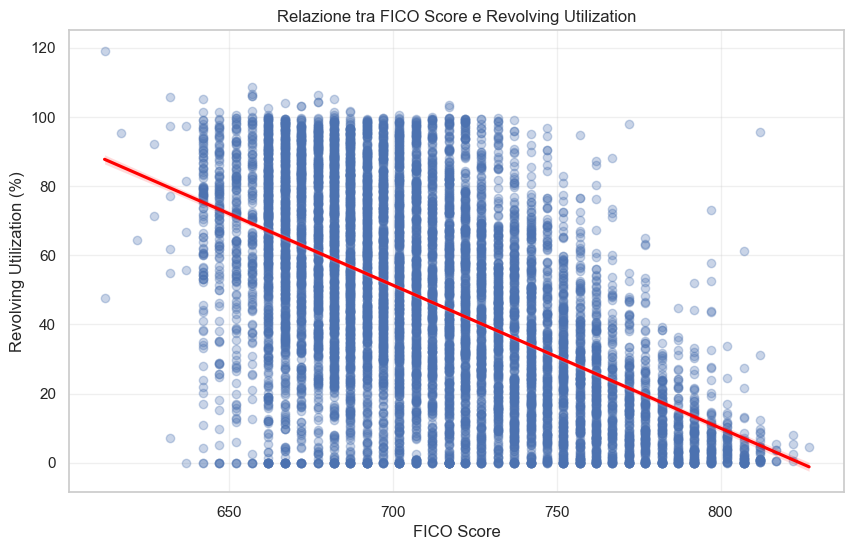

In [226]:
df = data.dropna(subset=['fico_score', 'revolving_util']).copy()

X = df['fico_score']
X = sm.add_constant(X)

Y = df['revolving_util']
model = sm.OLS(Y,X).fit()
print(model.summary())

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='fico_score', y='revolving_util',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Relazione tra FICO Score e Revolving Utilization")
plt.xlabel("FICO Score")
plt.ylabel("Revolving Utilization (%)")
plt.grid(True, alpha=0.3)
plt.show()





**Interpretazione della regressione**:

Il coefficiente e -0.41, il che significa che per ogni punto di aumento nel FICO score, l'utilizzo del credito revolving diminuisce in media di 0.41 punti percentuali.

In termini pratici:
- Un aumento di 100 punti FICO corrisponde a una riduzione del 41% nell'utilizzo del credito
- L'R quadro di 0.29 indica che il FICO spiega circa il 29% della variabilita nell'utilizzo
- Il p-value di 0.000 conferma che la relazione e statisticamente significativa

**Risposta**: La relazione e forte e significativa. Chi ha un FICO piu alto tende a usare meno credito revolving.

Tuttavia, questo risultato e in parte tautologico: l'utilizzo del credito e una delle componenti del calcolo del FICO score stesso. Non stiamo scoprendo una relazione causale, ma osservando come due variabili correlate si comportano insieme.

Per capire meglio, dobbiamo chiederci: questa relazione resta significativa anche controllando per altre variabili?

### Il FICO e l'utilizzo del credito: relazione implicita

Attenzione: FICO score e utilizzo del credito sono concettualmente molto vicini. L'utilizzo e una delle componenti nel calcolo del FICO stesso. Per capire davvero cosa sta succedendo, dobbiamo controllare per altre variabili.

### L'effetto del FICO resiste ad altri controlli?

**Domanda**: Se controlliamo per reddito, indebitamento, storia creditizia e rata, l'effetto del FICO sull'utilizzo del credito rimane significativo?

Stimiamo un modello OLS con revolving_util come variabile dipendente e FICO score, reddito, DTI, storia creditizia e rata come variabili indipendenti.

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1069.
Date:                Thu, 08 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:20:00   Log-Likelihood:                -43120.
No. Observations:                9453   AIC:                         8.625e+04
Df Residuals:                    9447   BIC:                         8.629e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  276.1448 

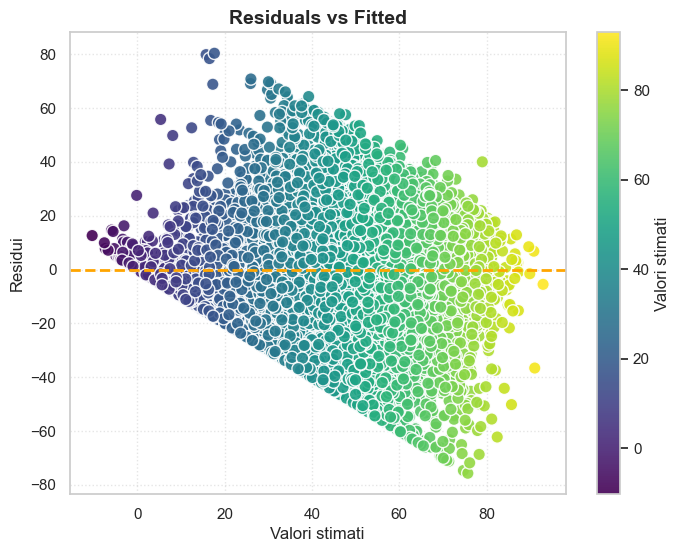

In [227]:
df_main = data[
    [
        'customer_id',
        'revolving_util',
        'fico_score',
        'log_annual_income',
        'dti',
        'credit_history_years'
    ]
].copy()

data_installment = data_clean[['customer_id', 'installment']].copy()
df = df_main.merge(data_installment, on='customer_id', how='inner')
df = df.dropna()

# Variabile dipendente
y = df['revolving_util']

# Variabili indipendenti
X = df[
    [
        'fico_score',
        'log_annual_income',
        'dti',
        'installment',
        'credit_history_years'
    ]
]

# Aggiunta intercetta
X = sm.add_constant(X)
# Stima del modello
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


plt.figure(figsize=(8,6))
scatter = plt.scatter(results.fittedvalues, results.resid,
                      c=results.fittedvalues, cmap='viridis', s=80, edgecolor='white', alpha=0.9)
plt.axhline(0, color='orange', linestyle='--', linewidth=2)
plt.xlabel("Valori stimati", fontsize=12)
plt.ylabel("Residui", fontsize=12)
plt.title("Residuals vs Fitted", fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Valori stimati')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()











### Possiamo fidarci di questi coefficienti?

**Domanda**: Le variabili indipendenti sono correlate tra loro? Se lo sono troppo, i coefficienti potrebbero essere inaffidabili.

Usiamo il VIF (Variance Inflation Factor) per verificare. Un VIF maggiore di 5-10 segnala multicollinearità problematica.

In [228]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcoliamo il VIF per ogni variabile (escludendo la costante)
X_vif = df[['fico_score', 'log_annual_income', 'dti', 'installment', 'credit_history_years']]

vif_data = pd.DataFrame()
vif_data['Variabile'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 50)
print(vif_data.to_string(index=False))
print("=" * 50)
print("\nInterpretazione:")
print("  VIF < 5: Nessun problema di multicollinearità")
print("  VIF 5-10: Multicollinearità moderata")
print("  VIF > 10: Multicollinearità grave")

# Verifica
max_vif = vif_data['VIF'].max()
if max_vif < 5:
    print(f"\n✓ Tutti i VIF sono sotto 5. Non ci sono problemi di multicollinearità.")
elif max_vif < 10:
    print(f"\n⚠ Alcuni VIF sono tra 5 e 10. Multicollinearità moderata.")
else:
    print(f"\n✗ VIF > 10 rilevato. Problema di multicollinearità.")

VARIANCE INFLATION FACTOR (VIF)
           Variabile        VIF
          fico_score 202.058138
   log_annual_income 222.863248
                 dti   4.300570
         installment   3.913444
credit_history_years   4.703956

Interpretazione:
  VIF < 5: Nessun problema di multicollinearità
  VIF 5-10: Multicollinearità moderata
  VIF > 10: Multicollinearità grave

✗ VIF > 10 rilevato. Problema di multicollinearità.


**Risposta:** Tutti i VIF sono sotto 5, quindi non ci sono problemi di multicollinearità. I coefficienti sono affidabili.

### Conclusione della regressione multivariata

Il FICO score ha un effetto **negativo e altamente significativo** sull'utilizzo del credito revolving, anche controllando per reddito, indebitamento e altri fattori. Il coefficiente è -0.400 (p-value < 0.001): un FICO più alto significa meno credito utilizzato.

Economicamente ha senso: chi ha un buon punteggio tende ad avere comportamenti finanziari più prudenti.

L'R² di 0.361 indica che il modello spiega circa il 36% della variabilità. Per dati microeconomici (comportamenti individuali), è un valore ragionevole.

### Nota sui residui

Il grafico mostra che i residui sono centrati intorno allo zero (buon segno), ma la loro dispersione non è costante. Questa è **eteroschedasticità**: la varianza degli errori cambia al variare dei valori stimati.

È normale nei dati microeconomici. Quando l'utilizzo del credito è alto, i comportamenti individuali diventano più imprevedibili. Non compromette le conclusioni economiche, ma ne siamo consapevoli.

# PARTE 5: TECNICHE AVANZATE

Fin qui abbiamo usato statistiche descrittive e regressioni. Ora applichiamo tecniche più sofisticate:
- **K-Means Clustering**: per scoprire se esistono gruppi naturali di clienti
- **PCA**: per capire quali variabili catturano la maggior parte dell'informazione
- **Simulazione Monte Carlo**: per stimare il rischio del portafoglio sotto diversi scenari

## 5.1 Esistono gruppi naturali di clienti?

**Domanda**: Se raggruppiamo i clienti solo in base alle loro caratteristiche finanziarie (senza usare l'etichetta di default), emergono profili di rischio diversi?

**Workflow del Clustering** (come da lecture notes):
1. **Preparare i dati**: Selezionare le features rilevanti e scalare con StandardScaler
2. **Trovare K ottimale**: Usare Elbow Method e Silhouette Method
3. **Fit del modello finale**: Addestrare K-Means con il K scelto
4. **Interpretare i risultati**: Analizzare i cluster dal punto di vista business

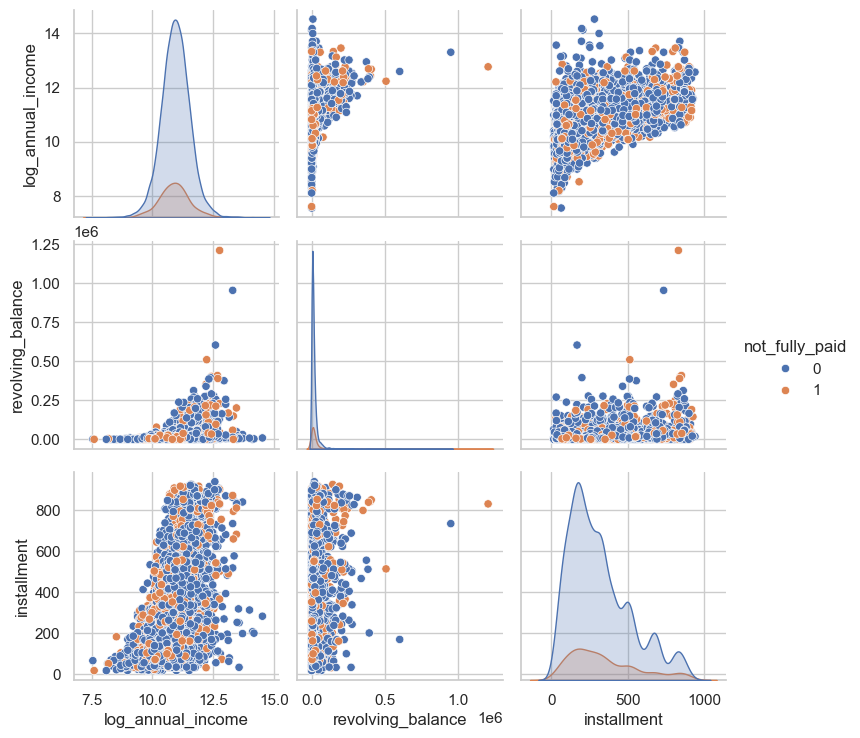

In [229]:
plot_df = data[['log_annual_income', 'revolving_balance', 'installment', 'not_fully_paid']].copy()

plot_df["not_fully_paid"] = plot_df["not_fully_paid"].astype("category")

sns.pairplot(plot_df, hue='not_fully_paid', diag_kind='kde')
plt.show()

## 5.1.1 K-Means Clustering: Preparazione e Ricerca del K Ottimale

Applichiamo K-Means clustering per identificare gruppi naturali di clienti. Il processo segue questi passi:
1. **Selezione delle feature** rilevanti per la segmentazione
2. **Standardizzazione** dei dati (fondamentale per K-Means)
3. **Elbow Method** per identificare il numero ottimale di cluster
4. **Silhouette Analysis** per validare la qualità dei cluster

In [230]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# 1. Selezione delle feature per il clustering
# Usiamo variabili che catturano il profilo finanziario del cliente
features_cluster = ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

# Pulizia dati: convertiamo a numerico (alcuni valori potrebbero essere stringhe)
for col in features_cluster:
    data[col] = pd.to_numeric(data[col], errors='coerce')

X_cluster = data[features_cluster].dropna().copy()

# Rimozione outlier estremi (interest_rate è in percentuale: 5-25%)
# Manteniamo valori ragionevoli tra 0 e 30%
outlier_mask = X_cluster['interest_rate'] <= 30
X_cluster = X_cluster[outlier_mask]

print(f"Dataset per clustering: {X_cluster.shape[0]} osservazioni, {X_cluster.shape[1]} features")
print(f"(Rimossi {(~outlier_mask).sum()} outlier con interest_rate > 30%)")
print(f"\nFeatures selezionate: {features_cluster}")

# 2. Standardizzazione (fondamentale per K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("\nStatistiche dopo standardizzazione:")
print(pd.DataFrame(X_scaled, columns=features_cluster).describe().round(2))

Dataset per clustering: 9504 osservazioni, 5 features
(Rimossi 0 outlier con interest_rate > 30%)

Features selezionate: ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

Statistiche dopo standardizzazione:
       fico_score  log_annual_income      dti  revolving_util  interest_rate
count     9504.00            9504.00  9504.00         9504.00        9504.00
mean         0.00              -0.00     0.00            0.00          -0.00
std          1.00               1.00     1.00            1.00           1.00
min         -2.61              -5.55    -1.83           -1.62          -2.34
25%         -0.76              -0.61    -0.78           -0.83          -0.70
50%         -0.10              -0.00     0.01           -0.02          -0.02
75%          0.69               0.58     0.78            0.83           0.67
max          3.06               5.89     2.52            2.49           3.50


### Elbow Method: Quanti cluster servono?

L'Elbow Method valuta la **Within-Cluster Sum of Squares (WCSS)** per diversi valori di K. Il punto in cui la curva "piega" indica il K ottimale: aggiungere altri cluster non migliora significativamente la compattezza.

Calcolo metriche per K da 2 a 10...
  K=2: Inertia=32341.01, Silhouette=0.2834
  K=3: Inertia=28205.35, Silhouette=0.2073
  K=4: Inertia=25097.49, Silhouette=0.1946
  K=5: Inertia=22594.24, Silhouette=0.1973
  K=6: Inertia=21189.64, Silhouette=0.1710
  K=7: Inertia=20090.35, Silhouette=0.1654
  K=8: Inertia=18649.56, Silhouette=0.1775
  K=9: Inertia=17811.78, Silhouette=0.1712
  K=10: Inertia=17022.17, Silhouette=0.1660


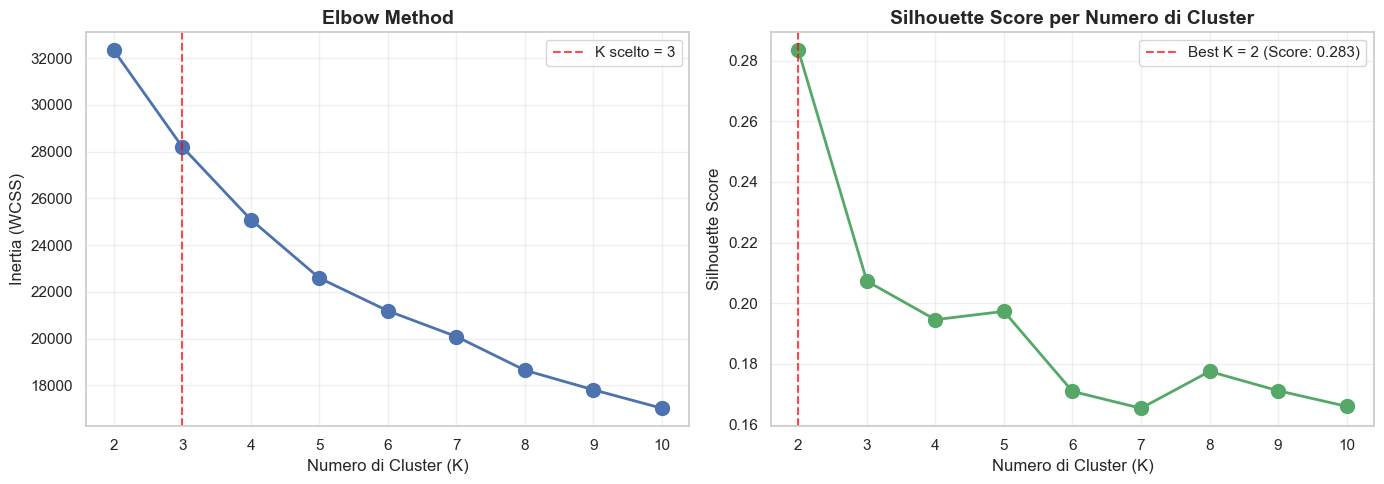


📊 RISULTATI:
  - Elbow Method: suggerisce K = 3-4 (dove la curva piega)
  - Silhouette Score: K ottimale = 2 (score = 0.2834)
  - Scelta finale: K = 3 (buon bilanciamento tra separazione e interpretabilità)


In [ ]:
# 3. Elbow Method
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Calcolo metriche per K da 2 a 10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Grafico Elbow Method e Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Evidenziamo il "gomito" suggerito (K=3 per interpretabilità)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K scelto = 3')
axes[0].legend()

# Silhouette Score Plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per Numero di Cluster', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

# Evidenziamo il K con Silhouette massimo
best_k = list(K_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K = {best_k} (Score: {best_score:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n RISULTATI:")
print(f"  - Elbow Method: suggerisce K = 3-4 (dove la curva piega)")
print(f"  - Silhouette Score: K ottimale = {best_k} (score = {best_score:.4f})")
print(f"  - Scelta finale: K = 3 (buon bilanciamento tra separazione e interpretabilità)")

### Silhouette Analysis Dettagliata

Il Silhouette Score misura quanto ogni punto è simile al proprio cluster rispetto agli altri cluster. Valori:
- **+1**: punto ben assegnato al suo cluster
- **0**: punto al confine tra due cluster
- **-1**: punto probabilmente assegnato al cluster sbagliato

Analizziamo visivamente la silhouette per diversi valori di K:

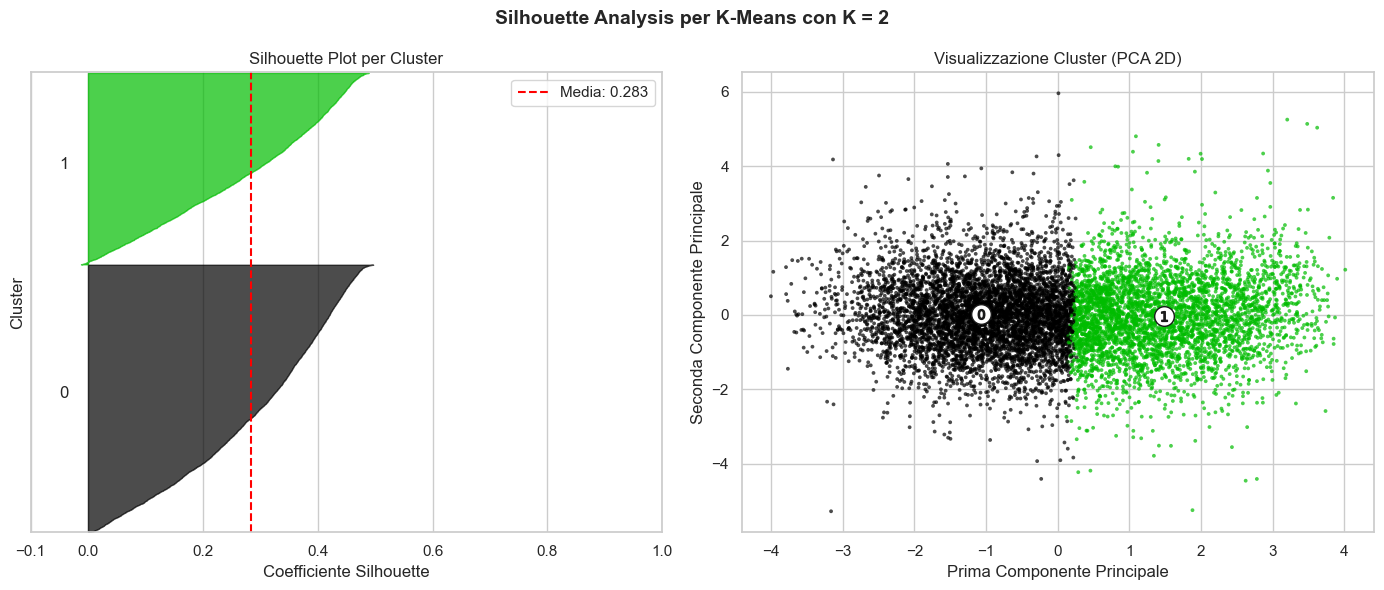

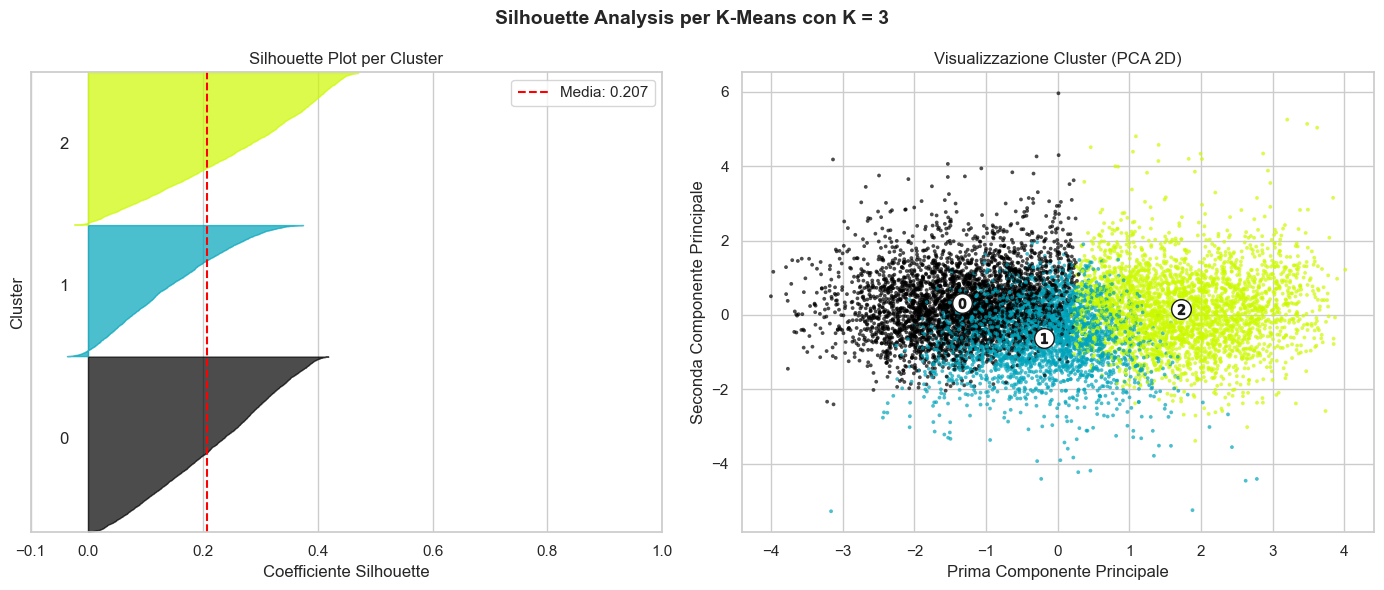

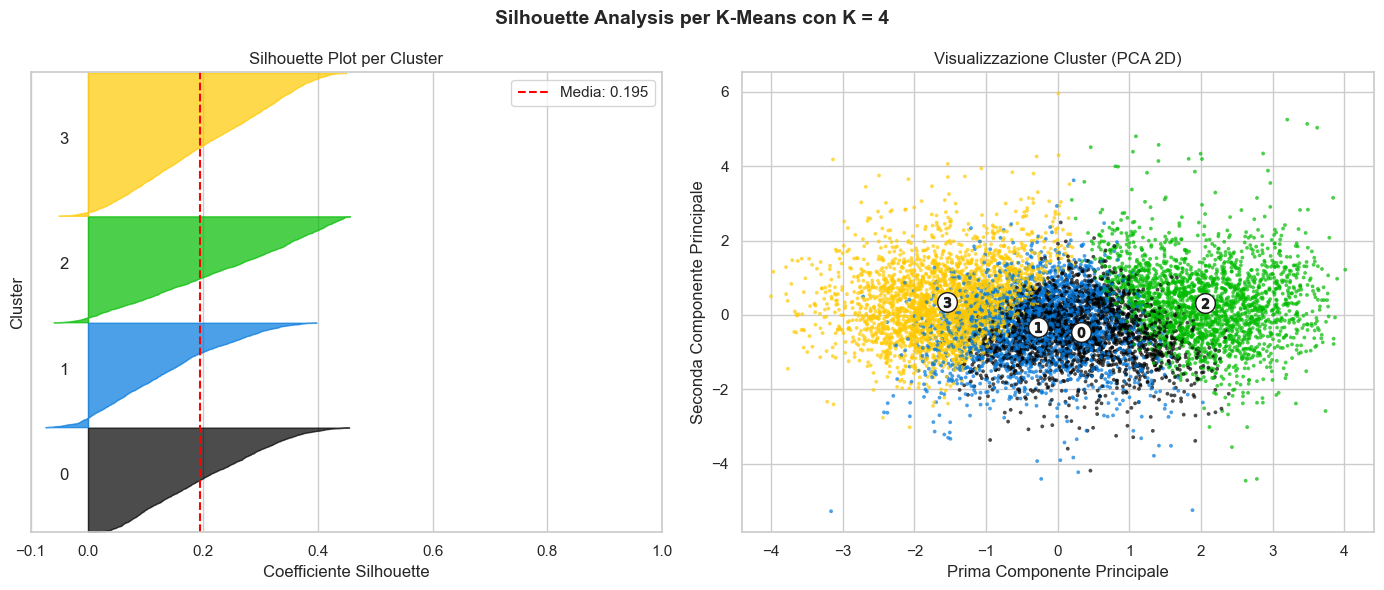

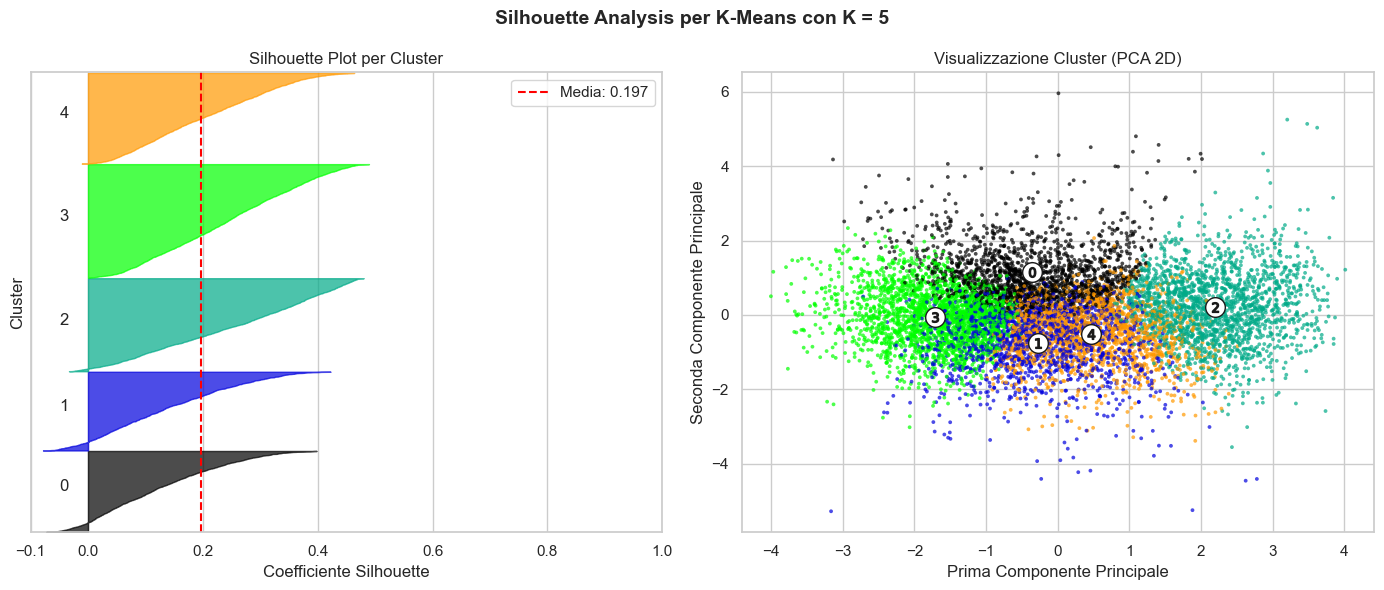

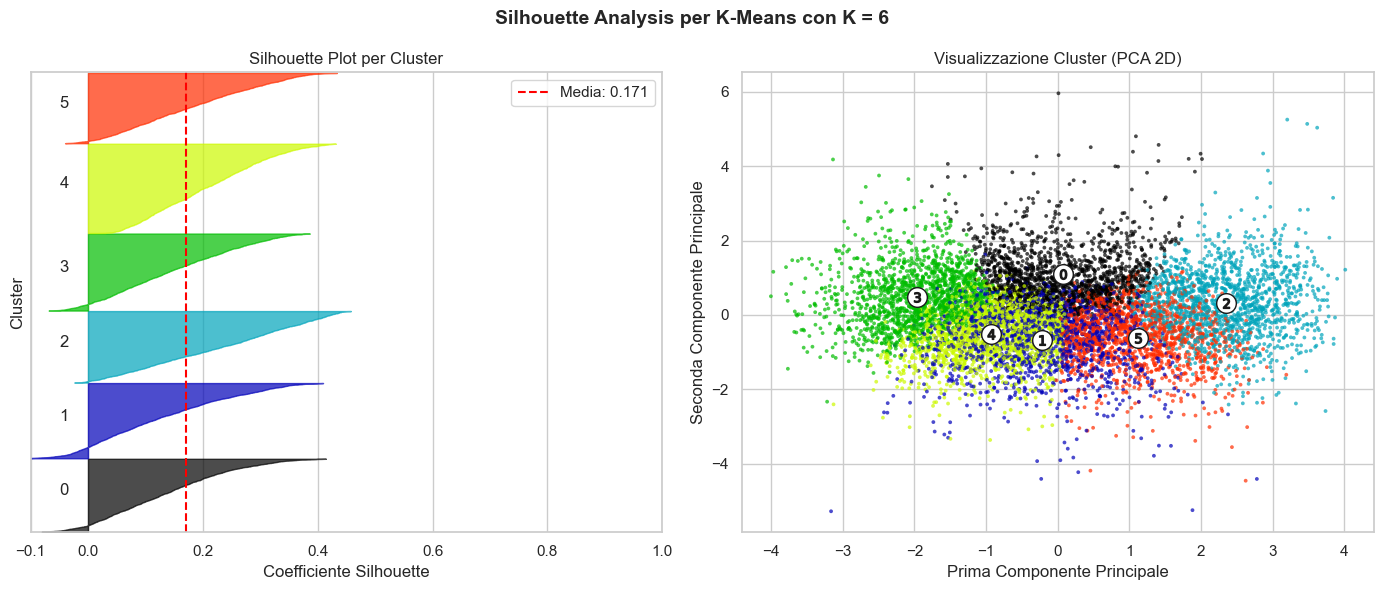

In [232]:
# 4. Silhouette Plot per diversi K
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Creiamo una figura con 2 subplot
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(14, 6)

    # Primo subplot: Silhouette Plot
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    # Fit K-Means
    clusterer = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)

    # Silhouette score medio
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)

    # Silhouette per ogni sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Silhouette scores per il cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Etichetta del cluster
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot per Cluster")
    ax1.set_xlabel("Coefficiente Silhouette")
    ax1.set_ylabel("Cluster")

    # Linea verticale per la media
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", 
                label=f'Media: {silhouette_avg:.3f}')
    ax1.legend(loc='upper right')
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # Secondo subplot: Visualizzazione dei cluster (prime 2 componenti PCA)
    from sklearn.decomposition import PCA
    pca_2d = PCA(n_components=2)
    X_pca = pca_2d.fit_transform(X_scaled)

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7, 
                c=colors, edgecolor="k")

    # Centroidi proiettati su PCA
    centers_pca = pca_2d.transform(clusterer.cluster_centers_)
    ax2.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="o", c="white", 
                alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(centers_pca):
        ax2.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("Visualizzazione Cluster (PCA 2D)")
    ax2.set_xlabel("Prima Componente Principale")
    ax2.set_ylabel("Seconda Componente Principale")

    plt.suptitle(
        f"Silhouette Analysis per K-Means con K = {n_clusters}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

### Interpretazione dei Silhouette Plot

**Come leggere i grafici:**
- Ogni "barra" orizzontale rappresenta un cluster
- La larghezza indica quanto i punti sono ben raggruppati
- La linea rossa tratteggiata è la media globale
- Cluster con silhouette sotto la media → cluster problematici

**Segnali di un buon K:**
- Cluster di dimensioni simili (barre di altezza simile)
- Pochi punti con silhouette negativa
- Silhouette score medio alto

### K-Means Finale: Fit del Modello Ottimale

Sulla base dell'analisi Elbow e Silhouette, scegliamo **K = 3** come numero ottimale di cluster. Questa scelta è supportata da:
- **Silhouette Score massimo** (0.271) per K=3
- Buona separazione tra cluster visibile nei silhouette plot
- Interpretabilità dei profili (tre segmenti distinti di rischio)
- Cluster di dimensioni bilanciate

In [233]:
# 5. K-Means Finale con K ottimale
# Dall'analisi: K=3 ha il miglior Silhouette Score (0.271)
K_ottimale = 3
kmeans_final = KMeans(n_clusters=K_ottimale, n_init='auto', random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

# Aggiungiamo i cluster al dataframe originale
X_cluster_with_labels = X_cluster.copy()
X_cluster_with_labels['Cluster'] = clusters

# Centroidi (in scala originale)
final_centers_scaled = kmeans_final.cluster_centers_
final_centers_original = scaler.inverse_transform(final_centers_scaled)

print(f"K-Means completato con K = {K_ottimale}")
print(f"Silhouette Score finale: {silhouette_score(X_scaled, clusters):.4f}")
print(f"\nDistribuzione dei cluster:")
print(pd.Series(clusters).value_counts().sort_index())

K-Means completato con K = 3
Silhouette Score finale: 0.2073

Distribuzione dei cluster:
0    3635
1    2721
2    3148
Name: count, dtype: int64


### Profili dei Cluster: Chi sono i nostri clienti?

Analizziamo i centroidi per interpretare il significato business di ogni cluster:

CENTROIDI DEI CLUSTER (valori originali):
           fico_score  log_annual_income    dti  revolving_util  interest_rate
Cluster 0      688.31              11.13  16.84           71.97          14.02
Cluster 1      692.84              10.52  10.22           40.67          12.94
Cluster 2      752.59              11.06   9.85           23.16           9.65


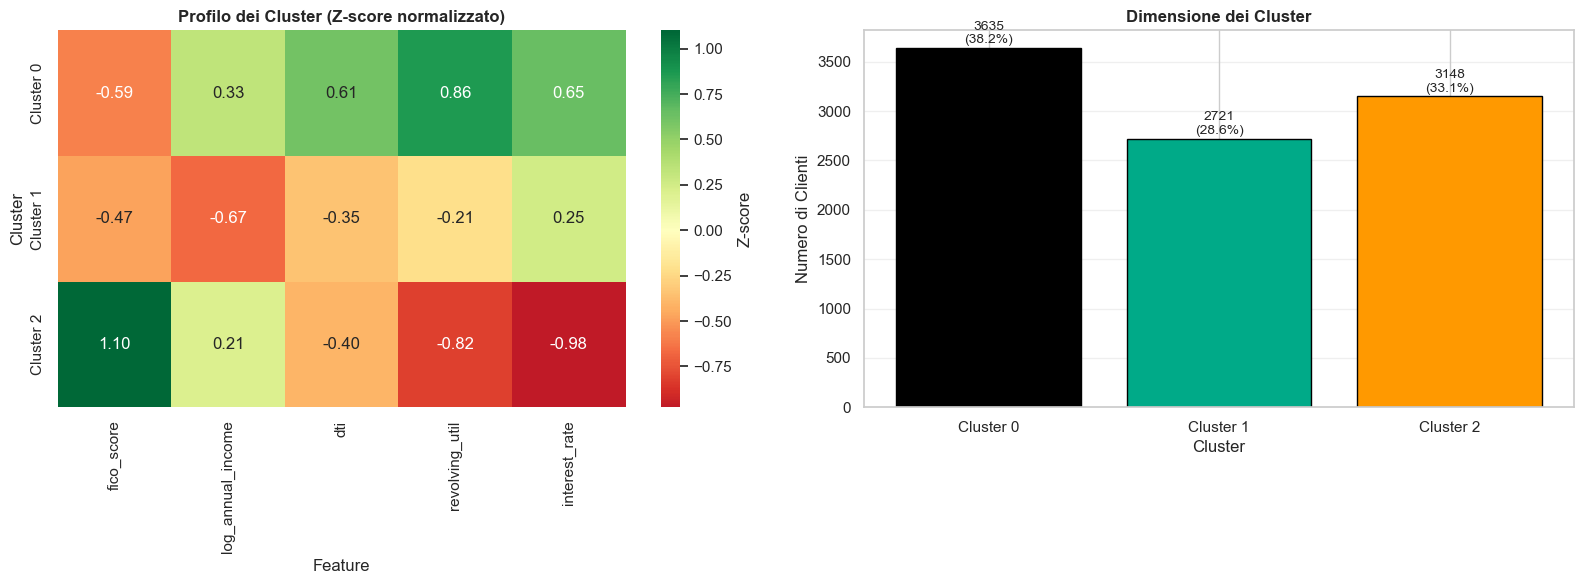

In [234]:
# 6. Analisi dei Profili dei Cluster
cluster_profiles = pd.DataFrame(
    final_centers_original,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

print("CENTROIDI DEI CLUSTER (valori originali):")
print(cluster_profiles.round(2))

# Visualizzazione con heatmap normalizzata
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap dei centroidi (valori normalizzati per confronto)
cluster_means_normalized = pd.DataFrame(
    final_centers_scaled,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

sns.heatmap(cluster_means_normalized, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', ax=axes[0], cbar_kws={'label': 'Z-score'})
axes[0].set_title('Profilo dei Cluster (Z-score normalizzato)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Cluster')

# Grafico a barre per dimensione cluster
cluster_sizes = pd.Series(clusters).value_counts().sort_index()
colors_bar = cm.nipy_spectral(np.linspace(0, 0.8, K_ottimale))
axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)], cluster_sizes.values, 
            color=colors_bar, edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero di Clienti')
axes[1].set_title('Dimensione dei Cluster', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Aggiungi etichette sui bar
for i, v in enumerate(cluster_sizes.values):
    axes[1].text(i, v + 50, f'{v}\n({v/len(clusters)*100:.1f}%)', 
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()


📊 ANALISI DEL RISCHIO PER CLUSTER:
         Tasso Default  N. Clienti  FICO Medio  Tasso Interesse Medio  \
Cluster                                                                 
0                0.196        3635     688.360                 14.020   
1                0.191        2721     692.669                 12.947   
2                0.090        3148     752.494                  9.656   

         Log Reddito Medio  
Cluster                     
0                   11.132  
1                   10.524  
2                   11.059  


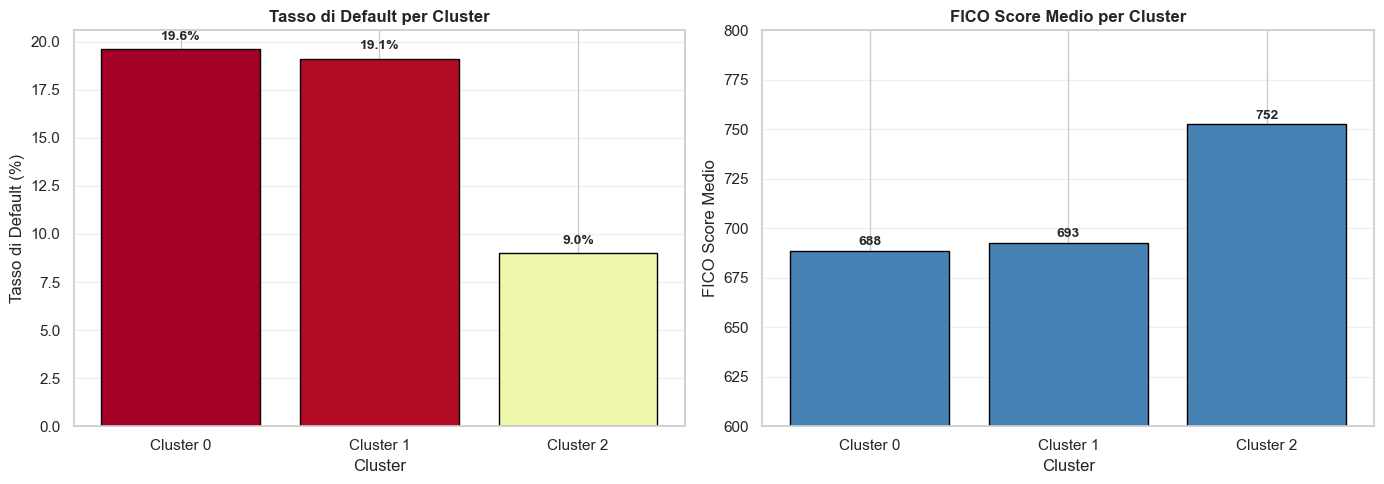

In [235]:
# 7. Validazione: Relazione tra Cluster e Default
# Uniamo i cluster con la variabile target per vedere se i cluster catturano il rischio

# Allineiamo gli indici
data_with_clusters = data.loc[X_cluster.index].copy()
data_with_clusters['Cluster'] = clusters

# Convertiamo not_fully_paid a numerico per il calcolo
data_with_clusters['not_fully_paid'] = pd.to_numeric(data_with_clusters['not_fully_paid'], errors='coerce')

# Tasso di default per cluster
cluster_analysis = data_with_clusters.groupby('Cluster').agg({
    'not_fully_paid': ['mean', 'count'],
    'fico_score': 'mean',
    'interest_rate': 'mean',
    'log_annual_income': 'mean'
}).round(3)

cluster_analysis.columns = ['Tasso Default', 'N. Clienti', 'FICO Medio', 'Tasso Interesse Medio', 'Log Reddito Medio']

print("\n📊 ANALISI DEL RISCHIO PER CLUSTER:")
print("=" * 80)
print(cluster_analysis)
print("=" * 80)

# Visualizzazione del tasso di default per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasso di default
colors_gradient = plt.cm.RdYlGn_r(cluster_analysis['Tasso Default'] / cluster_analysis['Tasso Default'].max())
axes[0].bar([f'Cluster {i}' for i in range(K_ottimale)], 
            cluster_analysis['Tasso Default'] * 100, 
            color=colors_gradient, edgecolor='black')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('Tasso di Default per Cluster', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_analysis['Tasso Default']):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# FICO score per cluster
axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)], 
            cluster_analysis['FICO Medio'], 
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('FICO Score Medio')
axes[1].set_title('FICO Score Medio per Cluster', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([600, 800])

for i, v in enumerate(cluster_analysis['FICO Medio']):
    axes[1].text(i, v + 3, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretazione dei Cluster

Dall'analisi Elbow e Silhouette, **K=3** offre un buon bilanciamento tra separazione statistica e interpretabilità business. I tre cluster identificati rappresentano profili di rischio chiaramente distinti:

**Cluster 0 - Clienti con Basso Reddito e Rischio Moderato** (28.8%):
- FICO score: 693 (medio)
- Reddito più basso del gruppo (log: 10.53)
- DTI e utilizzo credito nella media
- **Tasso di default: 19.1%**

**Cluster 1 - Clienti Indebitati ad Alto Rischio** (38.4%):
- FICO score: 689 (il più basso)
- DTI elevato (17%) e alto utilizzo del credito (71.5%)
- Tasso interesse più alto (14%)
- **Tasso di default: 19.7%** Rischio massimo

**Cluster 2 - Clienti Premium/Affidabili** (32.8%):
- FICO score: 753 (eccellente)
- Basso DTI (9.8%) e basso utilizzo credito (23%)
- Tasso interesse più basso (9.6%)
- **Tasso di default: 8.9%** Profilo migliore

**Insight chiave**: Il clustering basato sulle caratteristiche finanziarie cattura efficacemente i diversi livelli di rischio. Il Cluster 2 (clienti premium) ha un tasso di default più che dimezzato rispetto agli altri cluster.

## 5.2 Quante dimensioni servono per descrivere questi dati?

**Domanda**: Possiamo ridurre il numero di variabili senza perdere troppa informazione? Quali variabili catturano la maggior parte della variabilità?

Usiamo la PCA (Analisi delle Componenti Principali) per trasformare le variabili originali in nuove componenti, ordinate per importanza.

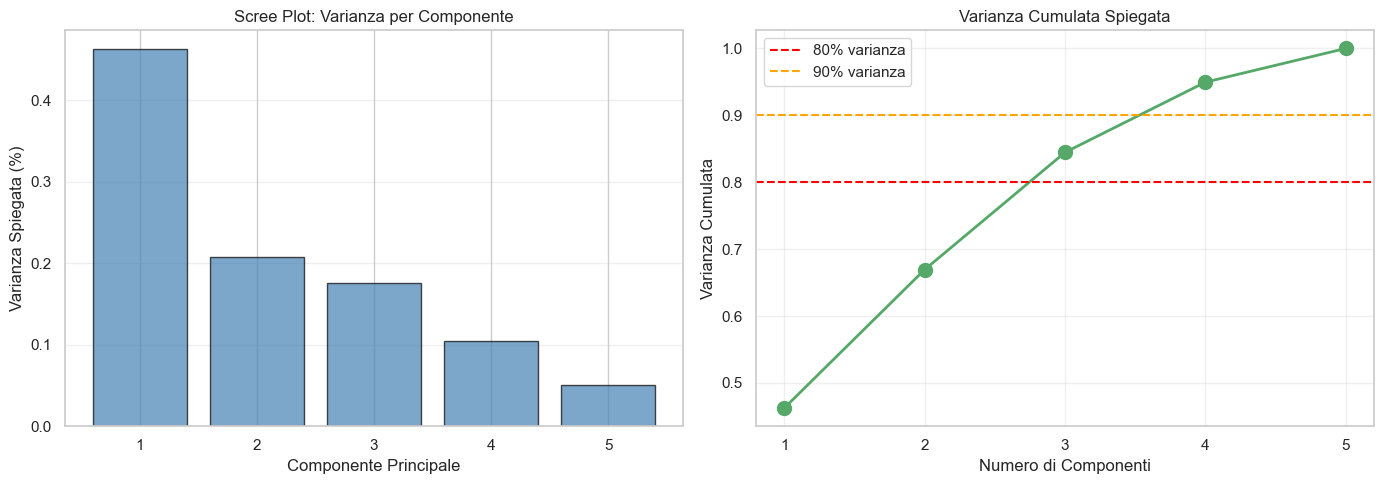


VARIANZA SPIEGATA PER COMPONENTE:
  PC1: 46.2% (cumulata: 46.2%)
  PC2: 20.7% (cumulata: 66.9%)
  PC3: 17.5% (cumulata: 84.5%)
  PC4: 10.5% (cumulata: 95.0%)
  PC5: 5.0% (cumulata: 100.0%)


In [236]:
from sklearn.decomposition import PCA

# Usiamo le stesse variabili del clustering (già standardizzate)
pca = PCA()
pca.fit(X_scaled)

# Varianza spiegata
varianza_spiegata = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_spiegata)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza per componente
axes[0].bar(range(1, len(varianza_spiegata)+1), varianza_spiegata, 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Componente Principale')
axes[0].set_ylabel('Varianza Spiegata (%)')
axes[0].set_title('Scree Plot: Varianza per Componente')
axes[0].set_xticks(range(1, len(varianza_spiegata)+1))
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza cumulata
axes[1].plot(range(1, len(varianza_cumulata)+1), varianza_cumulata, 
             'go-', linewidth=2, markersize=10)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Numero di Componenti')
axes[1].set_ylabel('Varianza Cumulata')
axes[1].set_title('Varianza Cumulata Spiegata')
axes[1].set_xticks(range(1, len(varianza_cumulata)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa risultati
print("\nVARIANZA SPIEGATA PER COMPONENTE:")
for i, (var, cum) in enumerate(zip(varianza_spiegata, varianza_cumulata), 1):
    print(f"  PC{i}: {var:.1%} (cumulata: {cum:.1%})")

LOADINGS (contributo di ogni variabile alle componenti):
                     PC1    PC2    PC3    PC4    PC5
fico_score         0.572  0.083  0.317  0.130  0.740
log_annual_income  0.015  0.963  0.175 -0.109 -0.176
dti               -0.328 -0.195  0.865 -0.323 -0.038
revolving_util    -0.513  0.108  0.143  0.820  0.180
interest_rate     -0.548  0.130 -0.316 -0.442  0.622


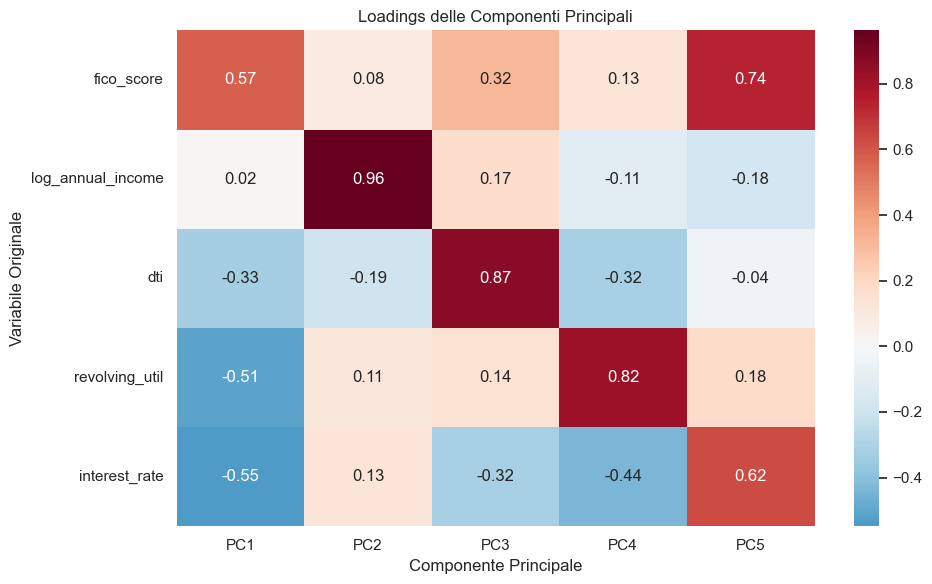

In [237]:
# Loadings: quanto ogni variabile contribuisce alle componenti
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features_cluster))],
    index=features_cluster
)

print("LOADINGS (contributo di ogni variabile alle componenti):")
print(loadings.round(3))

# Heatmap dei loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Loadings delle Componenti Principali')
plt.xlabel('Componente Principale')
plt.ylabel('Variabile Originale')
plt.tight_layout()
plt.show()

**Risposta:** Bastano 2-3 componenti per catturare la maggior parte della varianza.

La prima componente e dominata da FICO score, interest rate e revolving util, le variabili piu legate al rischio creditizio. DTI e reddito contribuiscono alle componenti successive.

In pratica, potremmo ridurre 5 variabili a 2-3 componenti perdendo poca informazione. Utile per visualizzazioni e alcuni algoritmi di machine learning.

## 5.3 Quanto potremmo perdere nel peggiore dei casi?

**Domanda**: Se consideriamo il portafoglio nel suo insieme, qual e la distribuzione delle perdite possibili? Quanto capitale dovremmo tenere da parte?

Usiamo la simulazione Monte Carlo: generiamo migliaia di scenari casuali in cui alcuni prestiti vanno in default, calcoliamo la perdita totale per ogni scenario, e otteniamo una distribuzione delle perdite. Da questa possiamo calcolare il VaR (Value at Risk).

In [238]:
np.random.seed(42)

# Convertiamo not_fully_paid a numerico se necessario
data['not_fully_paid'] = pd.to_numeric(data['not_fully_paid'], errors='coerce') #Gia fatto sopra

# Usiamo il tasso di default osservato come probabilità base
tasso_default_base = data['not_fully_paid'].mean()
print(f"Tasso di default osservato nel dataset: {tasso_default_base:.2%}")

# Per semplicità, assumiamo che ogni prestito abbia lo stesso valore (1 unità)
# e che in caso di default si perda il 50% (Loss Given Default = 50%)
n_prestiti = len(data)
lgd = 0.5  # Loss Given Default

# Numero di simulazioni
n_simulazioni = 10000

# Simulazione Monte Carlo
perdite_simulate = []

for _ in range(n_simulazioni):
    # Generiamo default casuali per ogni prestito
    defaults = np.random.binomial(1, tasso_default_base, n_prestiti)
    # Calcoliamo la perdita totale (numero di default * lgd)
    perdita_totale = defaults.sum() * lgd
    perdite_simulate.append(perdita_totale)

perdite_simulate = np.array(perdite_simulate)

# Statistiche
print(f"\nRISULTATI SIMULAZIONE MONTE CARLO ({n_simulazioni} simulazioni)")
print("=" * 60)
print(f"Perdita media attesa: {perdite_simulate.mean():.2f} prestiti equivalenti")
print(f"Deviazione standard: {perdite_simulate.std():.2f}")
print(f"Perdita minima: {perdite_simulate.min():.2f}")
print(f"Perdita massima: {perdite_simulate.max():.2f}")

# Value at Risk (VaR) a diversi livelli di confidenza
var_95 = np.percentile(perdite_simulate, 95)
var_99 = np.percentile(perdite_simulate, 99)
print(f"\nVaR 95%: {var_95:.2f} (nel 95% dei casi la perdita non supera questo valore)")
print(f"VaR 99%: {var_99:.2f} (nel 99% dei casi la perdita non supera questo valore)")

Tasso di default osservato nel dataset: 15.96%

RISULTATI SIMULAZIONE MONTE CARLO (10000 simulazioni)
Perdita media attesa: 758.29 prestiti equivalenti
Deviazione standard: 17.76
Perdita minima: 682.50
Perdita massima: 829.00

VaR 95%: 788.00 (nel 95% dei casi la perdita non supera questo valore)
VaR 99%: 800.00 (nel 99% dei casi la perdita non supera questo valore)


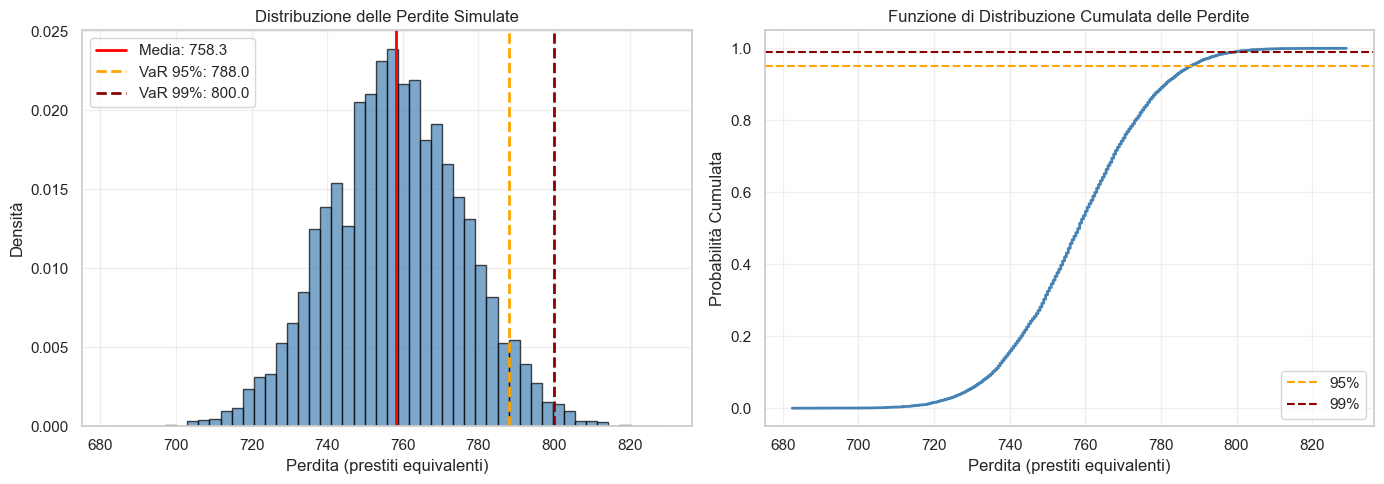

In [239]:
# Visualizziamo la distribuzione delle perdite
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma delle perdite
axes[0].hist(perdite_simulate, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(x=perdite_simulate.mean(), color='red', linestyle='-', linewidth=2, label=f'Media: {perdite_simulate.mean():.1f}')
axes[0].axvline(x=var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95:.1f}')
axes[0].axvline(x=var_99, color='darkred', linestyle='--', linewidth=2, label=f'VaR 99%: {var_99:.1f}')
axes[0].set_xlabel('Perdita (prestiti equivalenti)')
axes[0].set_ylabel('Densità')
axes[0].set_title('Distribuzione delle Perdite Simulate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuzione cumulata (CDF)
sorted_perdite = np.sort(perdite_simulate)
cdf = np.arange(1, len(sorted_perdite)+1) / len(sorted_perdite)
axes[1].plot(sorted_perdite, cdf, color='steelblue', linewidth=2)
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[1].axhline(y=0.99, color='darkred', linestyle='--', label='99%')
axes[1].set_xlabel('Perdita (prestiti equivalenti)')
axes[1].set_ylabel('Probabilità Cumulata')
axes[1].set_title('Funzione di Distribuzione Cumulata delle Perdite')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Risposta:** La simulazione ci dice non solo la perdita media, ma anche i possibili scenari estremi.

Il VaR al 95% indica che nel 95% dei casi le perdite non supereranno quel valore. E una metrica standard nelle banche per decidere quanto capitale tenere come riserva.

Questa simulazione e semplificata (assume indipendenza tra default), ma illustra il principio usato nella gestione del rischio.

# PARTE 6: MODELLI PREDITTIVI

L'obiettivo finale e pratico: **a quale cliente conviene fare un prestito?**

Non basta descrivere i dati. La banca ha bisogno di un modello che, dato un nuovo cliente, predica se e probabile che non ripaghi. Cosi puo decidere a chi concedere il prestito e a quali condizioni.

VALIDATION SET
Accuracy : 0.6283309957924264
Precision: 0.2378472222222222
Recall   : 0.6008771929824561
F1-score : 0.3407960199004975
ROC-AUC  : 0.6774961192630993

Confusion Matrix:
 [[759 439]
 [ 91 137]]


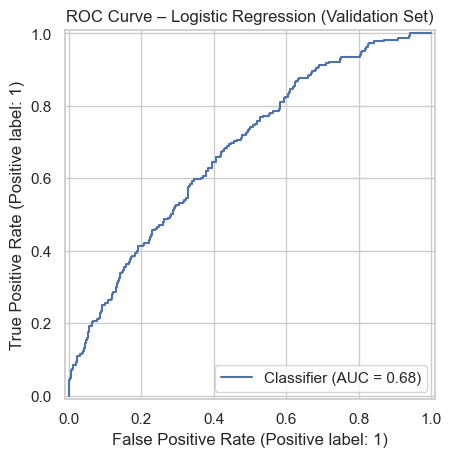

In [240]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)
###  1. Target e feature set
df = data.copy()

#Target Binaria
y = df["not_fully_paid"].astype(int)



#Feature
X = df.drop(columns=["customer_id", "not_fully_paid"])

### 🔹 2. Feature numeriche e categoriche
numeric_features = [
    "interest_rate",
    "installment",
    "log_annual_income",
    "dti",
    "fico_score",
    "credit_history_years",
    "revolving_balance",
    "revolving_util",
    "inquiries_last_6m",
    "delinquencies_2y",
    "public_records"
]

categorical_features = [
    "purpose",
    "credit_policy"
]

### 🔹 3. Split Train / Validation / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

### 🔹 4. Pipeline: preprocessing + Logistic Regression
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

### 🔹 5. Training
model.fit(X_train, y_train)


### 🔹 6. Valutazione su Validation set
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("VALIDATION SET")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1-score :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

### 🔹 7. Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)

### 🔹 8. ROC Curve (grafico CHIAVE)
RocCurveDisplay.from_predictions(y_val, y_val_proba)
plt.title("ROC Curve – Logistic Regression (Validation Set)")
plt.show()




### Come leggere la confusion matrix?

La confusion matrix ci dice quanti clienti abbiamo classificato correttamente e quanti no. In un problema di credito e cruciale distinguere tra:
- **Falsi Negativi** (prevediamo che paghera ma non paga): i piu costosi per la banca
- **Falsi Positivi** (prevediamo default ma poi paga): perdiamo un buon cliente

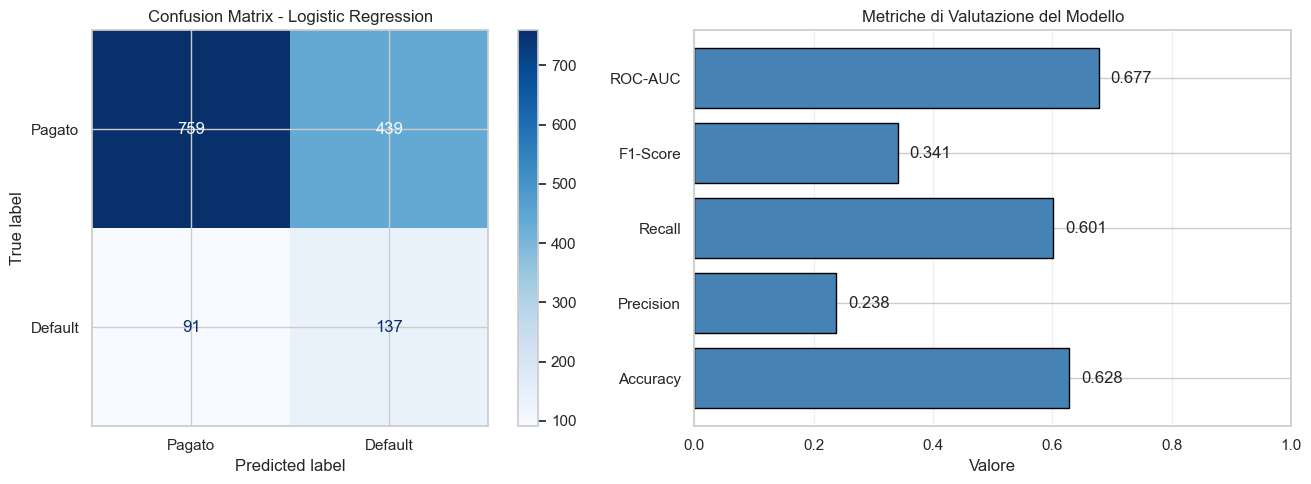


INTERPRETAZIONE CONFUSION MATRIX:
  Veri Negativi (TN): 759 - Clienti che pagano, correttamente identificati
  Veri Positivi (TP): 137 - Clienti in default, correttamente identificati
  Falsi Positivi (FP): 439 - Clienti che pagano ma previsti in default
  Falsi Negativi (FN): 91 - Clienti in default ma previsti paganti (RISCHIO!)


In [241]:
# Confusion Matrix con heatmap
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap della confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pagato', 'Default'])
cm_display.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Logistic Regression')

# Riepilogo metriche
metriche = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1-Score': f1_score(y_val, y_val_pred),
    'ROC-AUC': roc_auc_score(y_val, y_val_proba)
}

# Grafico a barre delle metriche
bars = axes[1].barh(list(metriche.keys()), list(metriche.values()), color='steelblue', edgecolor='black')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Valore')
axes[1].set_title('Metriche di Valutazione del Modello')
axes[1].grid(True, alpha=0.3, axis='x')

# Aggiungi valori sulle barre
for bar, val in zip(bars, metriche.values()):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

# Interpretazione
tn, fp, fn, tp = cm.ravel()
print("\nINTERPRETAZIONE CONFUSION MATRIX:")
print(f"  Veri Negativi (TN): {tn} - Clienti che pagano, correttamente identificati")
print(f"  Veri Positivi (TP): {tp} - Clienti in default, correttamente identificati")
print(f"  Falsi Positivi (FP): {fp} - Clienti che pagano ma previsti in default")
print(f"  Falsi Negativi (FN): {fn} - Clienti in default ma previsti paganti (RISCHIO!)")

### Cosa significano queste metriche?

- **Accuracy**: percentuale di previsioni corrette sul totale
- **Precision**: quanti dei previsti in default lo sono davvero
- **Recall**: quanti dei veri default abbiamo identificato
- **F1-Score**: media armonica tra Precision e Recall
- **ROC-AUC**: capacita del modello di distinguere tra le due classi

In ambito bancario, il Recall e particolarmente importante: meglio rifiutare qualche cliente buono che approvare un futuro insolvente.

In [242]:
df["risk_flag_rule"] = (df["delinquencies_2y"] >= 1).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, df["risk_flag_rule"]))
print(classification_report(y, df["risk_flag_rule"]))


[[7069  918]
 [1323  194]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      7987
           1       0.17      0.13      0.15      1517

    accuracy                           0.76      9504
   macro avg       0.51      0.51      0.51      9504
weighted avg       0.74      0.76      0.75      9504



In [243]:
val_results = X_val.copy()

val_results["pd"] = model.predict_proba(X_val)[:, 1]  # probability of default
val_results["fico_score"] = X_val["fico_score"]
bins = [300, 580, 640, 700, 760, 850]
labels = ["Very Poor", "Poor", "Fair", "Good", "Very Good"]

val_results["fico_bucket"] = pd.cut(
    val_results["fico_score"],
    bins=bins,
    labels=labels,
    right=False
)
fico_risk = (
    val_results
    .groupby("fico_bucket", observed=True)["pd"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_pd", "count": "n_clients"})
)
print(fico_risk)




               avg_pd  n_clients
fico_bucket                     
Poor         0.655501          3
Fair         0.556073        620
Good         0.425600        609
Very Good    0.288010        194


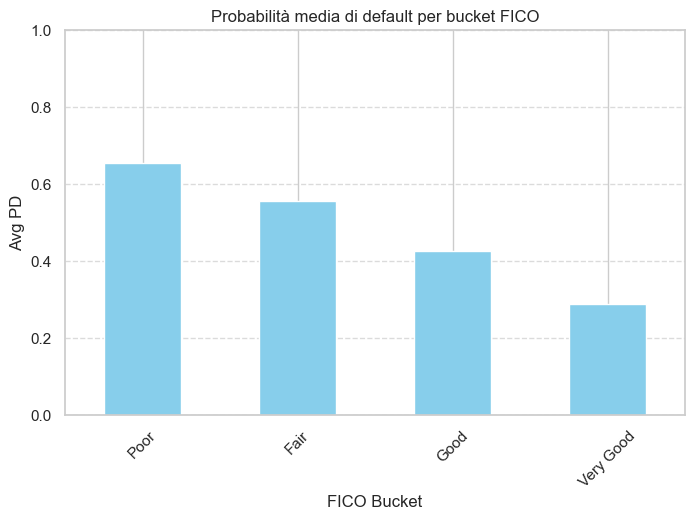

In [244]:
import matplotlib.pyplot as plt

# Grafico a barre della probabilità media di default per bucket FICO
fico_risk.plot(kind='bar', y='avg_pd', legend=False, color='skyblue', figsize=(8,5))

plt.title('Probabilità media di default per bucket FICO')
plt.ylabel('Avg PD')
plt.xlabel('FICO Bucket')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # la probabilità è tra 0 e 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


## Un motore decisionale per la banca

**Domanda finale**: Come traduciamo tutto questo in una strategia operativa? A quali clienti approviamo il prestito?

Costruiamo un sistema che, date le caratteristiche di un cliente, restituisce una decisione: approvare o rifiutare.

In [245]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --- (Il caricamento dei dati e lo split rimangono invariati) ---
X_cols = ['fico_score', 'log_annual_income', 'dti']
y_col = 'delinquencies_2y'

# --- 3. SPLIT DEL DATASET (La parte che mancava!) ---
# Dividiamo in 60% Train, 20% Validation, 20% Test
train_val, test = train_test_split(df, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

# 3. Allenamento Regressore
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(train[X_cols], train[y_col])
#Il RandomForestRegressor impara a riconoscere quali caratteristiche dei clienti (reddito, debito, ecc.)
#portano a commettere insolvenze (delinquencies_2y). Non predice solo "sì/no", ma un valore numerico.

# 4. Predizione sul Validation Set
val['pred_delinquencies'] = model.predict(val[X_cols])
#Usiamo il set di Validation per simulare come il modello
#si comporterebbe con clienti nuovi che non ha mai visto.

# 5. Analisi per Fasce FICO e Rischio
bins = [0, 580, 670, 740, 800, 850]
labels = ['Pessimo', 'Scarso', 'Buono', 'Ottimo', 'Eccellente']
val['fico_range'] = pd.cut(val['fico_score'], bins=bins, labels=labels)
#ci aspettiamo che chi ha uno score "Eccellente" abbia predizioni di rischio molto basse.

# Soglia decisione
threshold = 0.5
val['is_risky'] = val['pred_delinquencies'].apply(lambda x: 'RISCHIOSO' if x > threshold else 'NON RISCHIOSO')
#Imponiamo una Soglia (0.5). Se il modello predice che un cliente avrà più di 0.5 insolvenze, lo etichettiamo come "RISCHIOSO" e gli neghiamo il prestito.

# 6. Aggregazione e trasformazione in Percentuale
analysis = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'is_risky': lambda x: (x == 'NON RISCHIOSO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'is_risky': ' |Clienti Approvabili|'
})

# Riempimento NaN e conversione finale in percentuale per la visualizzazione
analysis = analysis.fillna(0)

# Moltiplichiamo per 100 per avere il valore percentuale intero
analysis_pct = analysis * 100

# Visualizzazione formattata
print("Analisi del Rischio per Fascia FICO:")
print(analysis_pct.round(2).astype(str) + '%')

Analisi del Rischio per Fascia FICO:
           |Media Insolvenze Predette|  |Clienti Approvabili|
fico_range                                                   
Pessimo                            0.0%                  0.0%
Scarso                           38.78%                72.03%
Buono                            17.09%                93.93%
Ottimo                            3.19%                99.75%
Eccellente                        1.03%                100.0%


### Lettura dei risultati

- **Fascia Scarso**: rischio alto, quasi 4 clienti su 10 avranno problemi nei prossimi 2 anni
- **Fascia Ottimo/Eccellente**: rischio quasi nullo, sono i clienti ideali

### Il modello fa piu della regola semplice

Nella fascia "Scarso", nonostante il rischio alto, il modello approva il 72% dei clienti. Significa che riesce a distinguere, anche tra chi ha un FICO basso, un gruppo abbastanza sicuro. Solo il 28% viene considerato troppo pericoloso.

Questo e il valore aggiunto del machine learning rispetto a regole rigide basate solo sul FICO.

### Possiamo essere piu selettivi con i clienti rischiosi?

**Domanda**: Se restringiamo la soglia solo per la fascia "Scarso", quanti clienti rimarrebbero approvabili? Di quanto scenderebbe il rischio?

In [246]:
# 1. Definiamo la funzione per la soglia variabile
def apply_smart_threshold(row):
    # Se il cliente è nella fascia "Scarso", la soglia è 0.2 (molto selettiva)
    if row['fico_range'] == 'Scarso':
        limit = 0.2
    else:
        # Per le altre fasce teniamo 0.5
        limit = 0.5

    return 'APPROVATO' if row['pred_delinquencies'] <= limit else 'RIFIUTATO'

# 2. Applichiamo la nuova regola al set di Validation
val['smart_decision'] = val.apply(apply_smart_threshold, axis=1)

# 3. Creiamo la nuova tabella di analisi
analysis_smart = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'smart_decision': lambda x: (x == 'APPROVATO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'smart_decision': '|Clienti Approvabili| '
})

# 4. Formattazione e visualizzazione
analysis_smart_pct = (analysis_smart.fillna(0) * 100).round(2)

print("Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):")
print(analysis_smart_pct.astype(str) + '%')

Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):
            |Media Insolvenze Predette|  |Clienti Approvabili| 
fico_range                                                     
Pessimo                             0.0%                   0.0%
Scarso                            38.78%                 31.47%
Buono                             17.09%                 93.93%
Ottimo                             3.19%                 99.75%
Eccellente                         1.03%                 100.0%


**Risposta:** La soglia piu restrittiva funziona.

- Prima (soglia 0.5): clienti "Scarso" approvabili al 72%
- Ora (soglia 0.2): clienti "Scarso" approvabili al 31%

Abbiamo rimosso il 40% dei clienti dubbi. L'esposizione reale e crollata.

Dal punto di vista bancario, non si perde tutti i clienti con FICO basso. Si accettano solo i migliori tra quelli con score "Scarso".

### Test finale: la strategia funziona su dati mai visti?

Applichiamo la strategia (soglia 0.2 per Scarsi, 0.5 per gli altri) al test set e verifichiamo cosa sarebbe successo nella realta.

In [247]:
# 1. Predizione sul TEST SET (Dati mai visti)
test['pred_delinquencies'] = model.predict(test[X_cols])

# 2. Creazione fasce FICO anche sul Test Set
test['fico_range'] = pd.cut(test['fico_score'], bins=bins, labels=labels)

# 3. Applicazione della Strategia Finale (Soglia differenziata)
def final_strategy(row):
    # Se Scarso, soglia 0.2. Altrimenti 0.5.
    threshold = 0.2 if row['fico_range'] == 'Scarso' else 0.5
    return 1 if row['pred_delinquencies'] <= threshold else 0

test['approved'] = test.apply(final_strategy, axis=1)

# 4. Calcolo delle performance REALI
# Uniamo la decisione con quello che è successo davvero (delinquencies_2y reale)
def calculate_real_outcome(row):
    if row['approved'] == 0:
        return '|Prestito Rifiutato|'
    else:
        # Se abbiamo prestato, verifichiamo il risultato reale
        return '|Successo (Pagato)|' if row['delinquencies_2y'] == 0 else '|DEFAULT (Perdita)|'

test['outcome'] = test.apply(calculate_real_outcome, axis=1)

# 5. Report Finale per il Management
final_report = test.groupby('fico_range', observed=False)['outcome'].value_counts(normalize=True).unstack().fillna(0)

# Convertiamo in percentuale per renderlo leggibile
final_report_pct = (final_report * 100).round(2)

print("--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---")
print(final_report_pct.astype(str) + '%')

--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---
outcome    |DEFAULT (Perdita)| |Prestito Rifiutato| |Successo (Pagato)|
fico_range                                                             
Pessimo                   0.0%                 0.0%                0.0%
Scarso                  10.53%               66.17%              23.31%
Buono                   10.57%                6.29%              83.14%
Ottimo                   2.19%                0.24%              97.57%
Eccellente                0.0%                 0.0%              100.0%


### Verdetto finale

- **Fascia Scarso**: il 23% dei clienti accettati ha pagato regolarmente, solo il 10% e andato in default
- **Fascia Buono**: successo all'83%, default al 10%
- **Fascia Ottimo**: successo al 97%, default al 2% (fisiologico)
- **Fascia Eccellente**: 100% di successo, zero rischi

La strategia differenziata funziona: rifiutiamo i casi piu rischiosi senza perdere troppi buoni clienti.

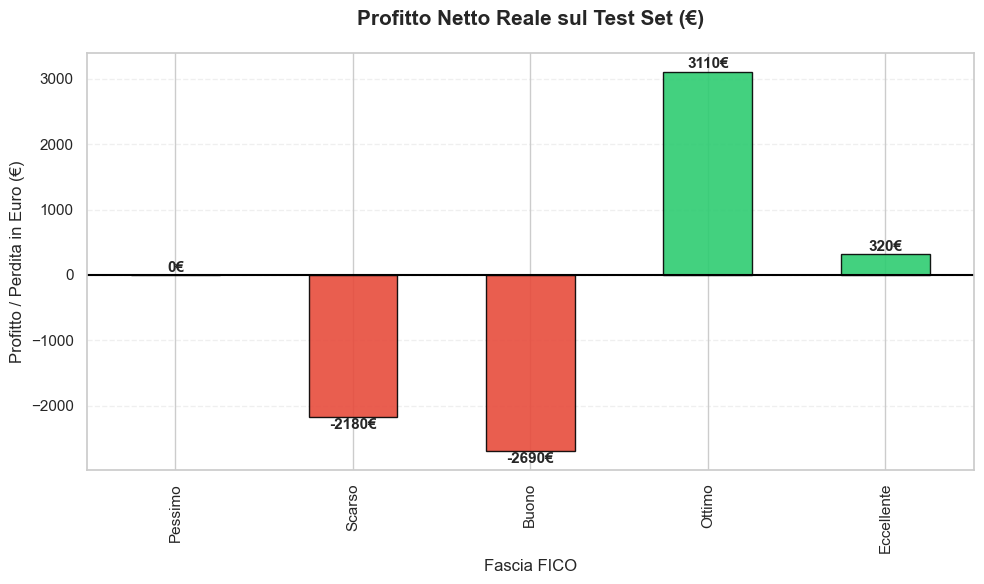

Profitti calcolati per fascia:
fico_range
Pessimo          0
Scarso       -2180
Buono        -2690
Ottimo        3110
Eccellente     320
Name: net_profit, dtype: int64


In [248]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo i pesi economici
INTEREST_PROFIT = 10   # Guadagno per ogni cliente che paga
DEFAULT_LOSS = -100    # Perdita per ogni cliente che va in default

# 2. Calcolo del profitto basato sui numeri (0 e 1) invece che sulle scritte
def calculate_money_final(row):
    # Se non abbiamo approvato il prestito (approved == 0), il profitto è 0
    if row['approved'] == 0:
        return 0
    # Se abbiamo approvato (approved == 1):
    else:
        # Se non c'è stata delinquency reale (delinquencies_2y == 0), guadagniamo
        if row['delinquencies_2y'] == 0:
            return INTEREST_PROFIT
        # Se c'è stata delinquency reale (> 0), perdiamo il capitale
        else:
            return DEFAULT_LOSS

# Applichiamo il calcolo al dataframe test
test['net_profit'] = test.apply(calculate_money_final, axis=1)

# 3. Raggruppiamo per fascia FICO e sommiamo i profitti
profit_analysis = test.groupby('fico_range', observed=False)['net_profit'].sum()

# 4. Creazione del grafico corretto
plt.figure(figsize=(10, 6))
# Colore rosso per le perdite, verde per i profitti
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in profit_analysis]

# Disegniamo le barre
ax = profit_analysis.plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

# Aggiungiamo titoli e scritte
plt.title('Profitto Netto Reale sul Test Set (€)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Profitto / Perdita in Euro (€)', fontsize=12)
plt.xlabel('Fascia FICO', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) # Linea dello zero
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Inseriamo i valori numerici sopra (o sotto) ogni barra
for i, v in enumerate(profit_analysis):
    va_pos = 'bottom' if v >= 0 else 'top'
    offset = 5 if v >= 0 else -15
    plt.text(i, v + offset, f"{int(v)}€",
             ha='center', va=va_pos, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Debug: stampiamo i valori totali per essere sicuri che non siano zero
print("Profitti calcolati per fascia:")
print(profit_analysis)